In [1]:
import numpy as np
import math
from scipy.integrate import quad
from scipy.linalg import eigvalsh
from scipy.optimize import minimize_scalar
from scipy.stats import linregress
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import os

# Basic Functions

In [2]:
#kronecker product code for more than 2 inputs
def kron(*matrices):
    result = np.array([[1]])
    for matrix in matrices:
        result = np.kron(result, matrix)
    return result

#Partial Trace Code
def IntegerDigits(n, b, l):
    digits = [0] * l
    pos = l - 1
    while pos != -1:
        digits[pos] = int(n % b)
        n //= b
        pos -= 1
    return digits

def FromDigits(digits, base):
    digits = digits[::-1]
    n = 0
    for i, d in enumerate(digits):
        n += d * base**i
        
    return n

def SwapParts(digits, p1, p2):
    new = np.copy(digits)
    new[p1] = digits[p2]
    new[p2] = digits[p1]
    return new

def dTraceSystem(D,s,dimen):
    Qudits=sorted(s)
    Qudits.reverse()
    TrkM = D
    z=len(Qudits)
    
    for q in range(z):
        n=math.log(TrkM.shape[0],dimen)
        assert n % 1 == 0
        n = int(n)
        
        M=TrkM
        M = np.array(M , dtype = complex)
        k=Qudits[q]
        temp = np.zeros(M.shape[0], dtype=complex)
        if k!=n:
            for j in range(n-k):
                b={0}
                for i in range(dimen**n):
                    digits=IntegerDigits(i,dimen,n)
                    if digits[n-1] != digits[n-j-2] and i not in  b:
                        number=FromDigits(
                            SwapParts(digits, n-1, n-j-2),
                            dimen
                        )
                        b.add(number)

                        temp[:] = M[i, :]
                        M[i, :] = M[number, :]
                        M[number, :] = temp

                        temp[:] = M[:, i]
                        M[:, i] = M[:, number]
                        M[:, number] = temp
        
        TrkM=[]
        for p in range(0,dimen**n,dimen):
            TrkM.append(
                sum(
                    M[p+h, h:dimen**n:dimen]
                    for h in range(dimen)
                )
            )
        TrkM = np.array(TrkM)
    
    return TrkM
#Recall matrix as dTraceSystem(matrix,[systems I want to trace out],dimension of system)

#defining basis vectors

#zero vector and its conjugate transpose                                         
zero= np.array([[1],[0]])
zeroCT=np.conjugate(zero.T)
#one vector and its conjugate transpose
one=np.array([[0],[1]])
oneCT=np.conjugate(one.T)
#plus vector and its conjugate transpose
plus=np.array([[1],[1]])*1/math.sqrt(2)
plusCT=np.conjugate(plus.T)
#minus vector and its conjugate transpose
minus=np.array([[1],[-1]])*1/math.sqrt(2)
minusCT=np.conjugate(minus.T)
#plusy and its conjugate transpose
plusy=np.array([[1],[complex(0.0, 1)]])*1/math.sqrt(2)
plusyCT=np.conjugate(plusy.T)
#minusy and its conjugate transpose
minusy=np.array([[1],[complex(0.0, -1)]])*1/math.sqrt(2)
minusyCT=np.conjugate(minusy.T)
#defining the Bell states
phiplus=(np.kron(zero, zero)+np.kron(one, one))*1/math.sqrt(2)
phiminus=(np.kron(zero, zero)-np.kron(one, one))*1/math.sqrt(2)
psiplus=(np.kron(zero, one)+np.kron(one, zero))*1/math.sqrt(2)
psiminus=(np.kron(zero, one)-np.kron(one, zero))*1/math.sqrt(2)
#defining the outer product of the Bell states
Phiplus=phiplus@np.conjugate(phiplus.T)
Phiminus=phiminus@np.conjugate(phiminus.T)
Psiplus=psiplus@np.conjugate(psiplus.T)
Psiminus=psiminus@np.conjugate(psiminus.T)
#defining Pauli matrices
pauliX=np.array([[0,1],[1,0]])
pauliY=np.array([[0,complex(0,-1)],[complex(0,1),0]])
pauliZ=np.array([[1,0],[0,-1]])

# GKP Qudit Code

In [3]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import minimize_scalar
from scipy.linalg import eigvalsh
from scipy.stats import linregress
import matplotlib.pyplot as plt

# -------------------------------------------------
# Helpers: loss + squeezing
# -------------------------------------------------

def sigma_squared_from_squeezing_db(squeezing_db):
    if np.isinf(squeezing_db):
        return 0.0
    return 10 ** (-squeezing_db / 10)

def half_channel_transmissivity(loss_db):
    # loss_db is the half-channel loss in dB
    return 10 ** (-loss_db / 10)

def effective_sigma(loss_db, squeezing_db, loss_model="preamplified"):
    eta = half_channel_transmissivity(loss_db)
    sigma2 = sigma_squared_from_squeezing_db(squeezing_db)

    if loss_model == "preamplified":
        sigma2_eff = sigma2 * eta + (1 - eta)
    elif loss_model in {"cc", "cc-amplification"}:
        sigma2_eff = sigma2 + (1 - eta) / (2 * eta)
    else:
        raise ValueError("loss_model must be 'preamplified' or 'cc'")

    return np.sqrt(sigma2_eff)

# -------------------------------------------------
# Qudit Bell-diagonal model
# -------------------------------------------------

def qudit_basis(d, k):
    vec = np.zeros((d, 1), dtype=complex)
    vec[k, 0] = 1.0
    return vec

def qudit_Bell_state(d, k, l):
    psi = np.zeros((d * d, 1), dtype=complex)
    for r_ in range(d):
        phase = np.exp(2j * np.pi * r_ * l / d)
        ket1 = qudit_basis(d, r_)
        ket2 = qudit_basis(d, (r_ - k) % d)
        psi += phase * kron(ket1, ket2)
    return psi / np.sqrt(d)

def qudit_Bell_state_projector(d, k, l):
    psi = qudit_Bell_state(d, k, l)
    return psi @ psi.conj().T

# -------------------------------------------------
# Non-deterministic Homodyne detection model
# -------------------------------------------------

def homodyne_distribution(x, mu, sigma):
    return np.exp(-(x - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))

def Pc_qudit(d, sigma, nu, j_cutoff=30):
    a = np.sqrt(2 * np.pi / d)
    total = 0.0
    for j in range(-j_cutoff, j_cutoff + 1):
        lower = a * (j * d - 0.5) + nu
        upper = a * (j * d + 0.5) - nu
        total += quad(lambda x: homodyne_distribution(x, 0, sigma), lower, upper)[0]
    return total

def Pf_qudit(d, sigma, nu, j_cutoff=30):
    a = np.sqrt(2 * np.pi / d)
    total = 0.0
    for k in range(1, d):
        for j in range(-j_cutoff, j_cutoff + 1):
            lower = a * (j * d + k - 0.5) + nu
            upper = a * (j * d + k + 0.5) - nu
            total += quad(lambda x: homodyne_distribution(x, 0, sigma), lower, upper)[0]
    return total

# -------------------------------------------------
# Shift probability - error model for Bell map
# -------------------------------------------------

def shift_probability(d, k, sigma, nu, j_cutoff=30):
    a = np.sqrt(2 * np.pi / d)
    total = 0.0
    for j in range(-j_cutoff, j_cutoff + 1):
        lower = a * (j * d + k - 0.5) + nu
        upper = a * (j * d + k + 0.5) - nu
        total += quad(lambda x: homodyne_distribution(x, 0, sigma), lower, upper)[0]
    return total

def shift_probability_vector(d, sigma, nu, j_cutoff=30):
    probs = np.array([shift_probability(d, k, sigma, nu, j_cutoff) for k in range(d)], dtype=float)
    total = np.sum(probs)
    if total <= 0 or not np.isfinite(total):
        raise ValueError("Shift probability normalisation failed")
    return probs / total

# -------------------------------------------------
# Constructing the memory-memory state
# -------------------------------------------------

def qudit_bell_diagonal_prob_table(d, sigma, nu, xL=0, yL=0, j_cutoff=30):
    ProbX = shift_probability_vector(d, sigma, nu, j_cutoff)
    ProbZ = shift_probability_vector(d, sigma, nu, j_cutoff)

    P_error = np.outer(ProbX, ProbZ)
    k0 = (d - xL) % d
    l0 = (d - yL) % d
    return np.roll(P_error, shift=(k0, l0), axis=(0, 1))

def qudit_hashing_bound(P_bell):
    d = P_bell.shape[0]
    P = P_bell[P_bell > 0]
    return max(0.0, np.log2(d) + np.sum(P * np.log2(P)))

def qudit_chain_distribution(P_succ, n):
    P_chain = np.fft.ifft2(np.fft.fft2(P_succ) ** (n + 1))
    P_chain = np.real_if_close(P_chain)
    P_chain = np.real(P_chain)
    P_chain = np.clip(P_chain, 0.0, None)
    P_chain = P_chain / np.sum(P_chain)
    return P_chain

# -------------------------------------------------
# GKP Qudit Hashing Rate
# -------------------------------------------------

def qudit_hashing_rate(Nreg, squeezing_db, nu, L, n, M, q, tau, m, j_cutoff=30, loss_model="preamplified"):
    d = 2 ** Nreg

    half_loss_db = 0.2 * L / (2 * (n + 1))
    sigma_eff = effective_sigma(half_loss_db, squeezing_db, loss_model=loss_model)

    Pc = Pc_qudit(d, sigma_eff, nu, j_cutoff=j_cutoff)
    Pf = Pf_qudit(d, sigma_eff, nu, j_cutoff=j_cutoff)

    pSWAP = (Pc + Pf) ** 2
    pELEM = 1 - (1 - pSWAP) ** (M * m)
    pNETWORK = (pELEM ** (n + 1)) * q**n
    rate = pNETWORK / (tau * m)

    P_elem = qudit_bell_diagonal_prob_table(d, sigma_eff, nu, j_cutoff=j_cutoff)
    P_chain = qudit_chain_distribution(P_elem, n)
    state_bound = qudit_hashing_bound(P_chain)

    return rate * state_bound

# -------------------------------------------------
# Optimised GKP Qudit Hashing Rate
# -------------------------------------------------

def optimal_qudit_hashing_rate(Nreg, squeezing_db, L, n, M, q, tau, m, j_cutoff=30, loss_model="preamplified", return_nu=False):
    d = 2 ** Nreg
    spacing = np.sqrt(2 * np.pi / d)

    def neg_rate(nu):
        try:
            value = qudit_hashing_rate(Nreg, squeezing_db, nu, L, n, M, q, tau, m, j_cutoff, loss_model)
            return -value if value > 0 else np.inf
        except Exception:
            return np.inf

    result = minimize_scalar(neg_rate, bounds=(0, spacing / 2), method="bounded")
    rate = -result.fun
    if not np.isfinite(rate) or rate <= 0:
        rate = 0.0

    if return_nu:
        return rate, result.x
    return rate

# Hashing Rate data generation

## Nreg = [1,2,3,4,5,6,7,8,9] , m = [1,2,...,20] , n = [1,2,4,8,16]

In [4]:
# ----------------------------
# Parameters
# ----------------------------
Ls = np.arange(0, 150, 1.0)
Nreg_values = [1, 2, 3, 4, 5, 6, 7, 8, 9]
m_values = np.arange(1, 21)
n_vals = [1, 2, 4, 8, 16]
n_scan_vals = np.arange(1, 17)

squeezing_dB = 5
M = 1
q = 0.7
tau = 1e-8

# output folder for plots
output_dir = "gkp_raw_rate_plots"
os.makedirs(output_dir, exist_ok=True)

In [5]:
# ----------------------------
# Compute all data
# ----------------------------
all_results = {}

for Nreg in Nreg_values:
    print(f"\nComputing all raw rate data for Nreg = {Nreg}")
    all_results[Nreg] = {}

    for m in m_values:
        print(f"  m = {m}")

        fixed_n_data = {n: {"rate": []} for n in n_vals}

        # compute raw fixed-n curves for this (Nreg, m)
        for L in Ls:
            for n in n_vals:
                rate = optimal_qudit_hashing_rate(
                    Nreg, squeezing_dB, L, n, M, q, tau, m,
                    return_nu=False
                )
                fixed_n_data[n]["rate"].append(rate)

        # convert lists to arrays
        for n in n_vals:
            fixed_n_data[n]["rate"] = np.array(fixed_n_data[n]["rate"], dtype=float)

        # store everything for this (Nreg, m)
        all_results[Nreg][m] = {
            "Ls": np.array(Ls),
            "Nreg": Nreg,
            "m": m,
            "fixed_n_data": fixed_n_data,
        }

# ----------------------------
# Save the raw data to disk
# ----------------------------
# If you want a single file:
np.save("gkp_raw_results.npy", all_results, allow_pickle=True)


Computing all raw rate data for Nreg = 1
  m = 1


/Users/conallcampbell/notebook_env/lib/python3.12/site-packages/scipy/optimize/_optimize.py:2358: RuntimeWarning: invalid value encountered in scalar subtract
  p = (xf - fulc) * q - (xf - nfc) * r
/Users/conallcampbell/notebook_env/lib/python3.12/site-packages/scipy/optimize/_optimize.py:2359: RuntimeWarning: invalid value encountered in scalar subtract
  q = 2.0 * (q - r)


  m = 2
  m = 3
  m = 4
  m = 5
  m = 6
  m = 7
  m = 8
  m = 9
  m = 10
  m = 11
  m = 12
  m = 13
  m = 14
  m = 15
  m = 16
  m = 17
  m = 18
  m = 19
  m = 20

Computing all raw rate data for Nreg = 2
  m = 1
  m = 2
  m = 3
  m = 4
  m = 5
  m = 6
  m = 7
  m = 8
  m = 9
  m = 10
  m = 11
  m = 12
  m = 13
  m = 14
  m = 15
  m = 16
  m = 17
  m = 18
  m = 19
  m = 20

Computing all raw rate data for Nreg = 3
  m = 1
  m = 2
  m = 3
  m = 4
  m = 5
  m = 6
  m = 7
  m = 8
  m = 9
  m = 10
  m = 11
  m = 12
  m = 13
  m = 14
  m = 15
  m = 16
  m = 17
  m = 18
  m = 19
  m = 20

Computing all raw rate data for Nreg = 4
  m = 1
  m = 2
  m = 3
  m = 4
  m = 5
  m = 6
  m = 7
  m = 8
  m = 9
  m = 10
  m = 11
  m = 12
  m = 13
  m = 14
  m = 15
  m = 16
  m = 17
  m = 18
  m = 19
  m = 20

Computing all raw rate data for Nreg = 5
  m = 1
  m = 2
  m = 3
  m = 4
  m = 5
  m = 6
  m = 7
  m = 8
  m = 9
  m = 10
  m = 11
  m = 12
  m = 13
  m = 14
  m = 15
  m = 16
  m = 17
  m = 18
  m

KeyboardInterrupt: 

In [11]:
for Nreg in sorted(all_results.keys()):
    print(Nreg, sorted(all_results[Nreg].keys()))

1 [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
2 [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
3 [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
4 [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np

In [17]:
completed_results = {
    Nreg: all_results[Nreg]
    for Nreg in range(1, 7)
}

np.save(
    "gkp_raw_results_5dB_Nreg1_to_6.npy",
    completed_results,
    allow_pickle=True
)

## Plotting Everything


Plotting all m-plots for Nreg = 1


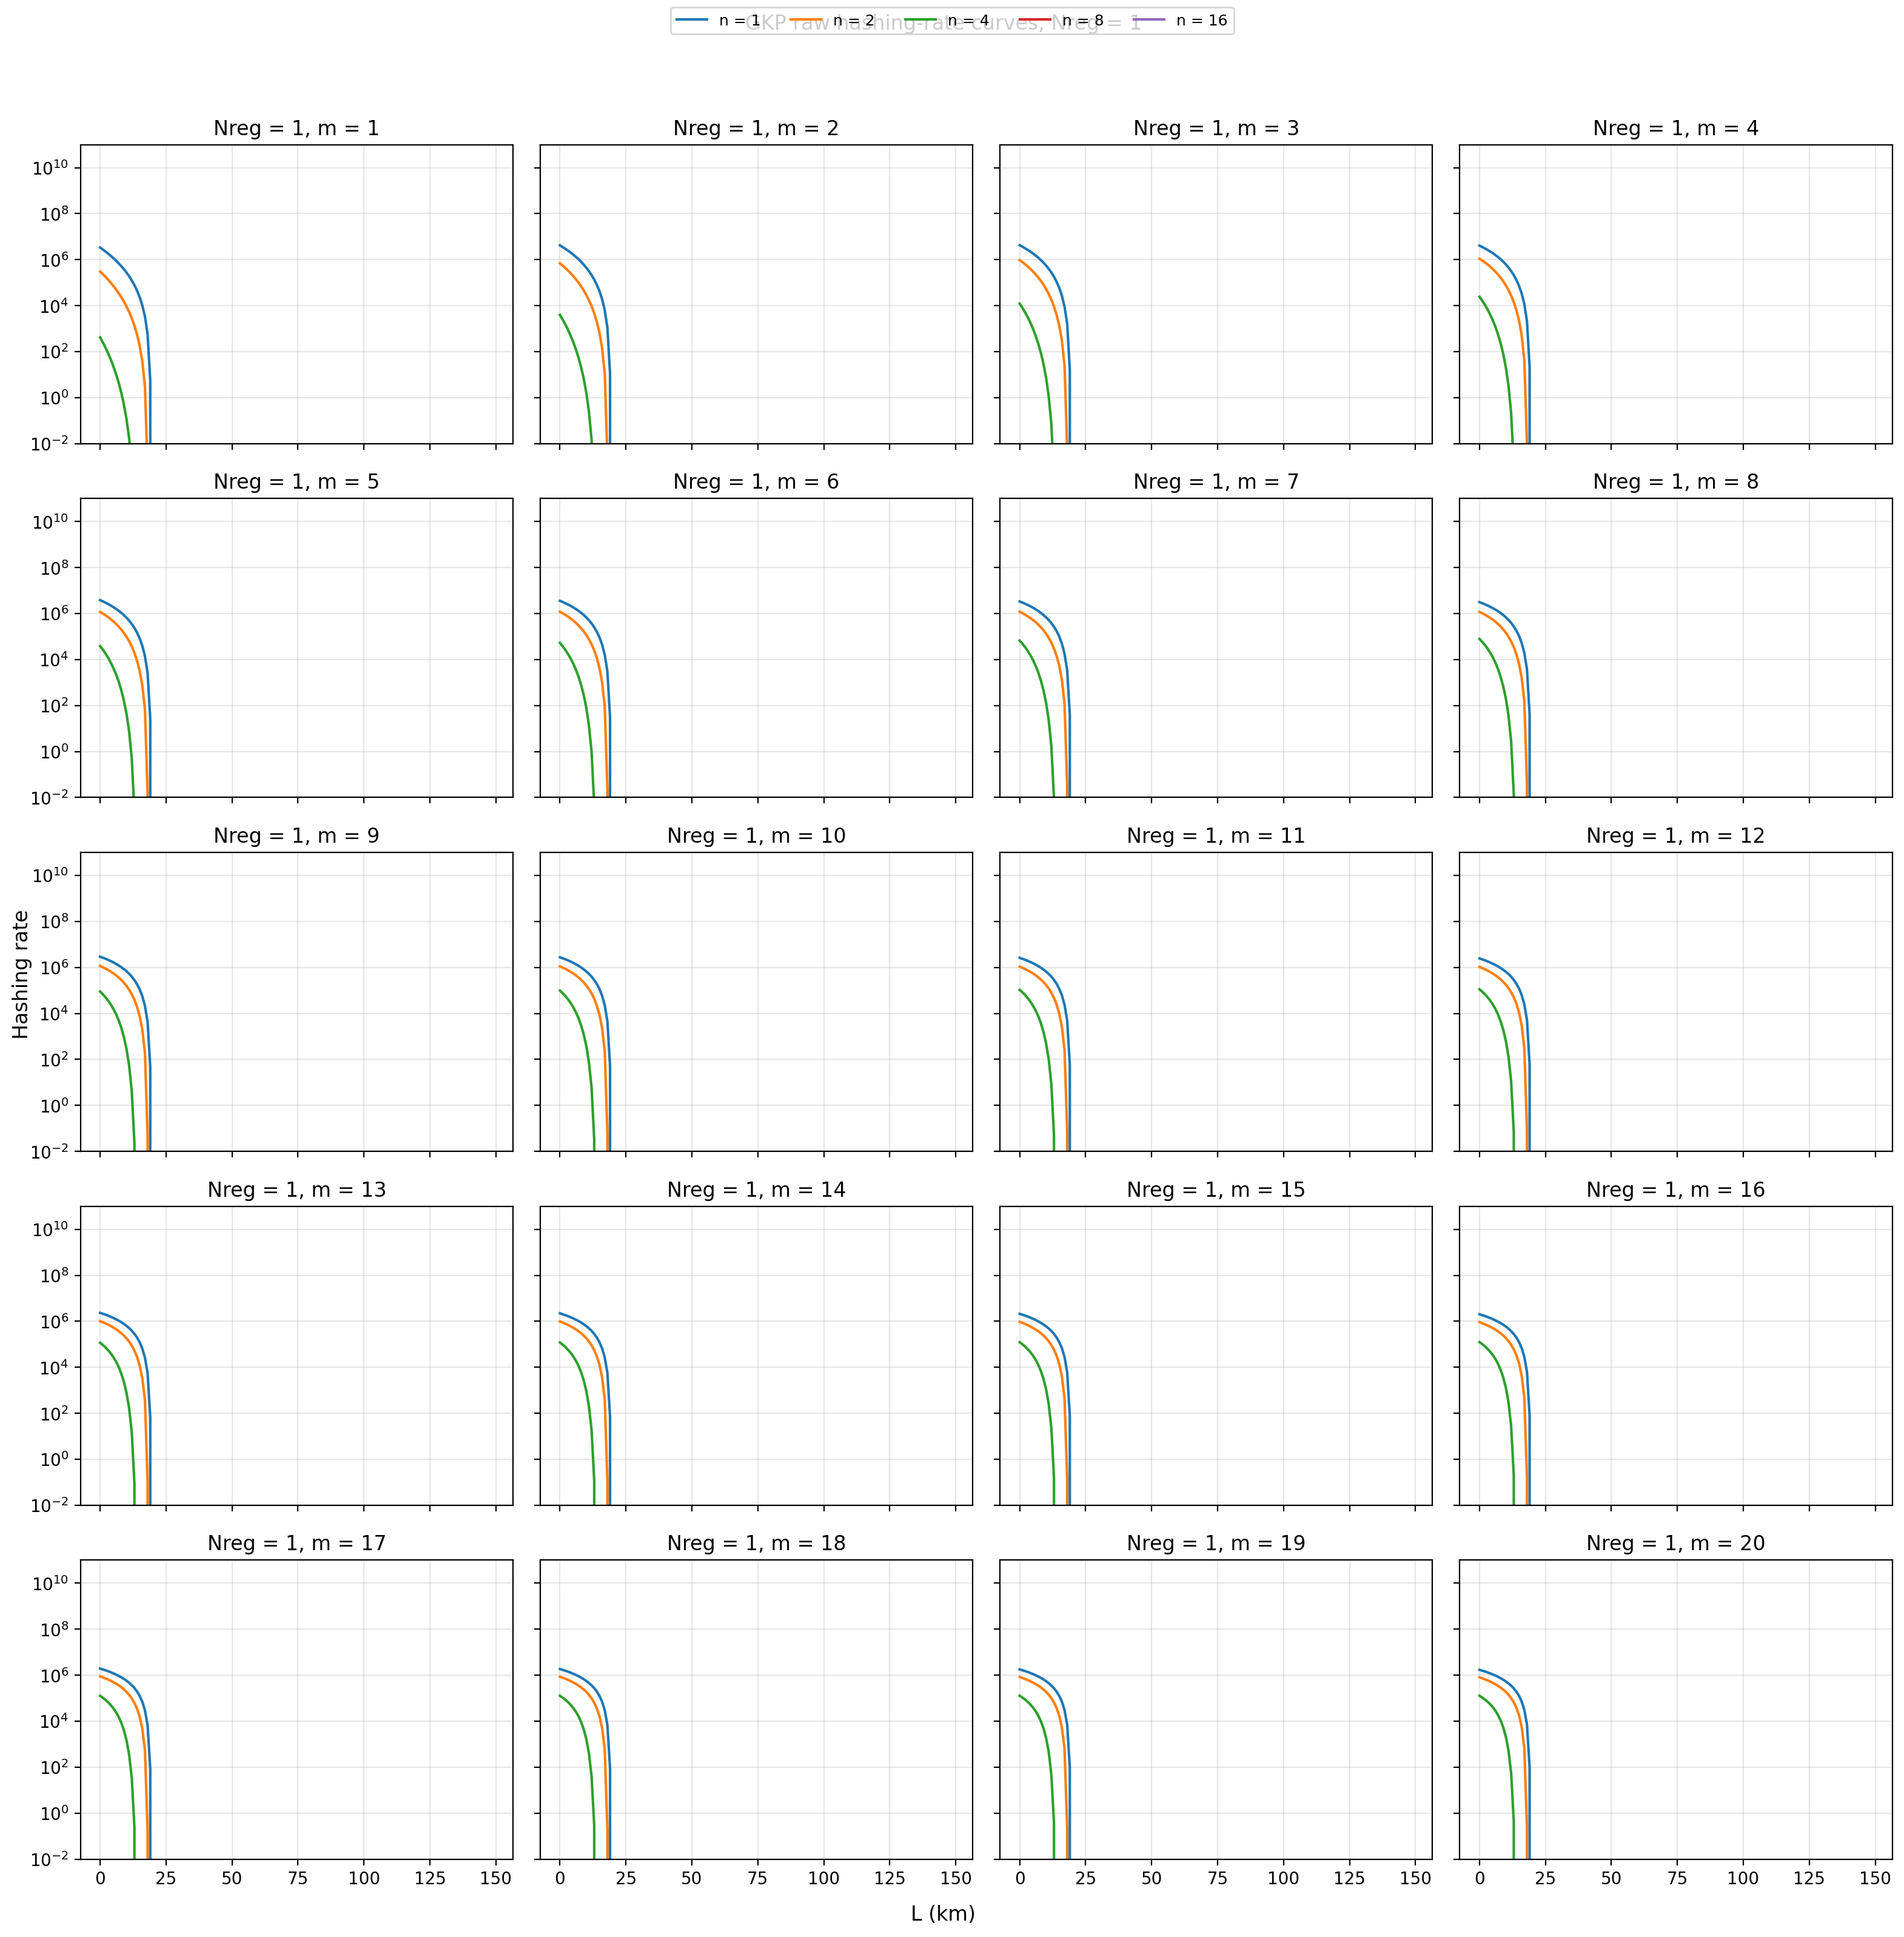


Plotting all m-plots for Nreg = 2


/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_9096/1687583300.py:32: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")


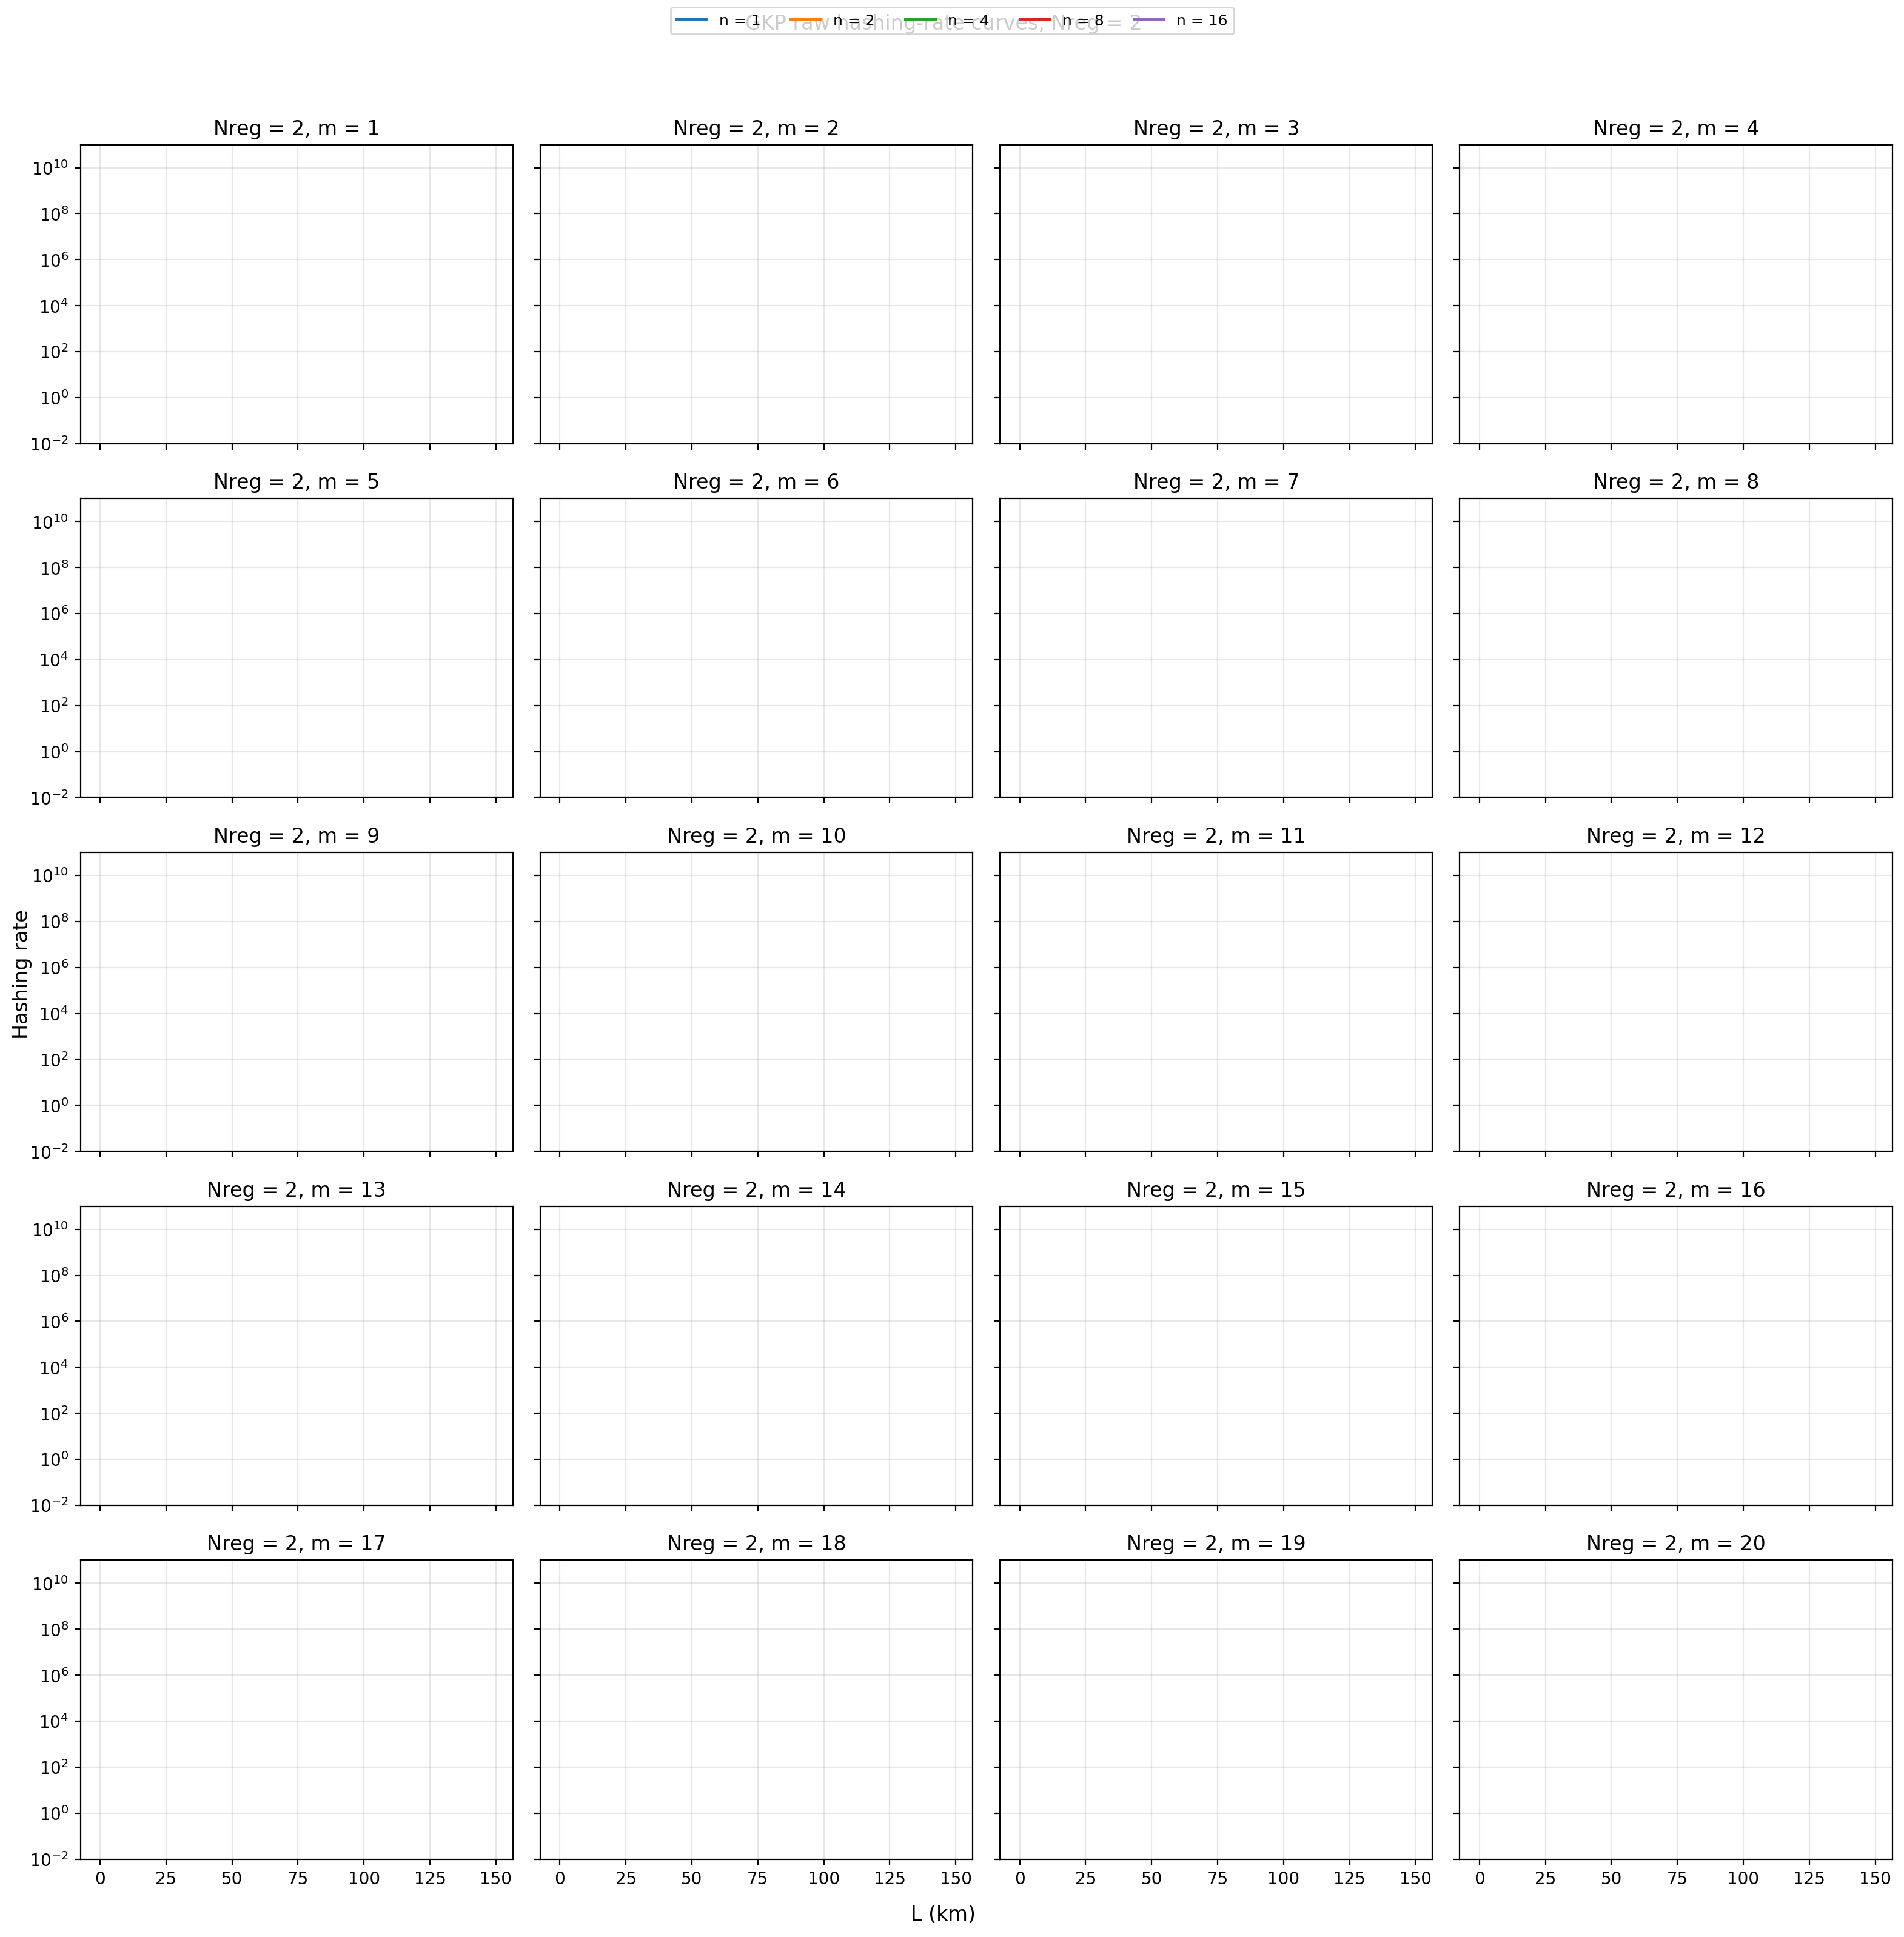


Plotting all m-plots for Nreg = 3


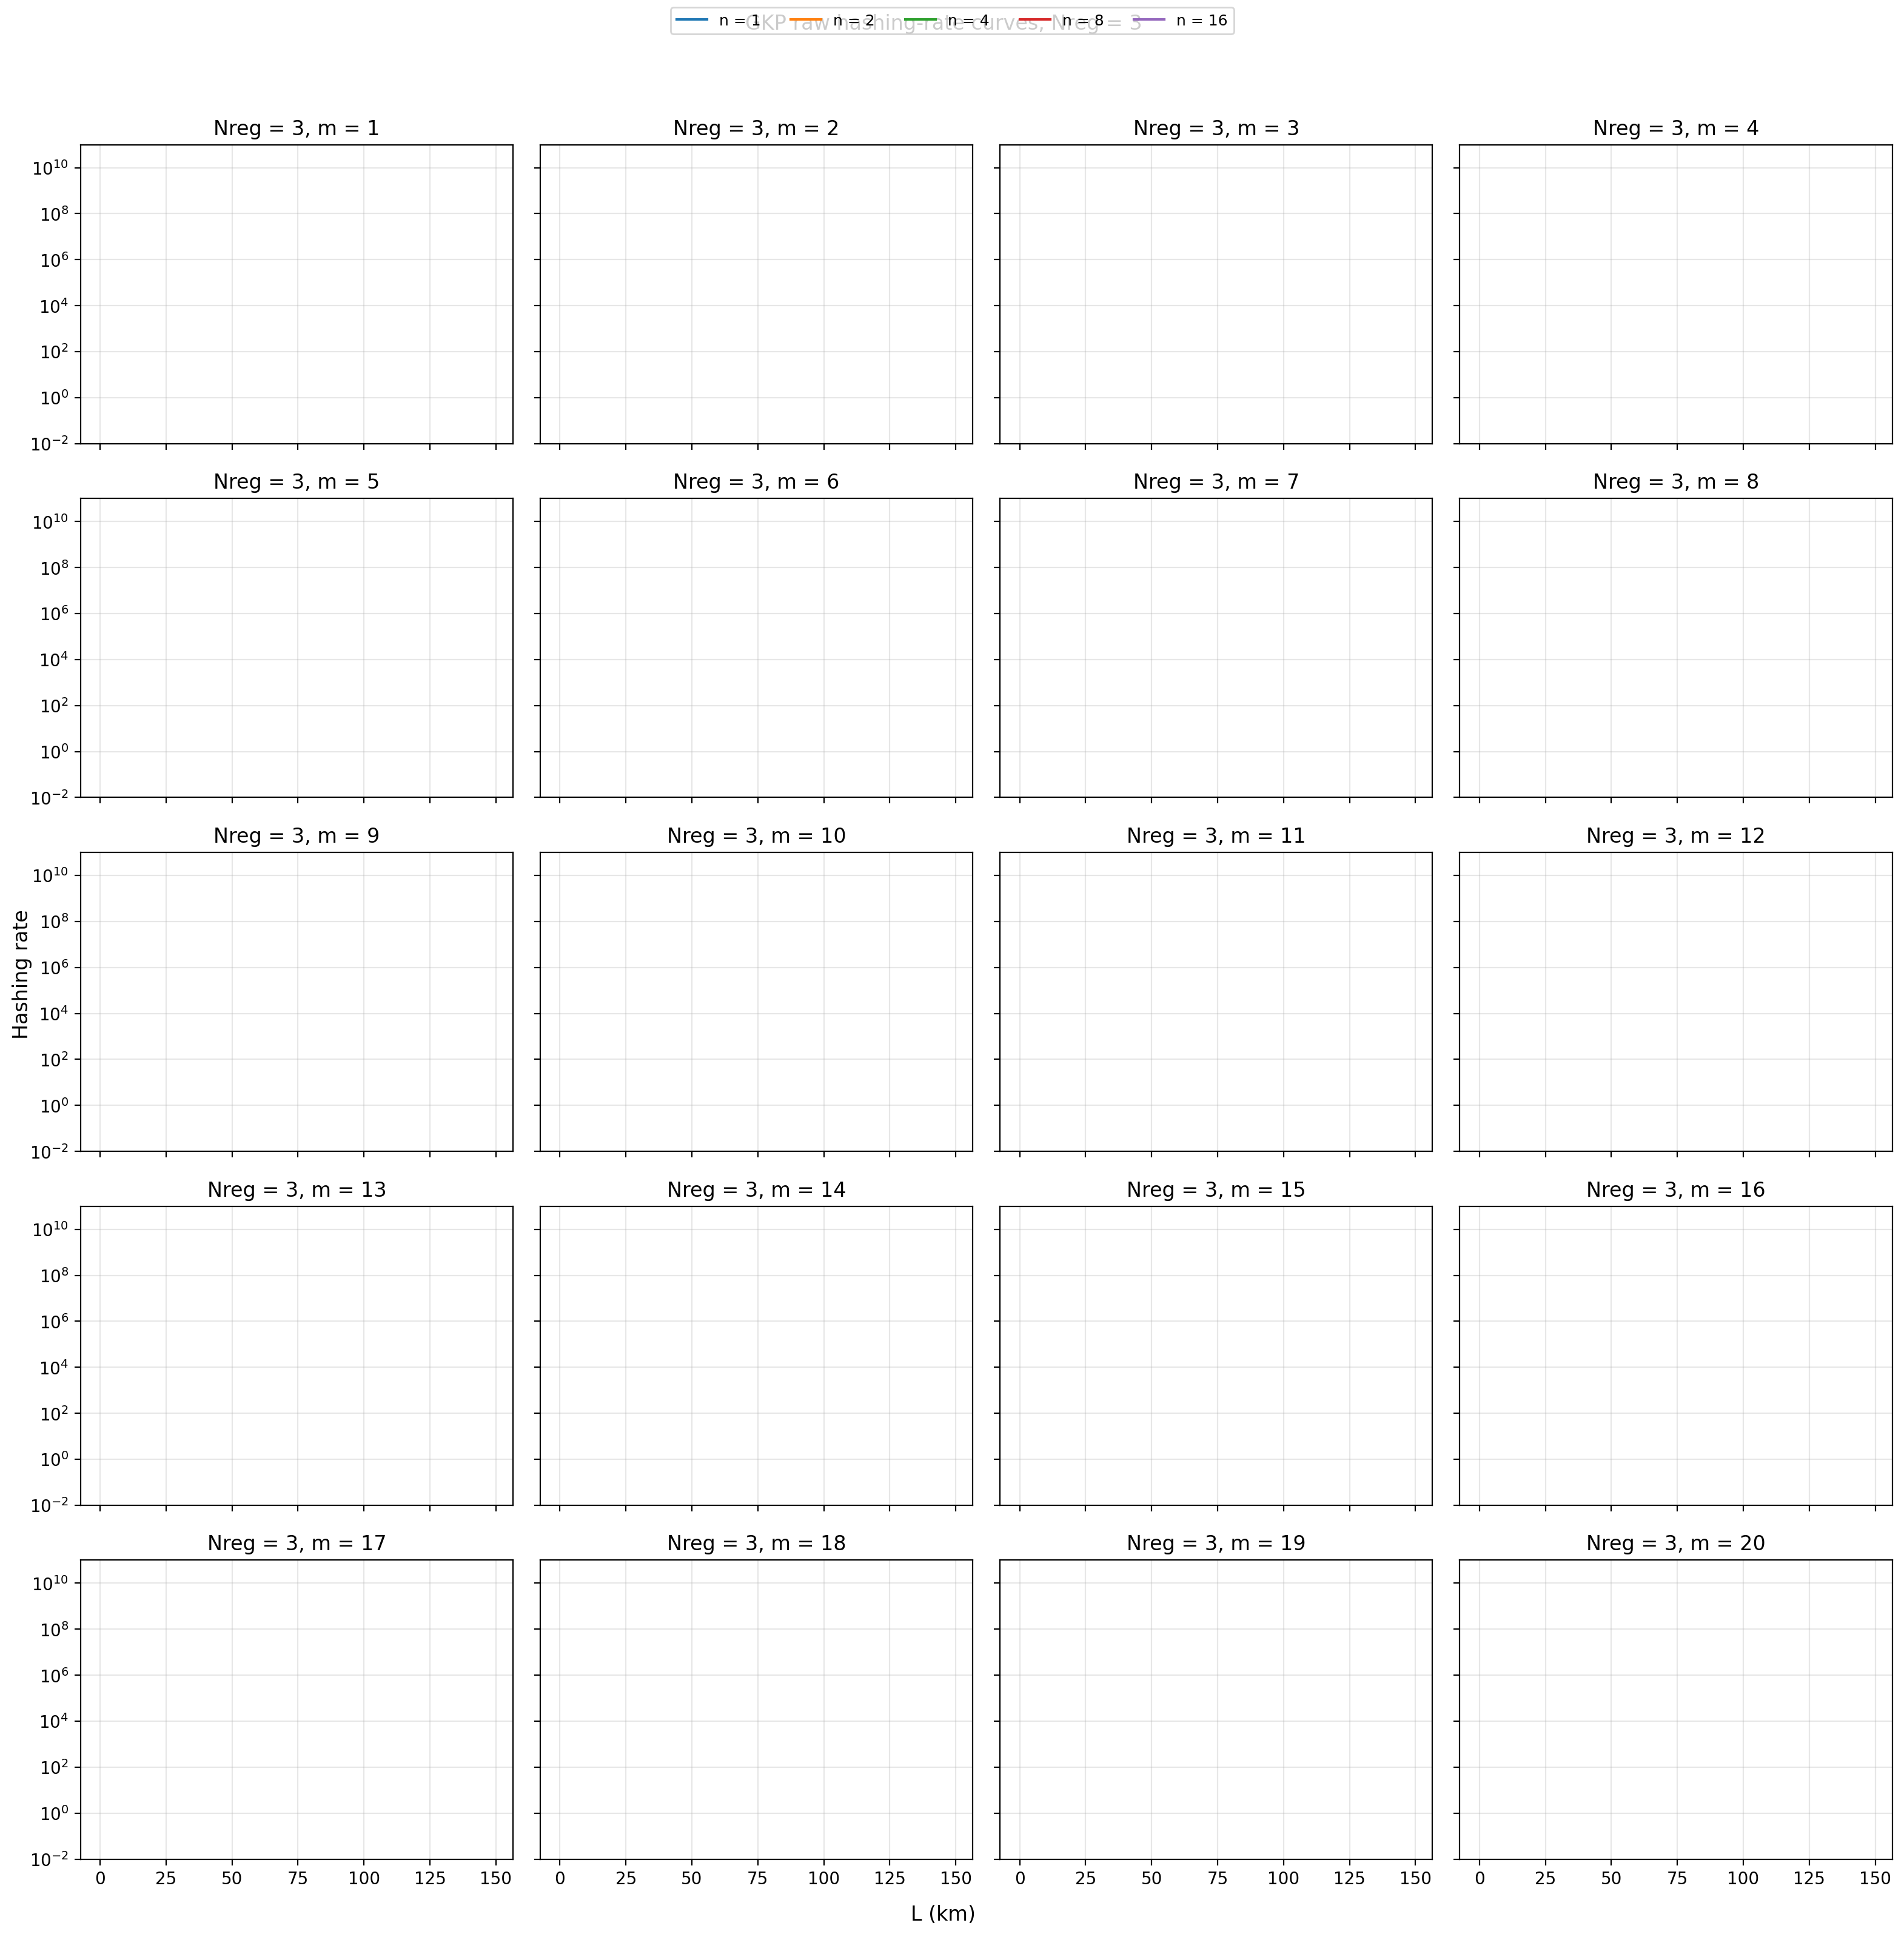


Plotting all m-plots for Nreg = 4


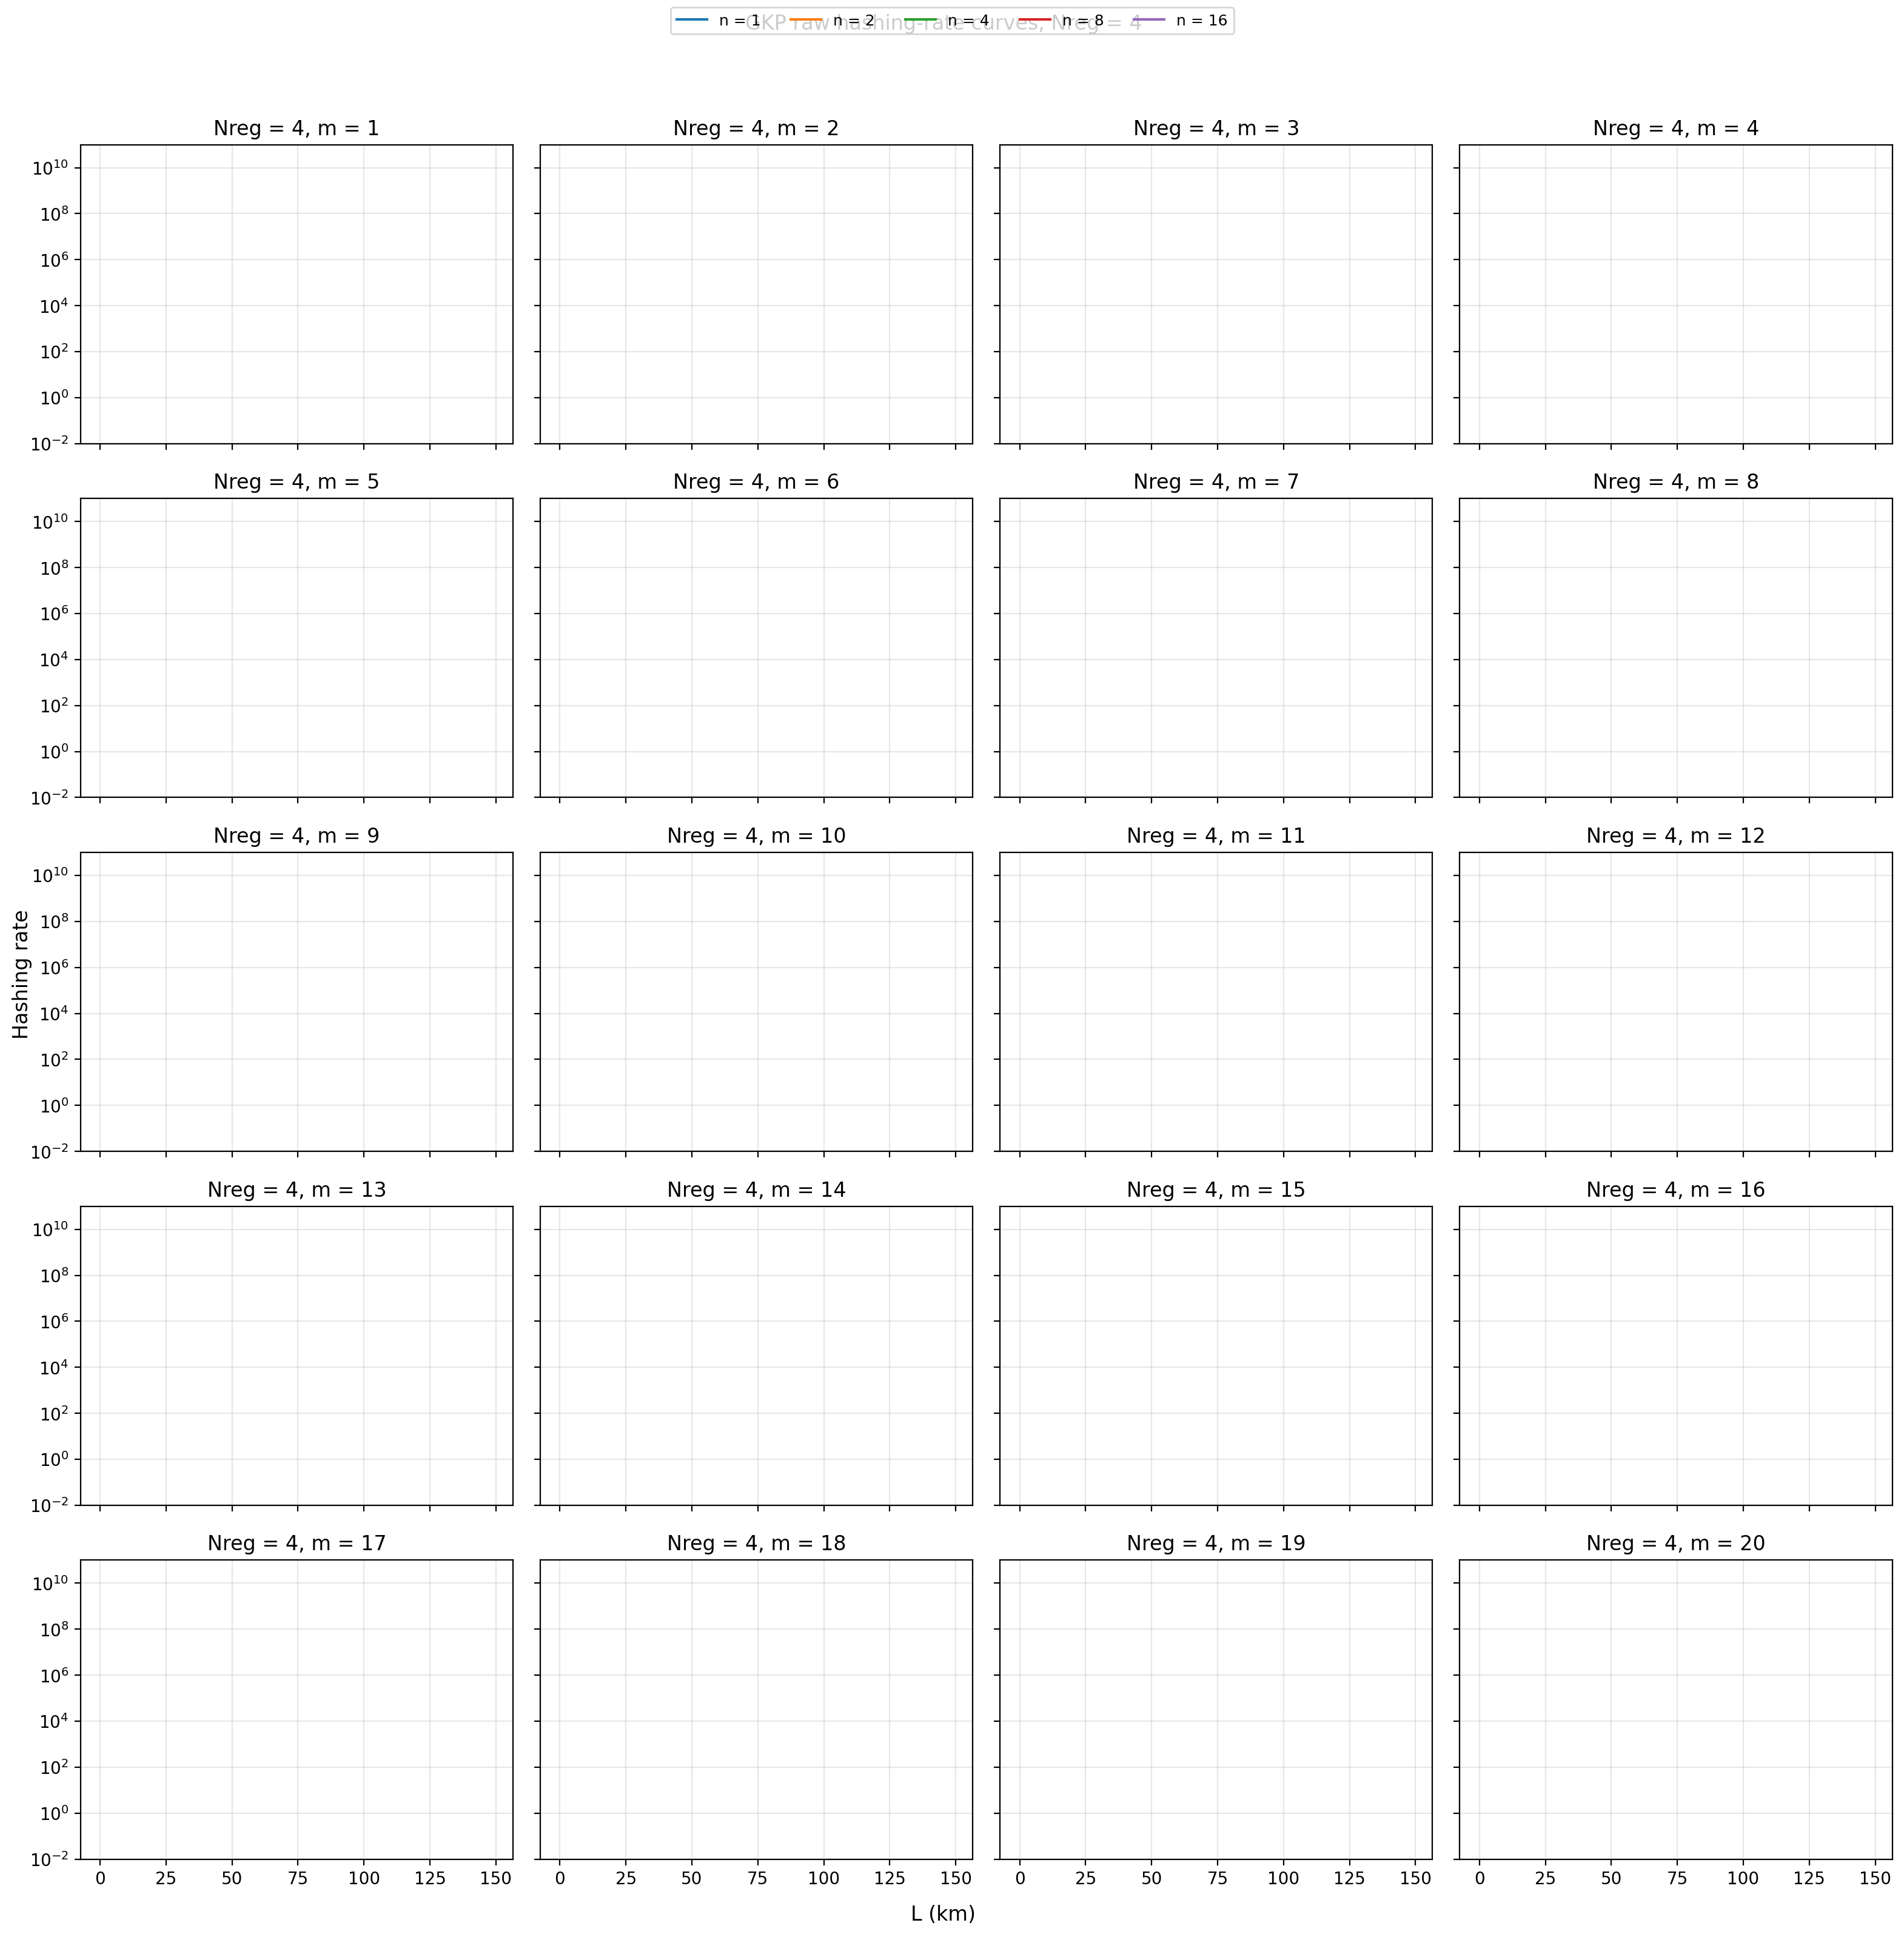


Plotting all m-plots for Nreg = 5


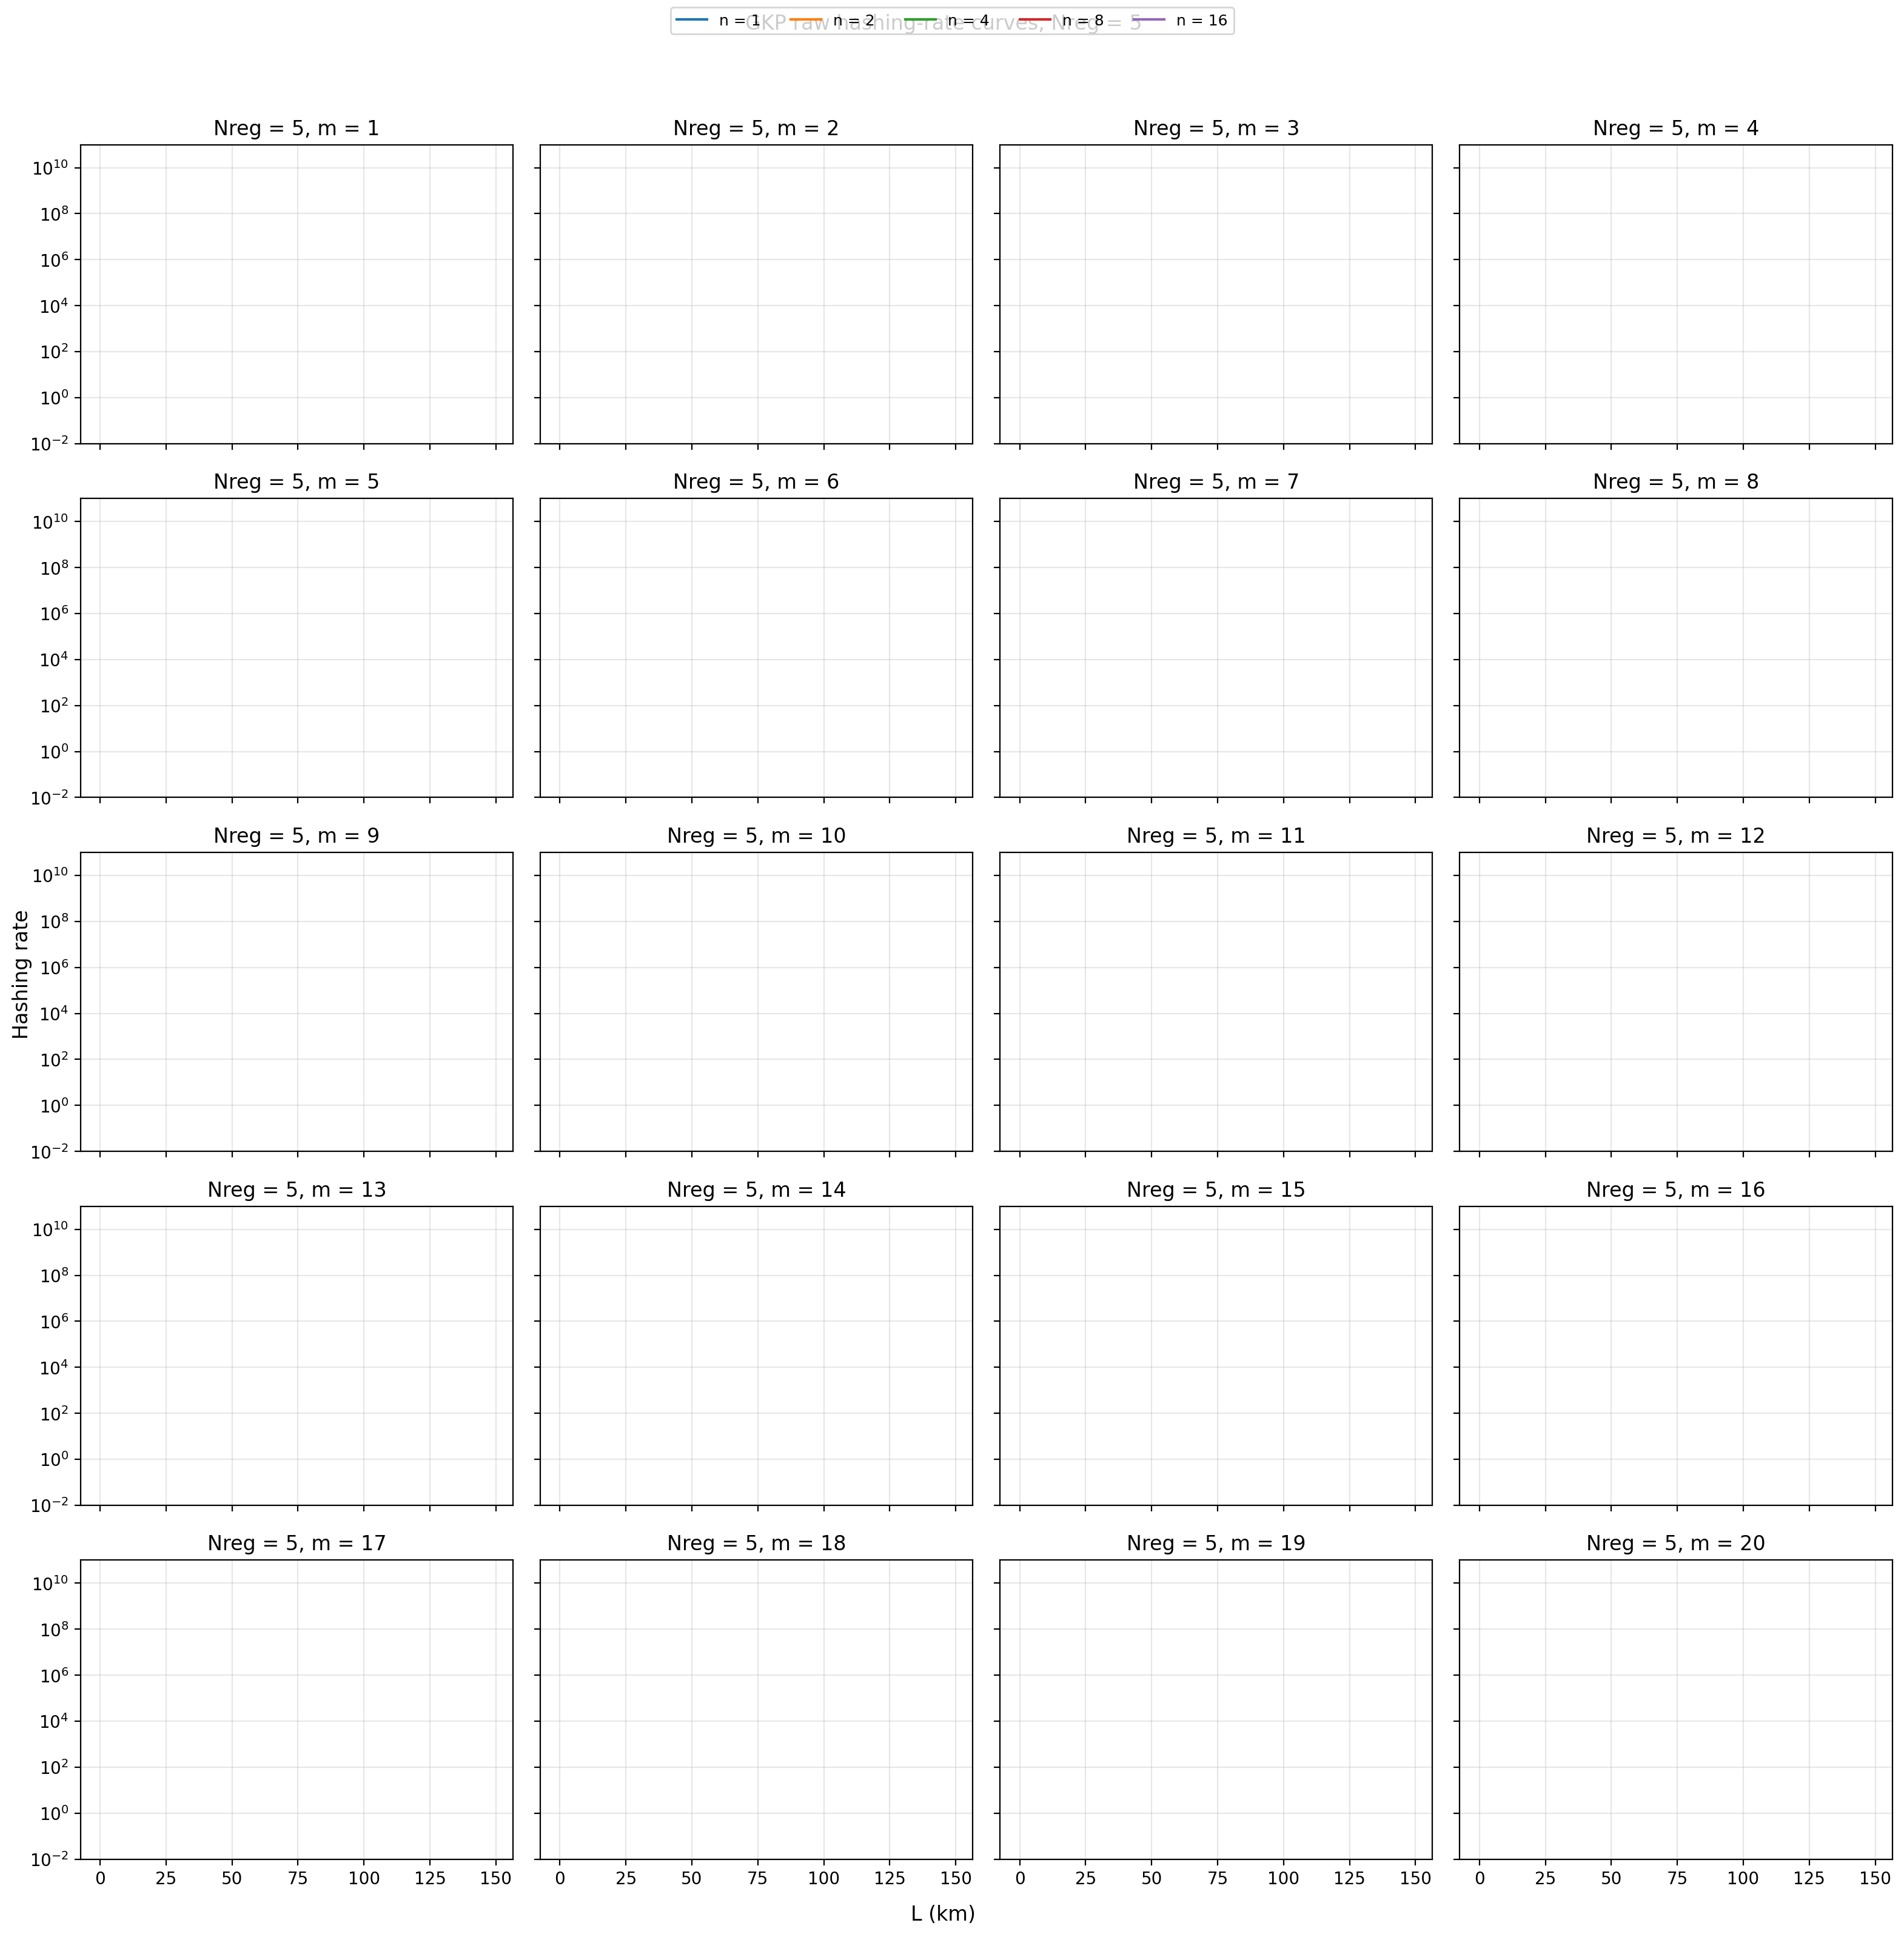


Plotting all m-plots for Nreg = 6


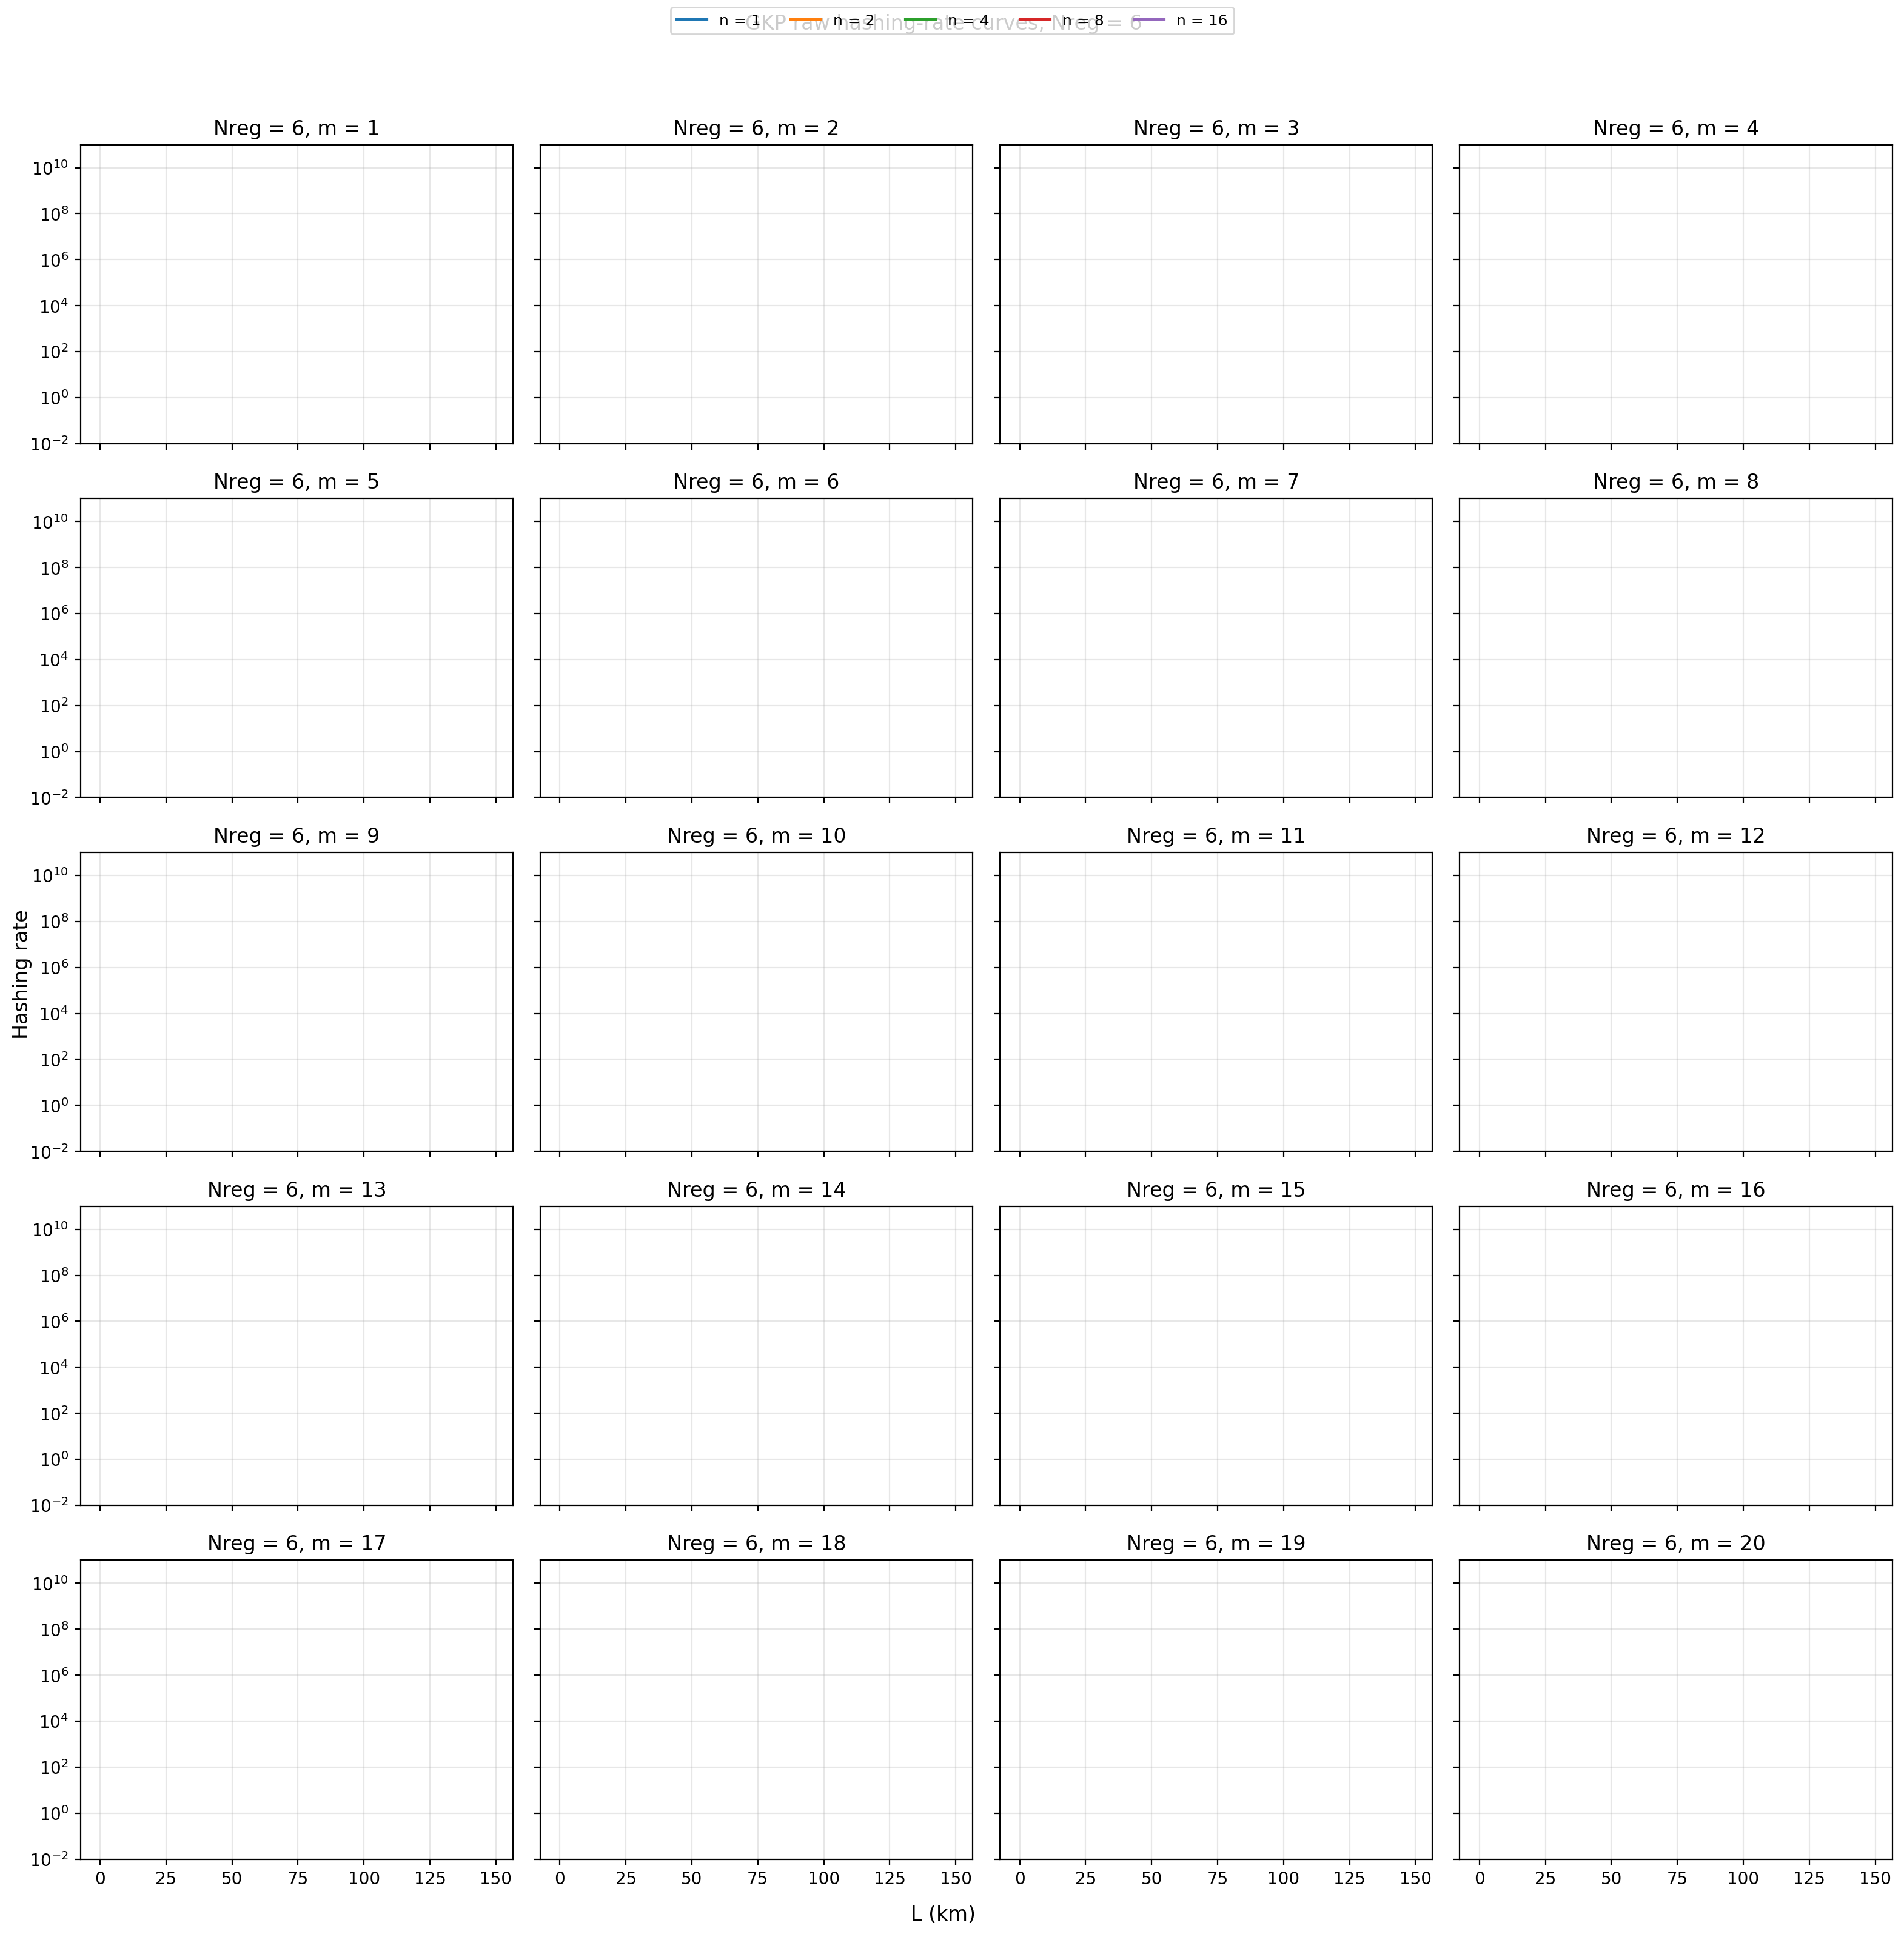


Plotting all m-plots for Nreg = 7


KeyError: np.int64(10)

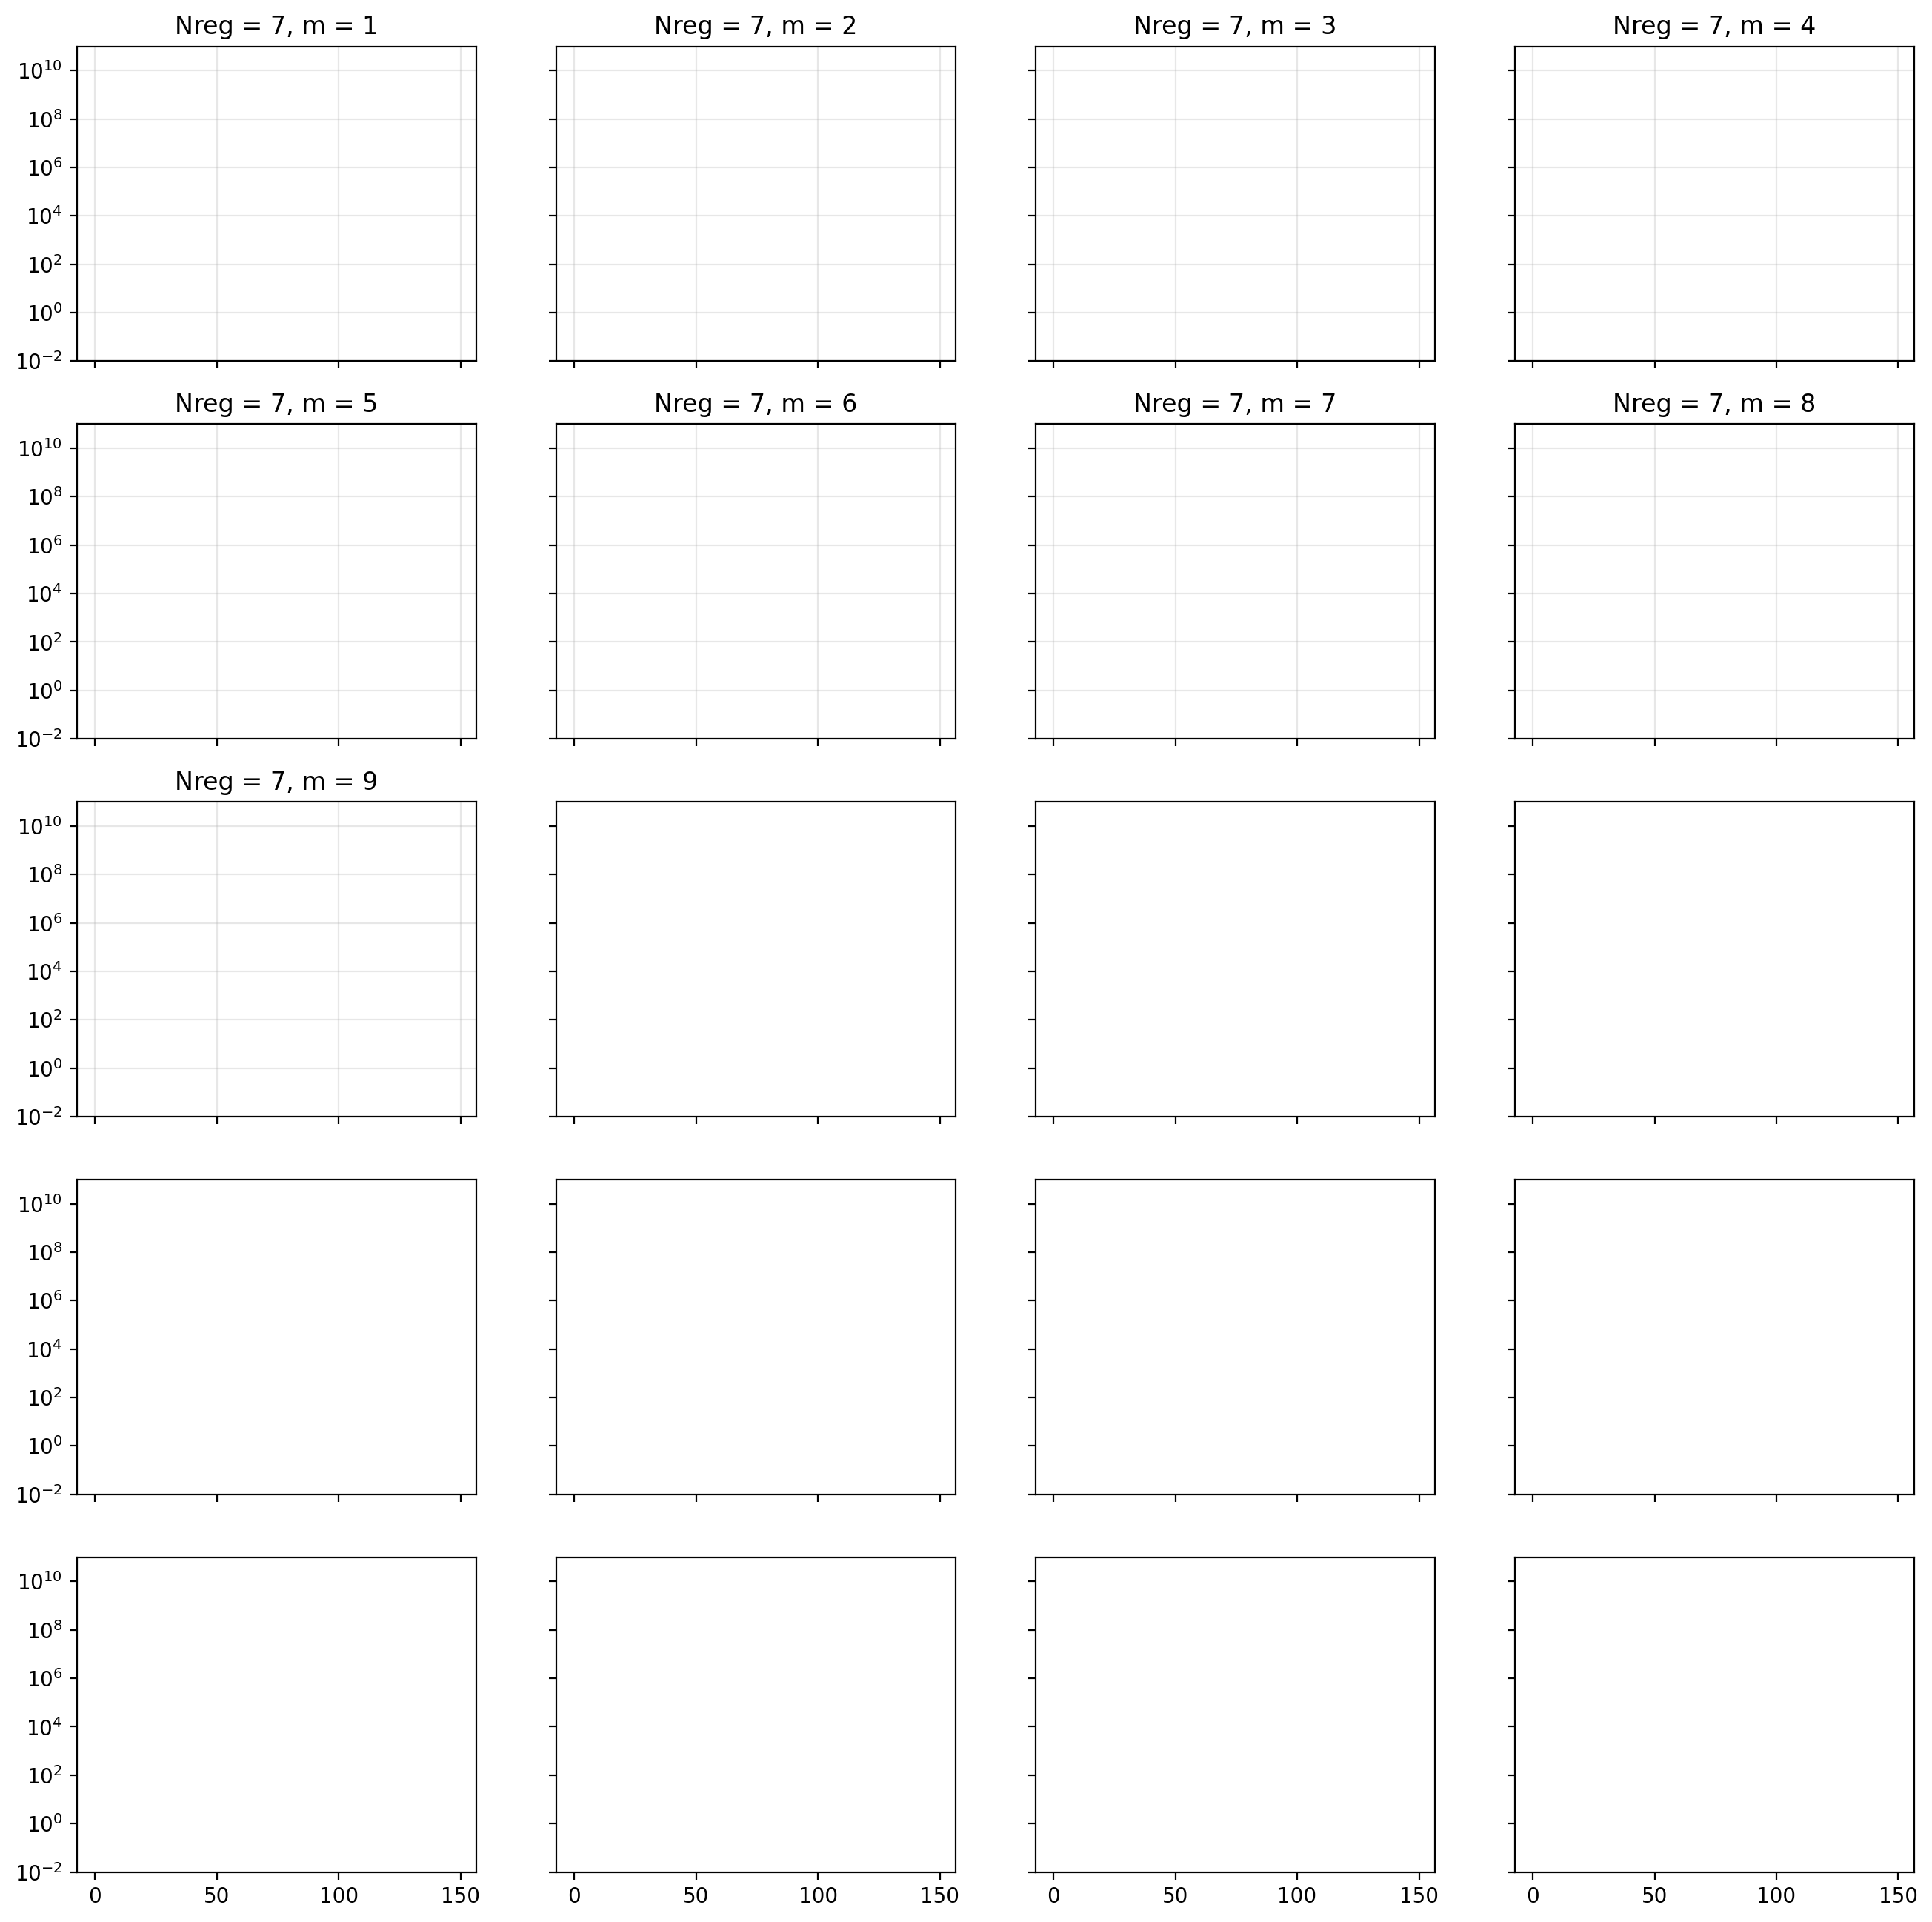

In [13]:
# ----------------------------
# Plot all 20 m-plots for each Nreg
# ----------------------------
for Nreg in Nreg_values:
    print(f"\nPlotting all m-plots for Nreg = {Nreg}")

    nplots = len(m_values)
    ncols = 4
    nrows = int(np.ceil(nplots / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4 * ncols, 3.2 * nrows),
        dpi=200,
        sharex=True,
        sharey=True,
    )
    axes = np.array(axes).reshape(-1)

    for idx, m in enumerate(m_values):
        ax = axes[idx]
        out = all_results[Nreg][m]

        for n in n_vals:
            ax.plot(
                out["Ls"],
                out["fixed_n_data"][n]["rate"],
                label=f"n = {n}"
            )

        ax.set_yscale("log")
        ax.set_ylim(bottom = 1e-2 , top = 1e11)
        ax.set_title(f"Nreg = {Nreg}, m = {m}")
        ax.grid(True, which="both", alpha=0.3)

    # turn off unused subplots
    for j in range(nplots, len(axes)):
        axes[j].axis("off")

    # one shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(n_vals), fontsize=9)

    fig.suptitle(f"GKP raw hashing-rate curves, Nreg = {Nreg}", y=0.995)
    fig.supxlabel("L (km)")
    fig.supylabel("Hashing rate")

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    fig_path = os.path.join(output_dir, f"gkp_raw_curves_Nreg_{Nreg}.png")
    plt.savefig(fig_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print("\nDone.")

In [ ]:
all_results = np.load(
    "gkp_raw_results.npy",
    allow_pickle=True
).item()

In [ ]:
all_results

# Maximisation over HR curves


Plotting all available m-plots for Nreg = 1


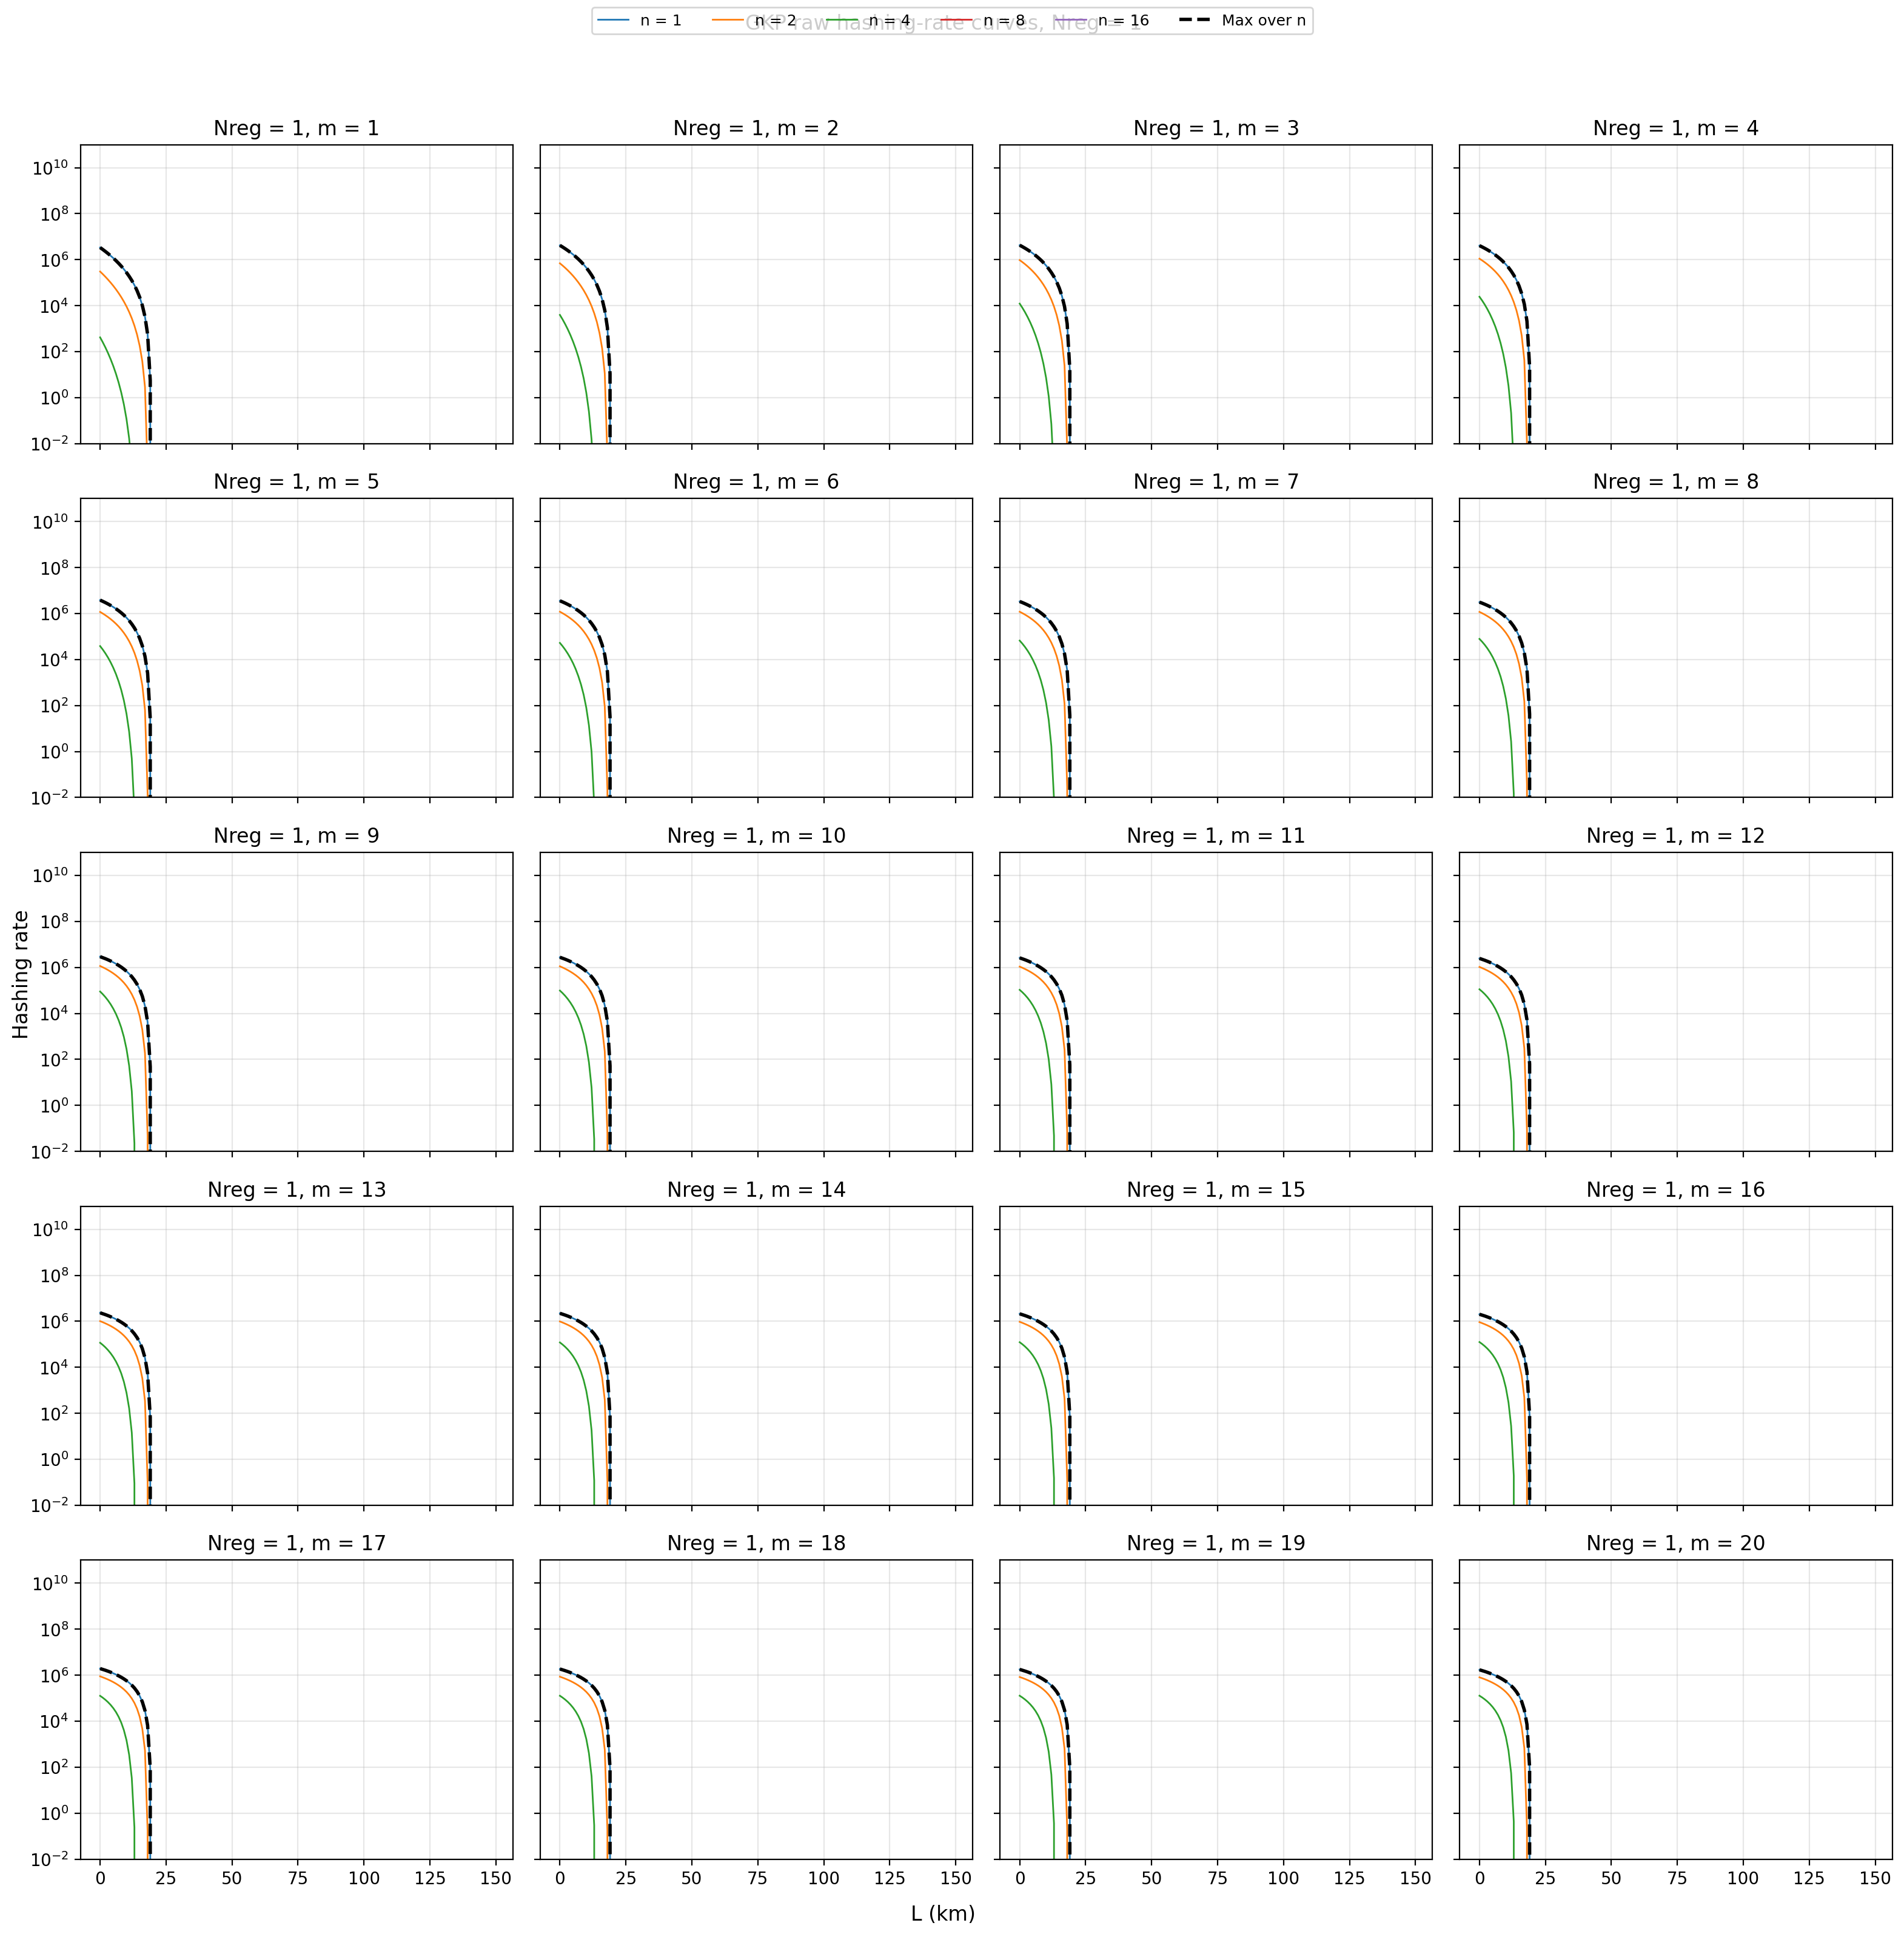


Plotting all available m-plots for Nreg = 2


/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_9096/3877607531.py:57: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")


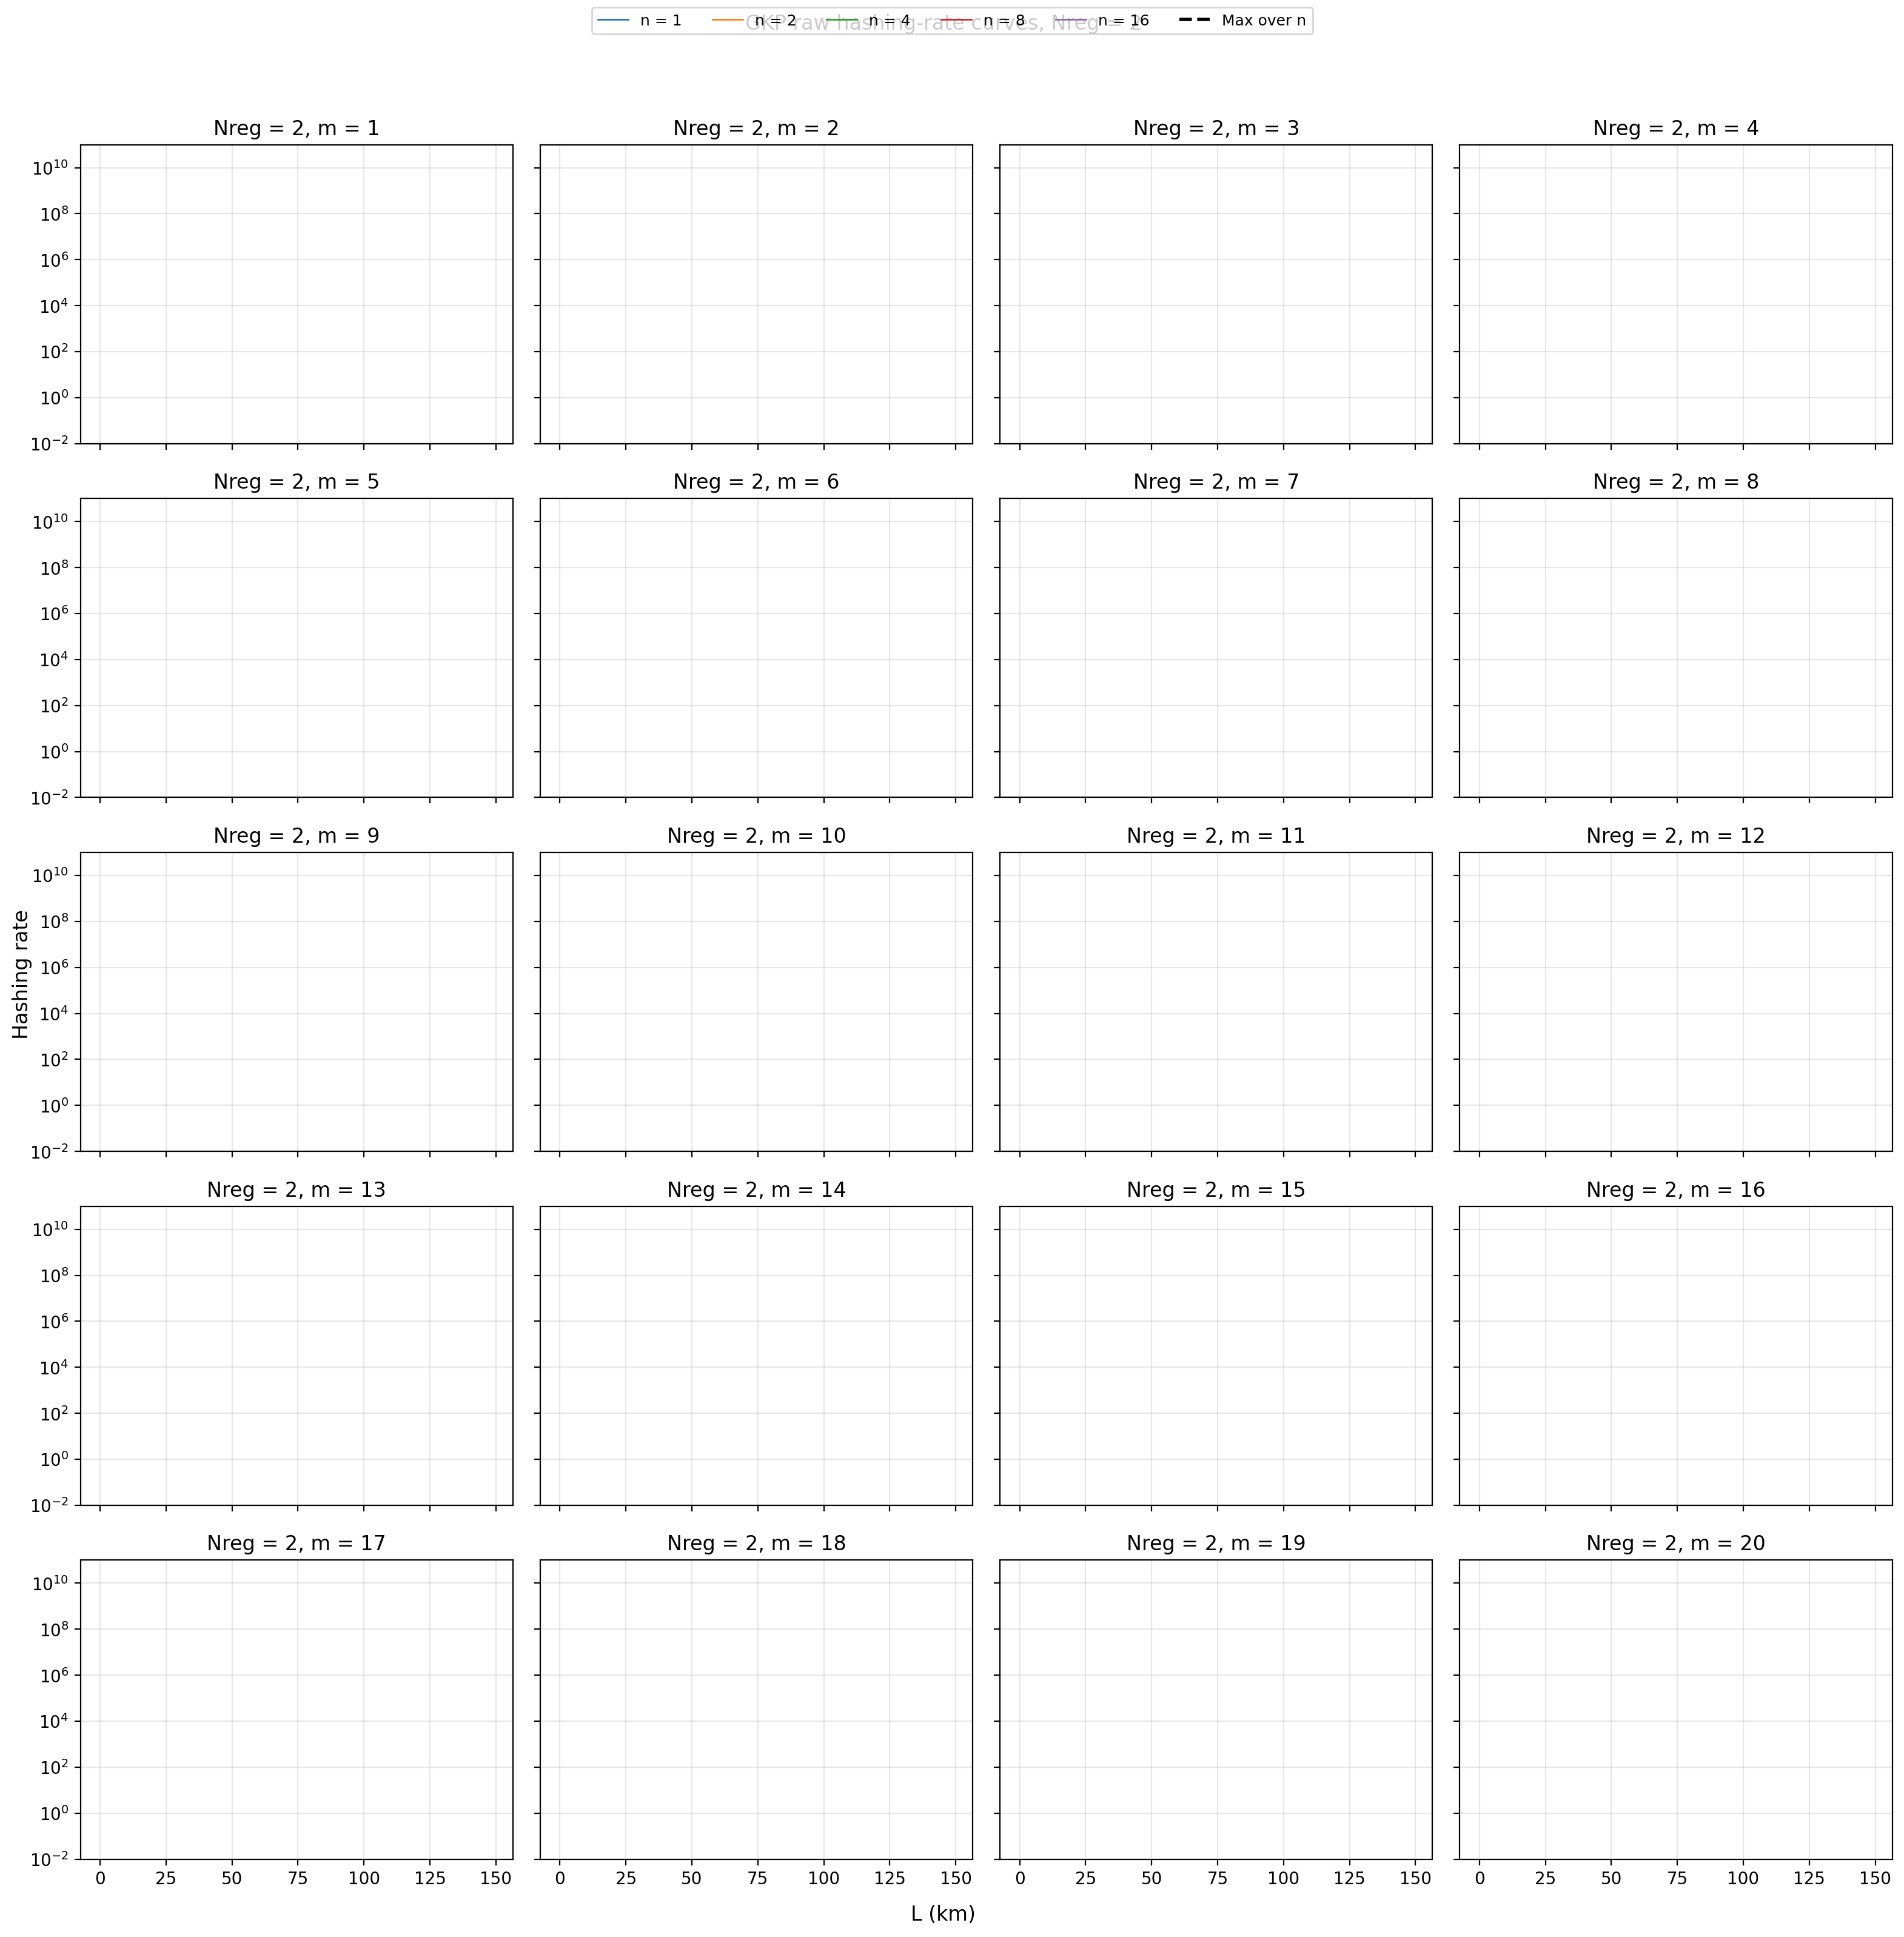


Plotting all available m-plots for Nreg = 3


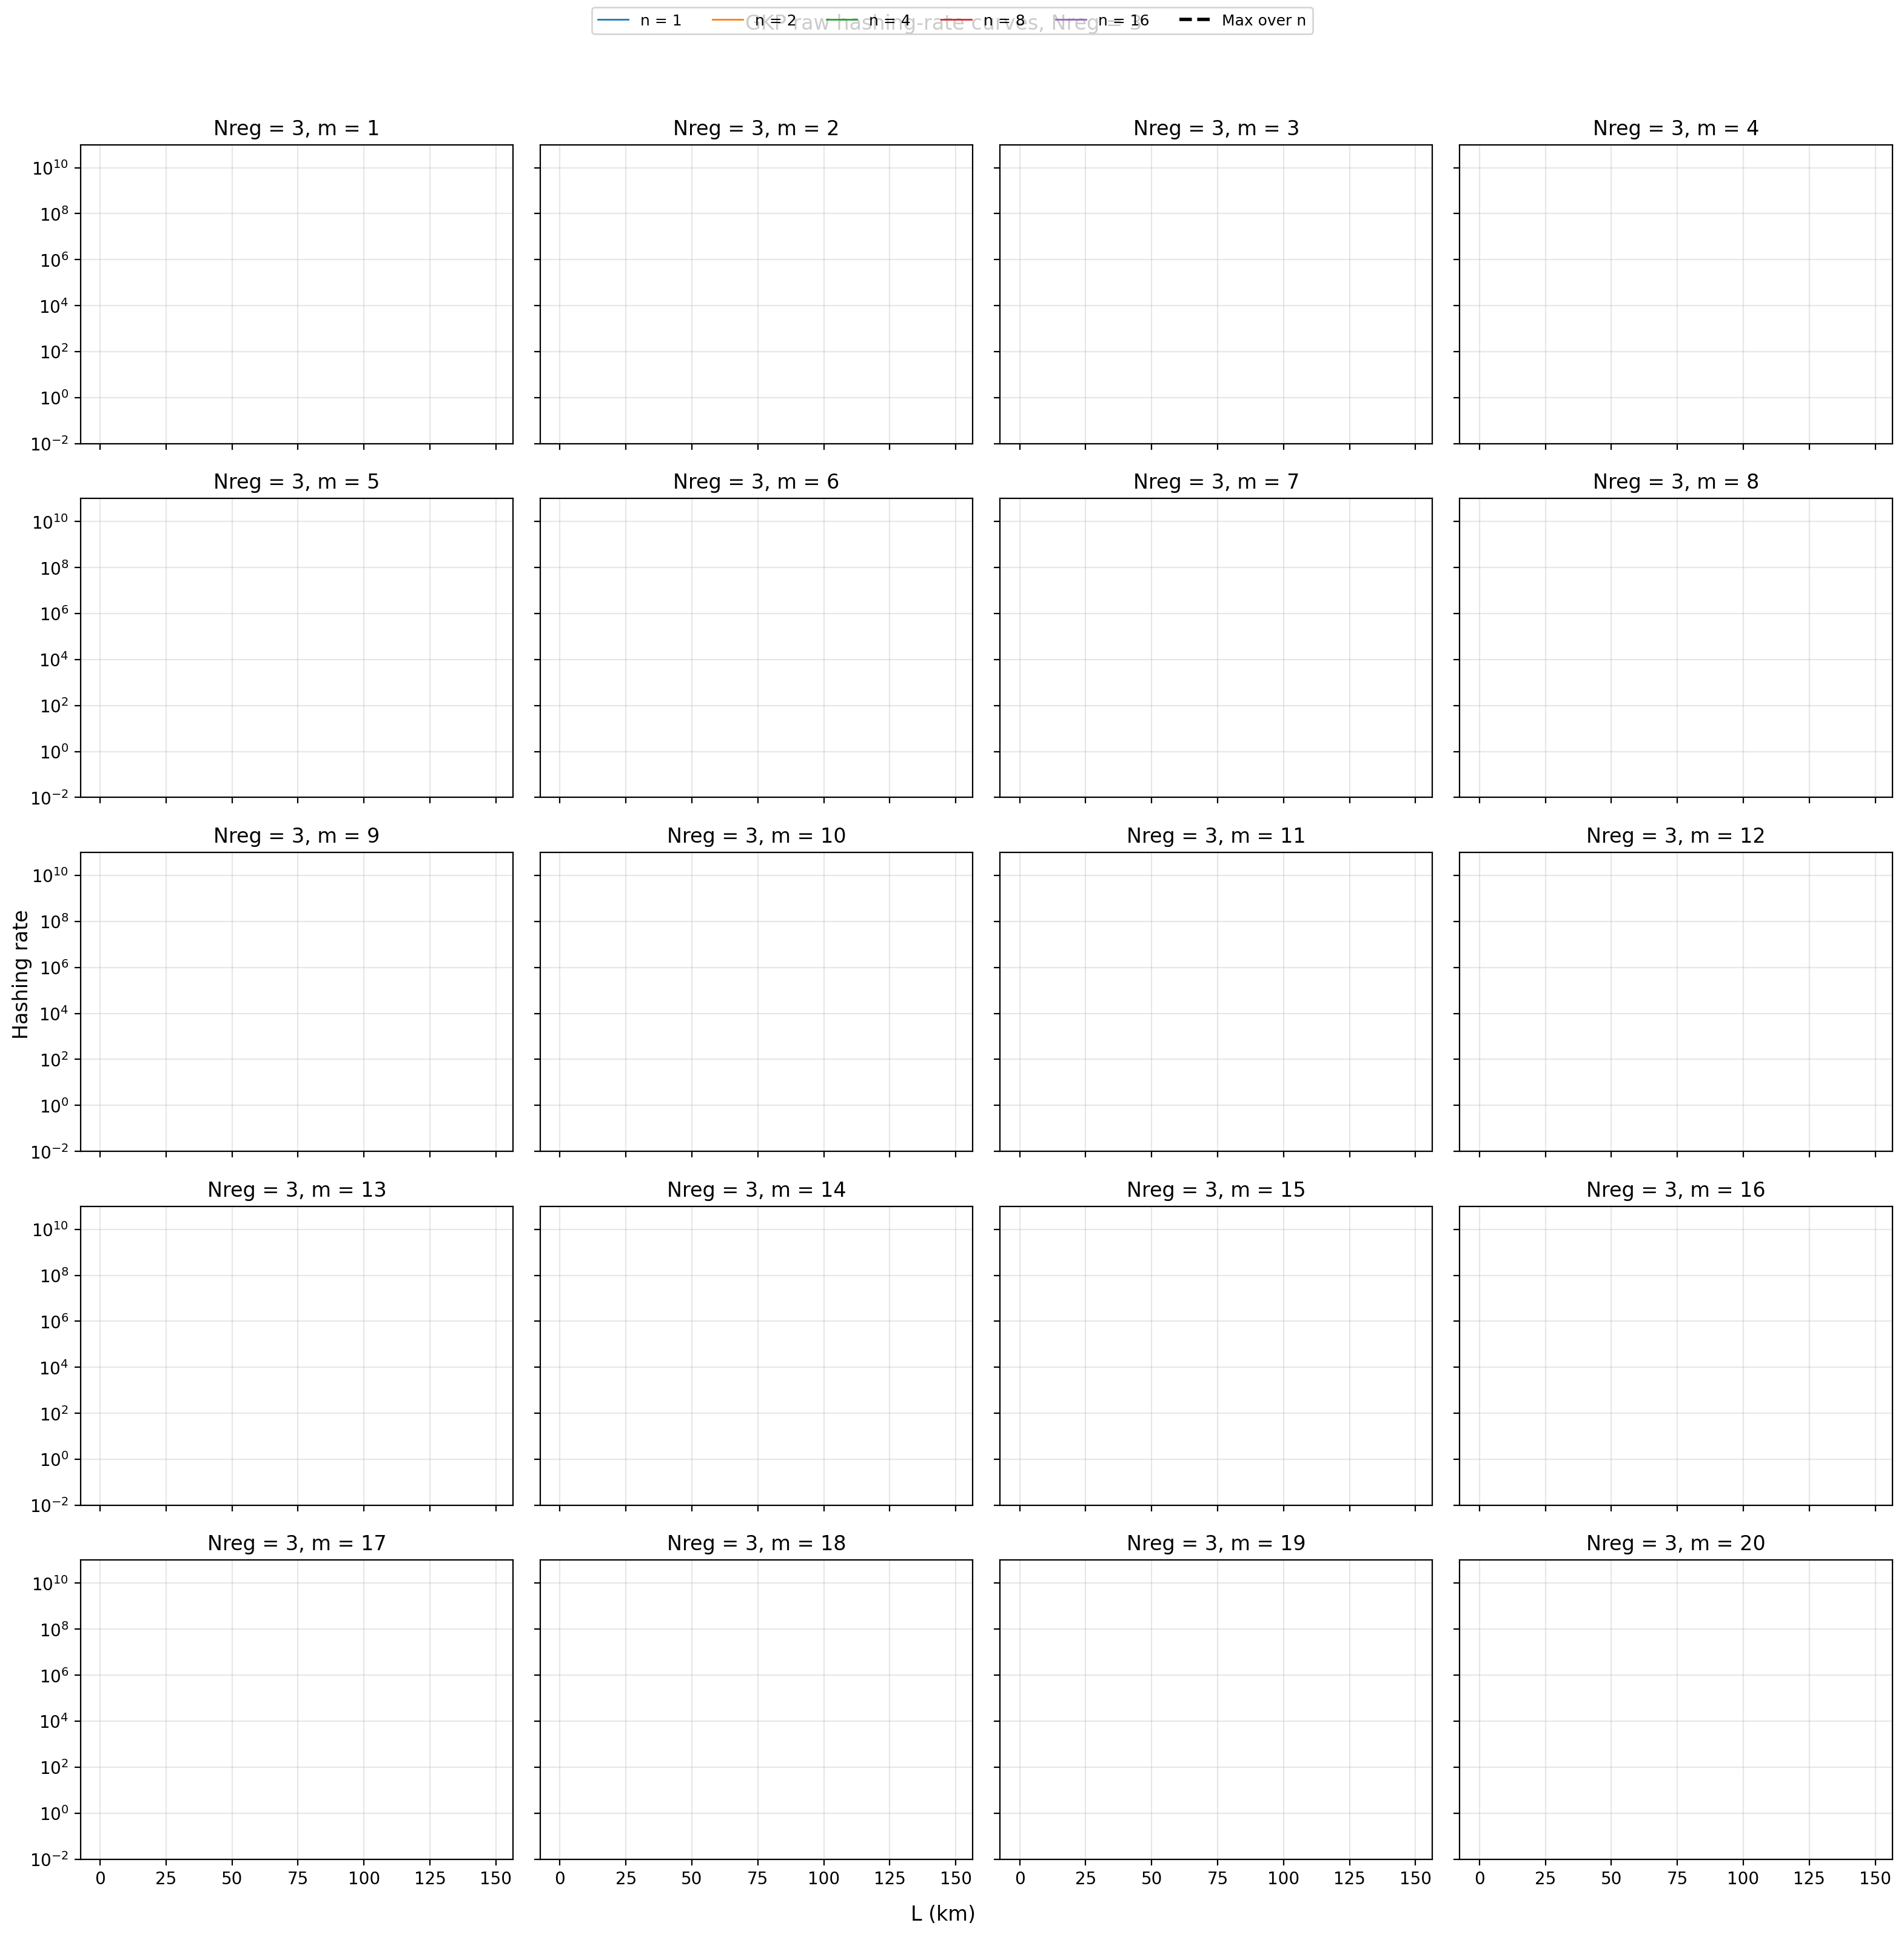


Plotting all available m-plots for Nreg = 4


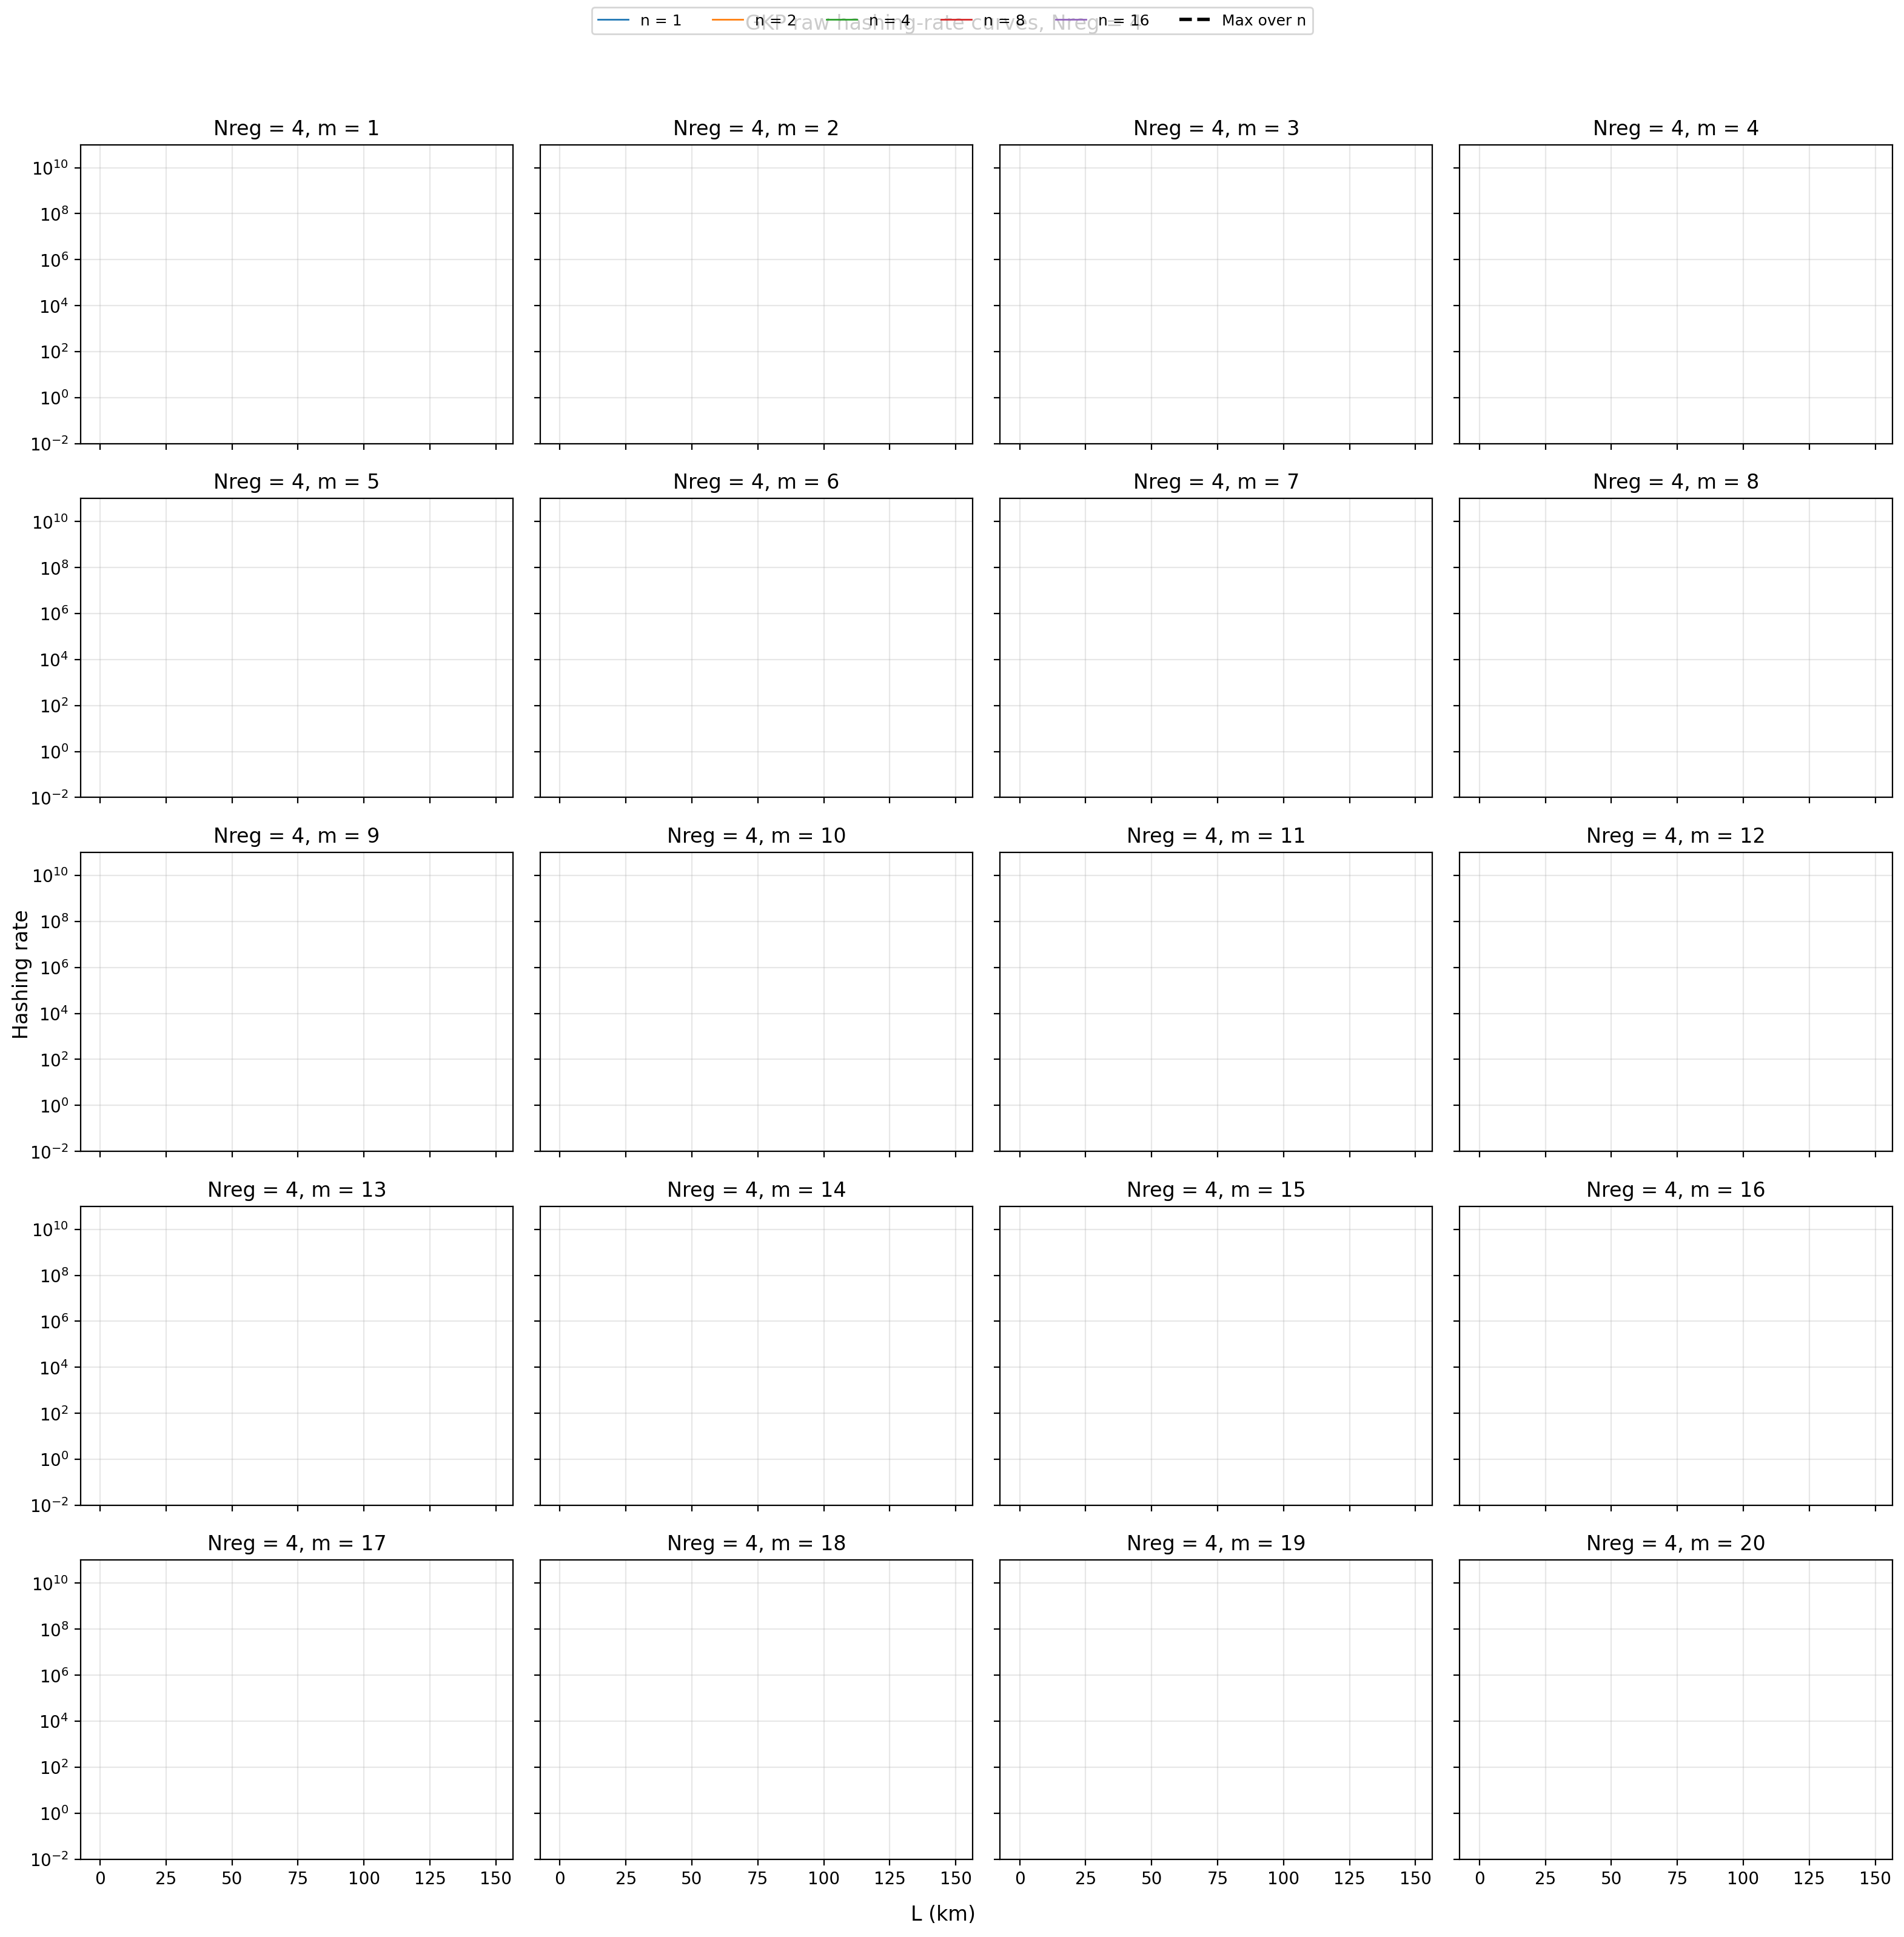


Plotting all available m-plots for Nreg = 5


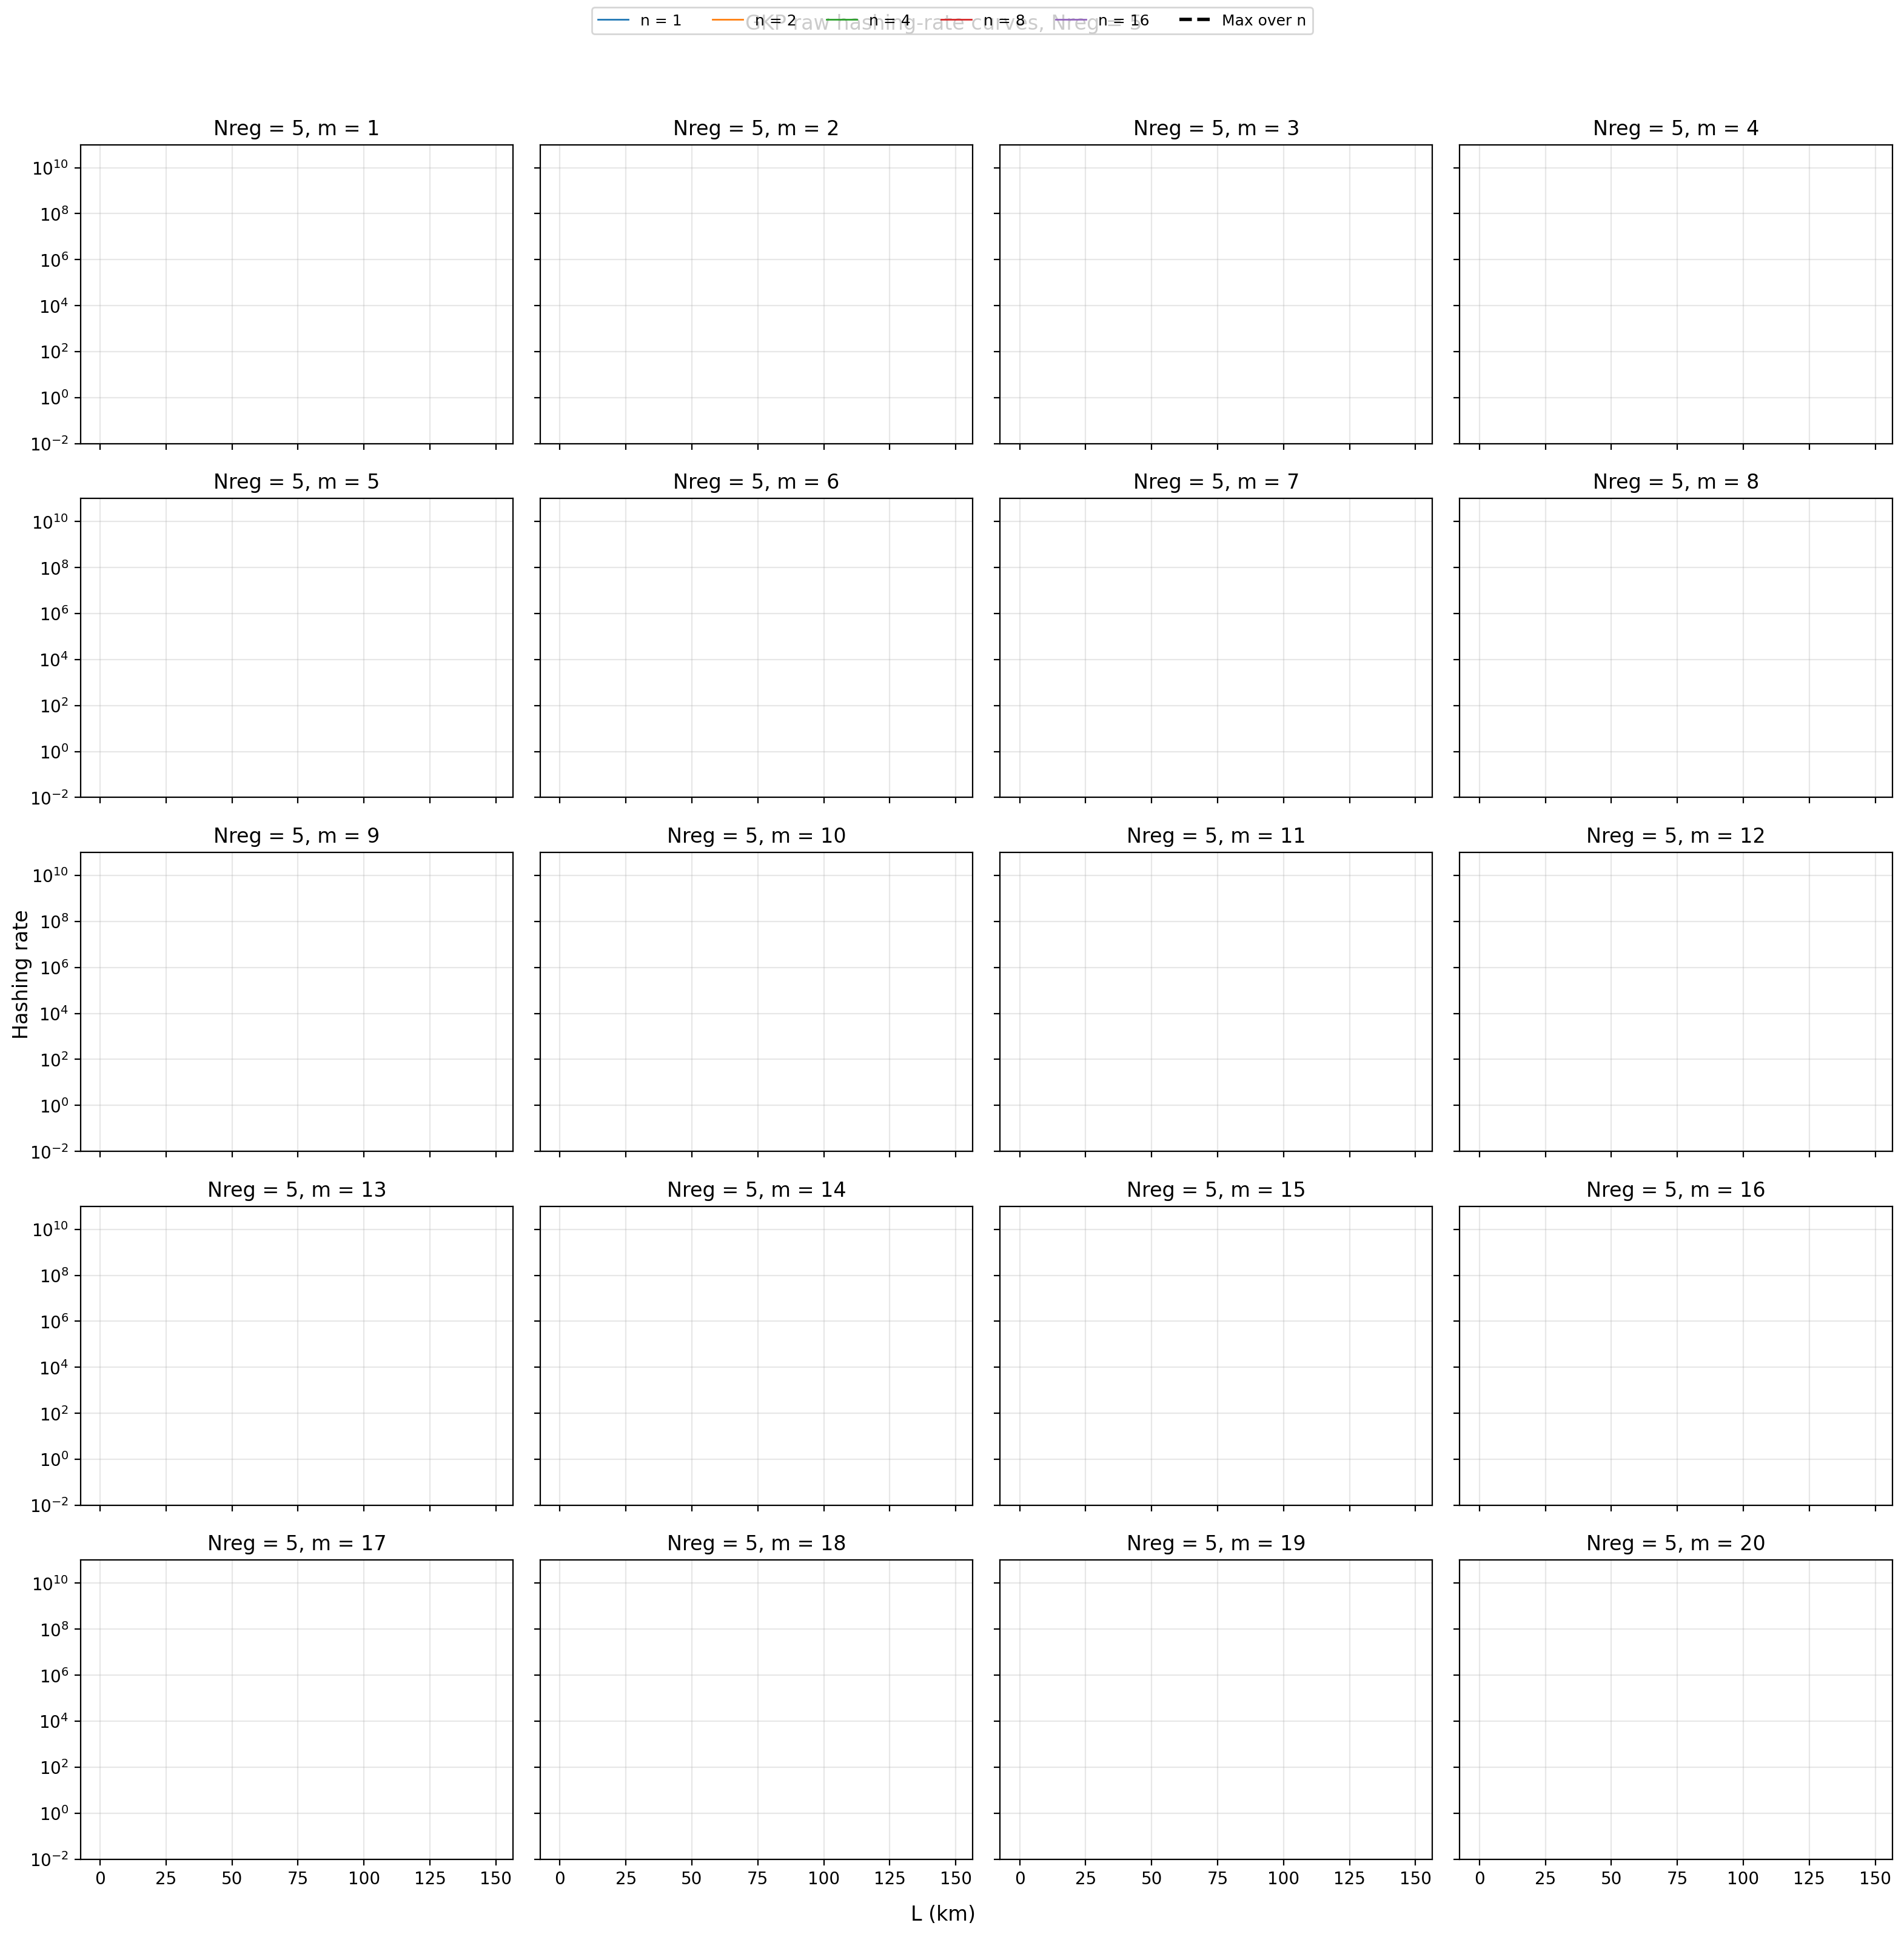


Plotting all available m-plots for Nreg = 6


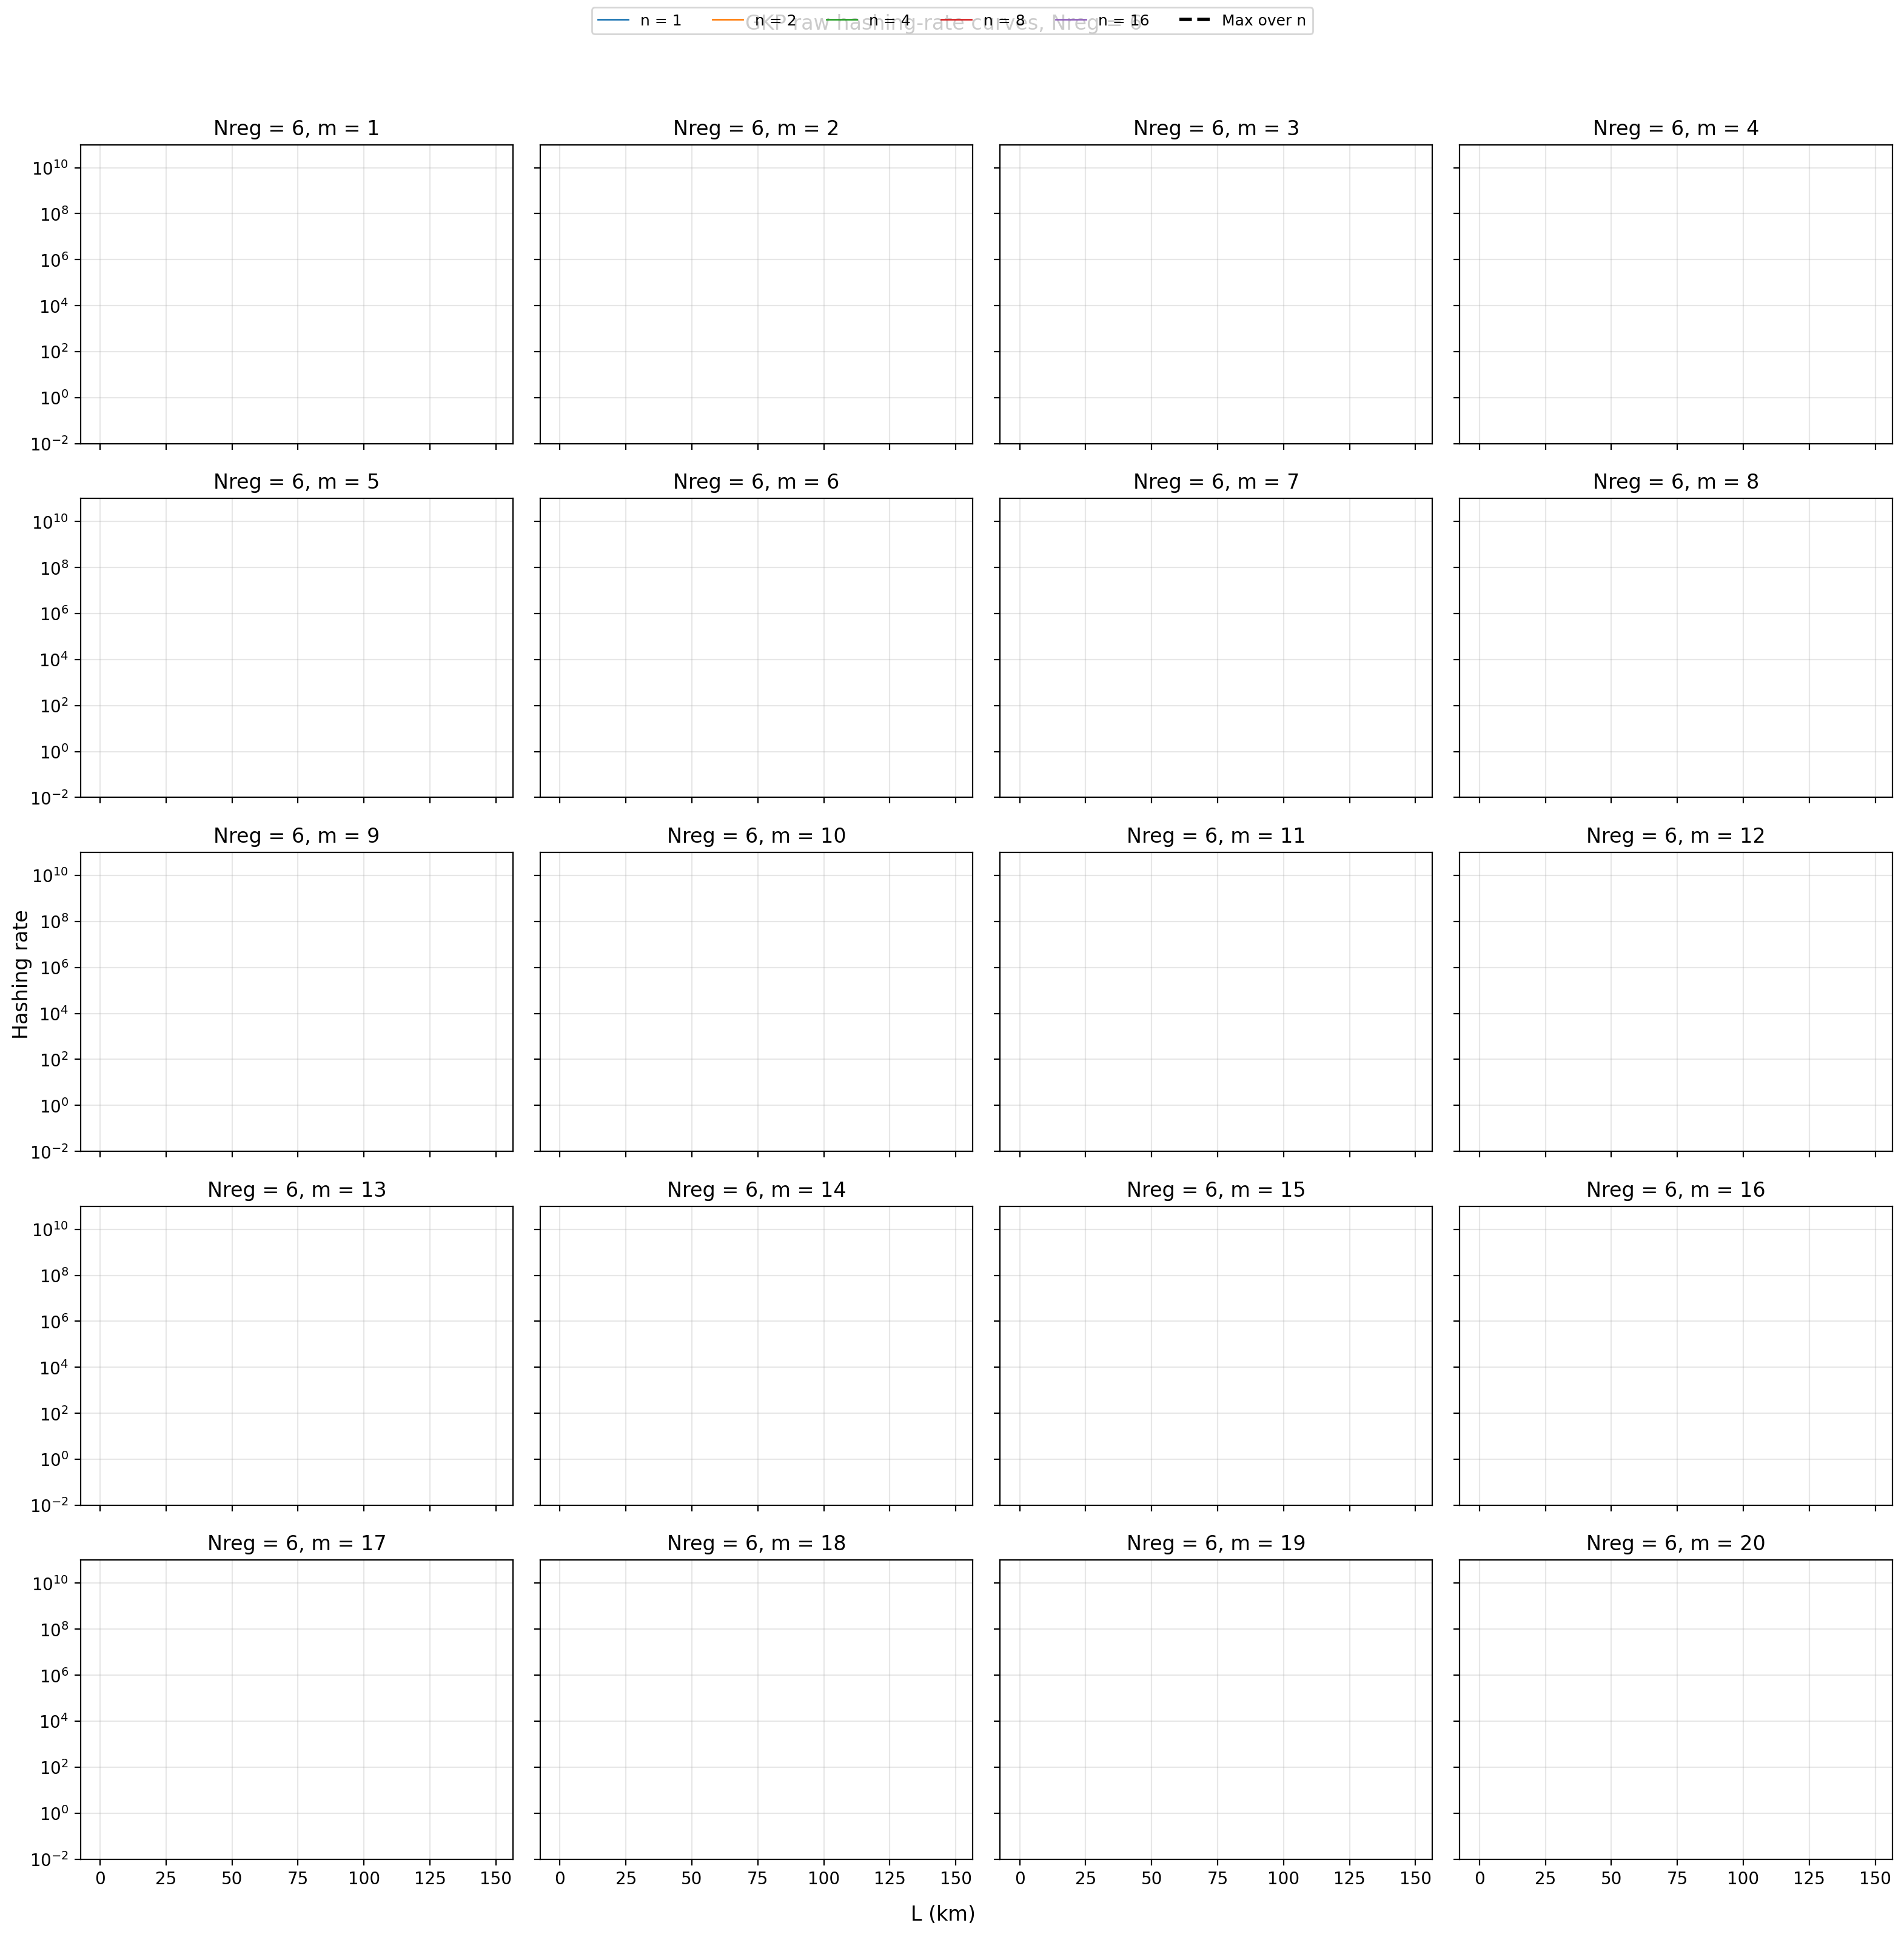


Plotting all available m-plots for Nreg = 7


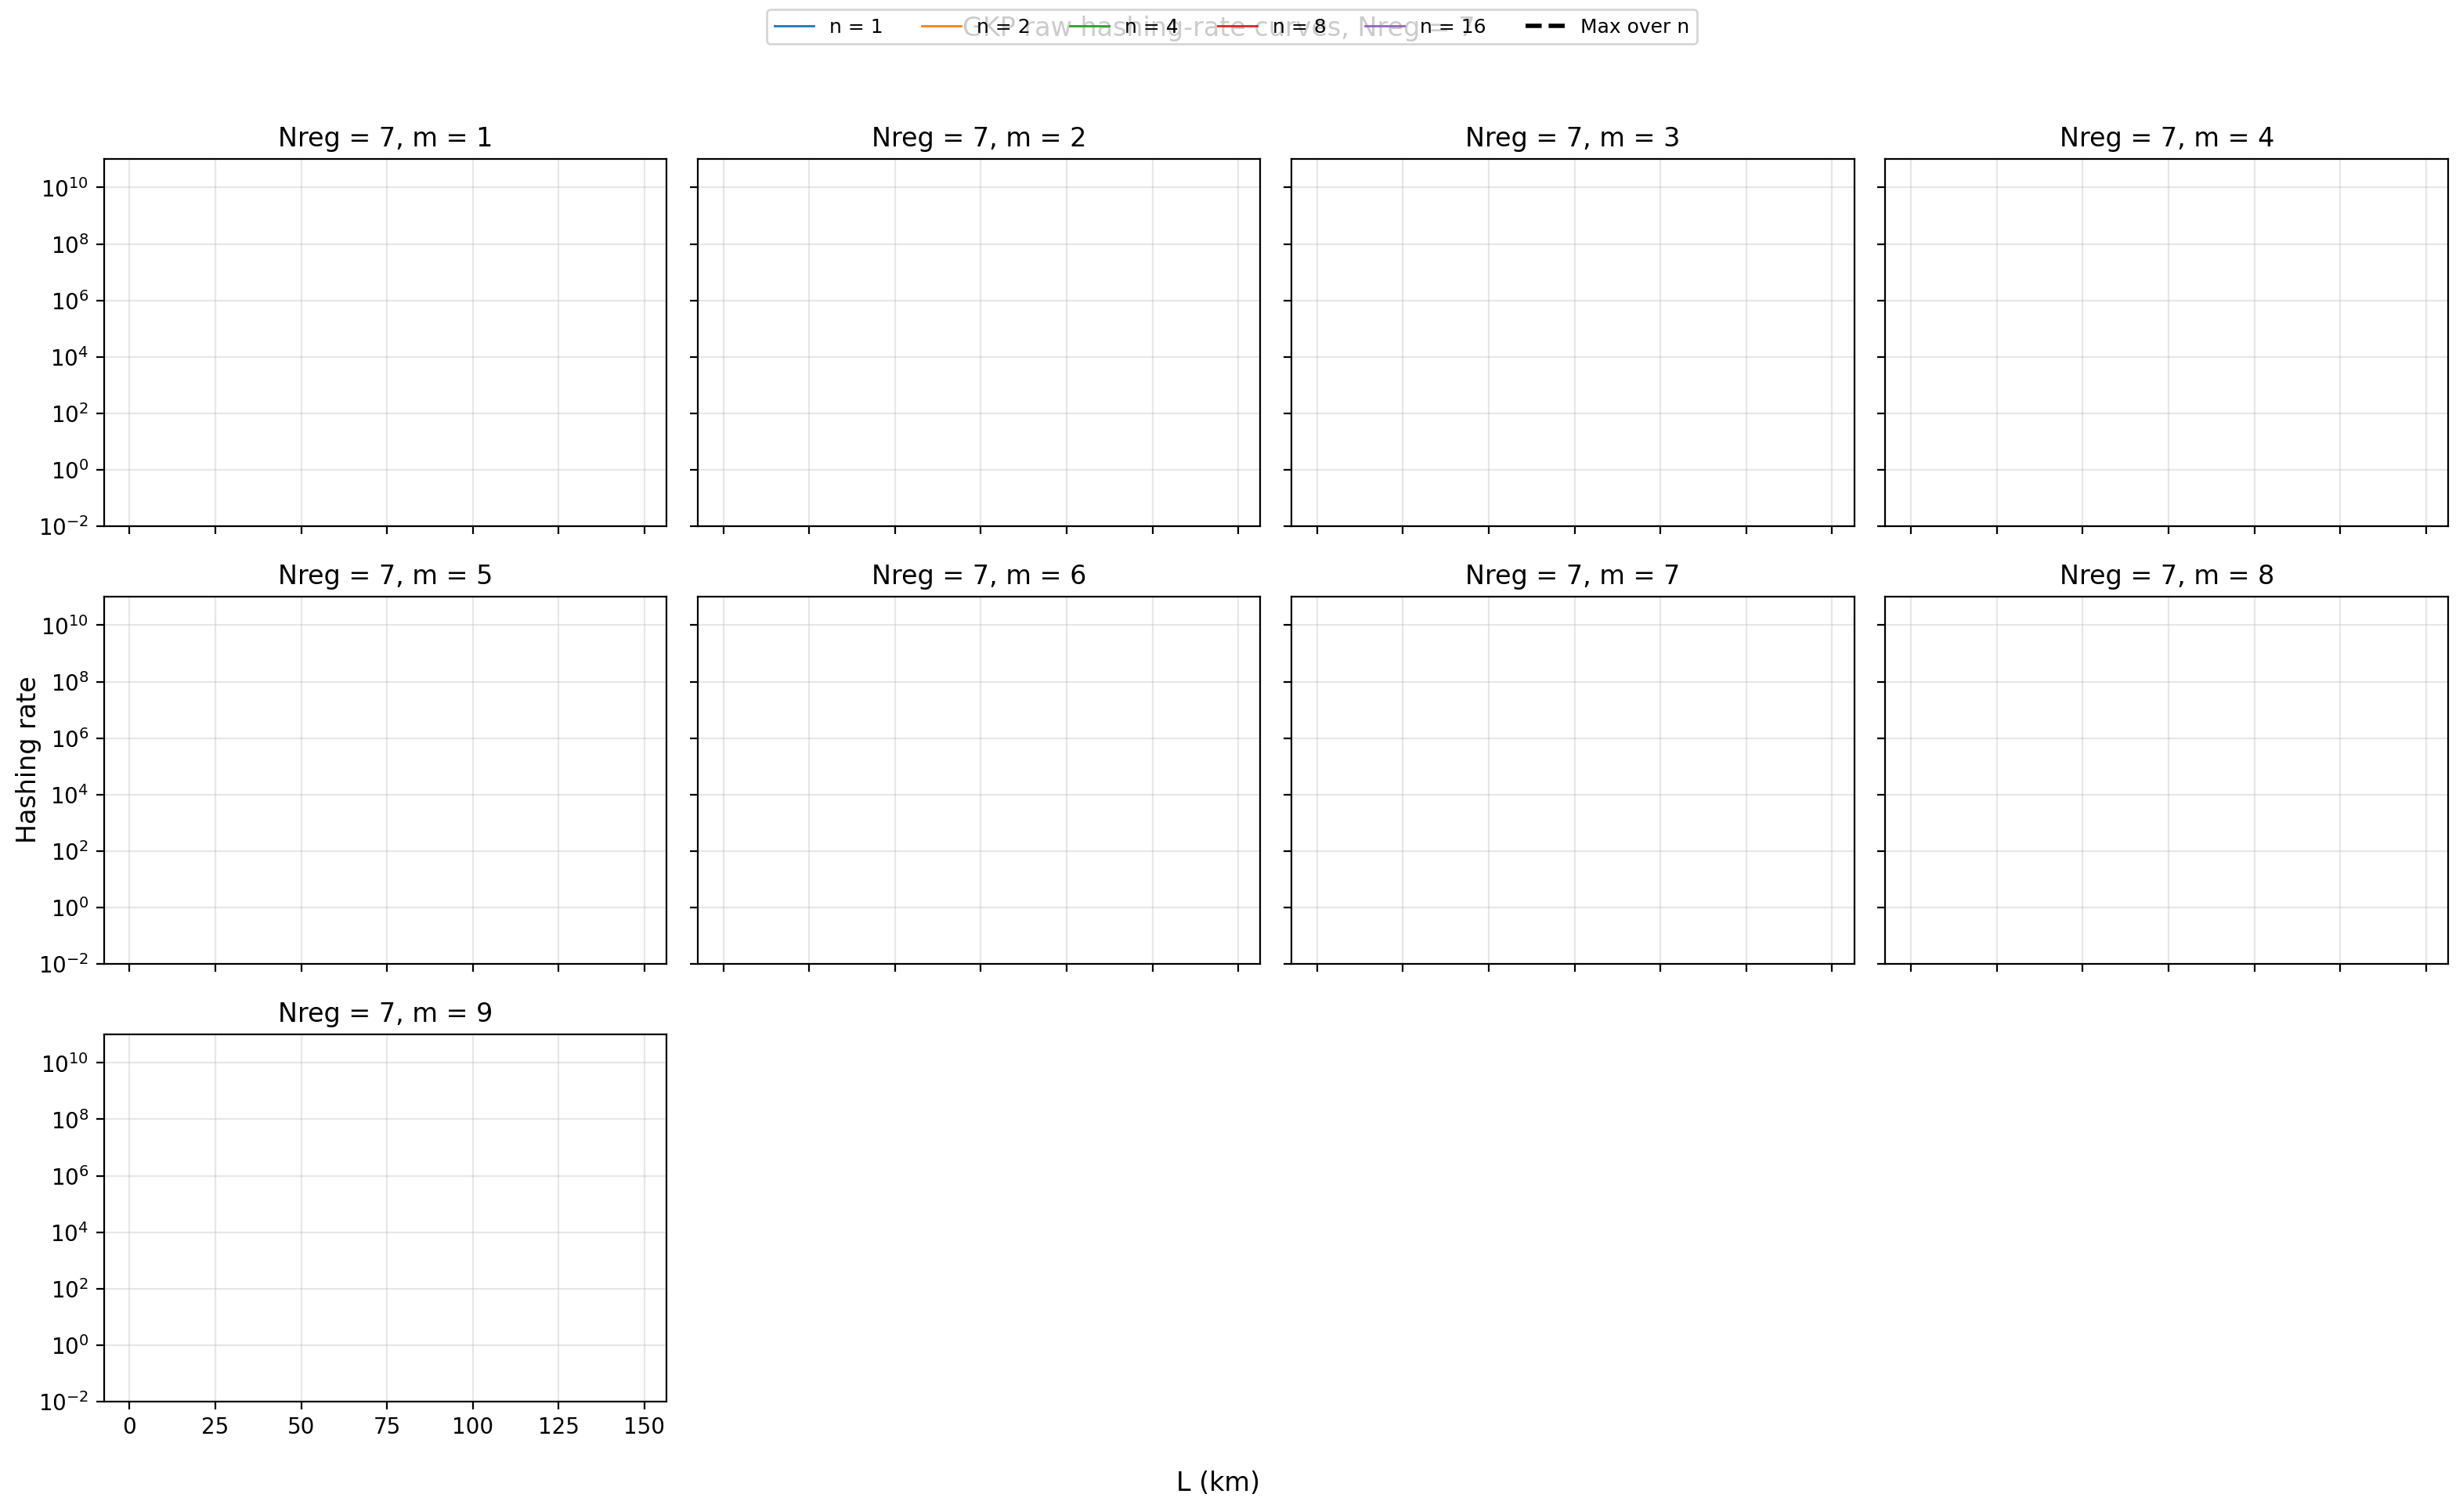


Plotting all available m-plots for Nreg = 8


KeyError: 8

In [15]:
for Nreg in Nreg_values:

    print(f"\nPlotting all available m-plots for Nreg = {Nreg}")

    available_m = sorted(all_results[Nreg].keys())

    nplots = len(available_m)
    ncols = 4
    nrows = int(np.ceil(nplots / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4 * ncols, 3.2 * nrows),
        dpi=200,
        sharex=True,
        sharey=True,
    )

    axes = np.asarray(axes).reshape(-1)

    for idx, m in enumerate(available_m):

        ax = axes[idx]
        out = all_results[Nreg][m]

        fixed_n_curves = []

        for n in n_vals:

            curve = out["fixed_n_data"][n]["rate"]
            fixed_n_curves.append(curve)

            ax.plot(
                out["Ls"],
                curve,
                label=f"n = {n}",
                linewidth=1.0
            )

        fixed_n_curves = np.vstack(fixed_n_curves)

        maximisation_over_n_for_fixed_m = np.max(
            fixed_n_curves,
            axis=0
        )

        ax.plot(
            out["Ls"],
            maximisation_over_n_for_fixed_m,
            color="black",
            linestyle="--",
            linewidth=2,
            label="Max over n"
        )

        ax.set_yscale("log")
        ax.set_ylim(1e-2, 1e11)
        ax.set_title(f"Nreg = {Nreg}, m = {m}")
        ax.grid(True, which="both", alpha=0.3)

    # Turn off unused axes
    for j in range(nplots, len(axes)):
        axes[j].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(n_vals) + 1,
        fontsize=9
    )

    fig.suptitle(
        f"GKP raw hashing-rate curves, Nreg = {Nreg}",
        y=0.995
    )

    fig.supxlabel("L (km)")
    fig.supylabel("Hashing rate")

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    fig_path = os.path.join(
        output_dir,
        f"gkp_raw_curves_with_envelope_Nreg_{Nreg}.png"
    )

    plt.savefig(
        fig_path,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

print("\nDone.")


Plotting max-over-n curves for Nreg = 1


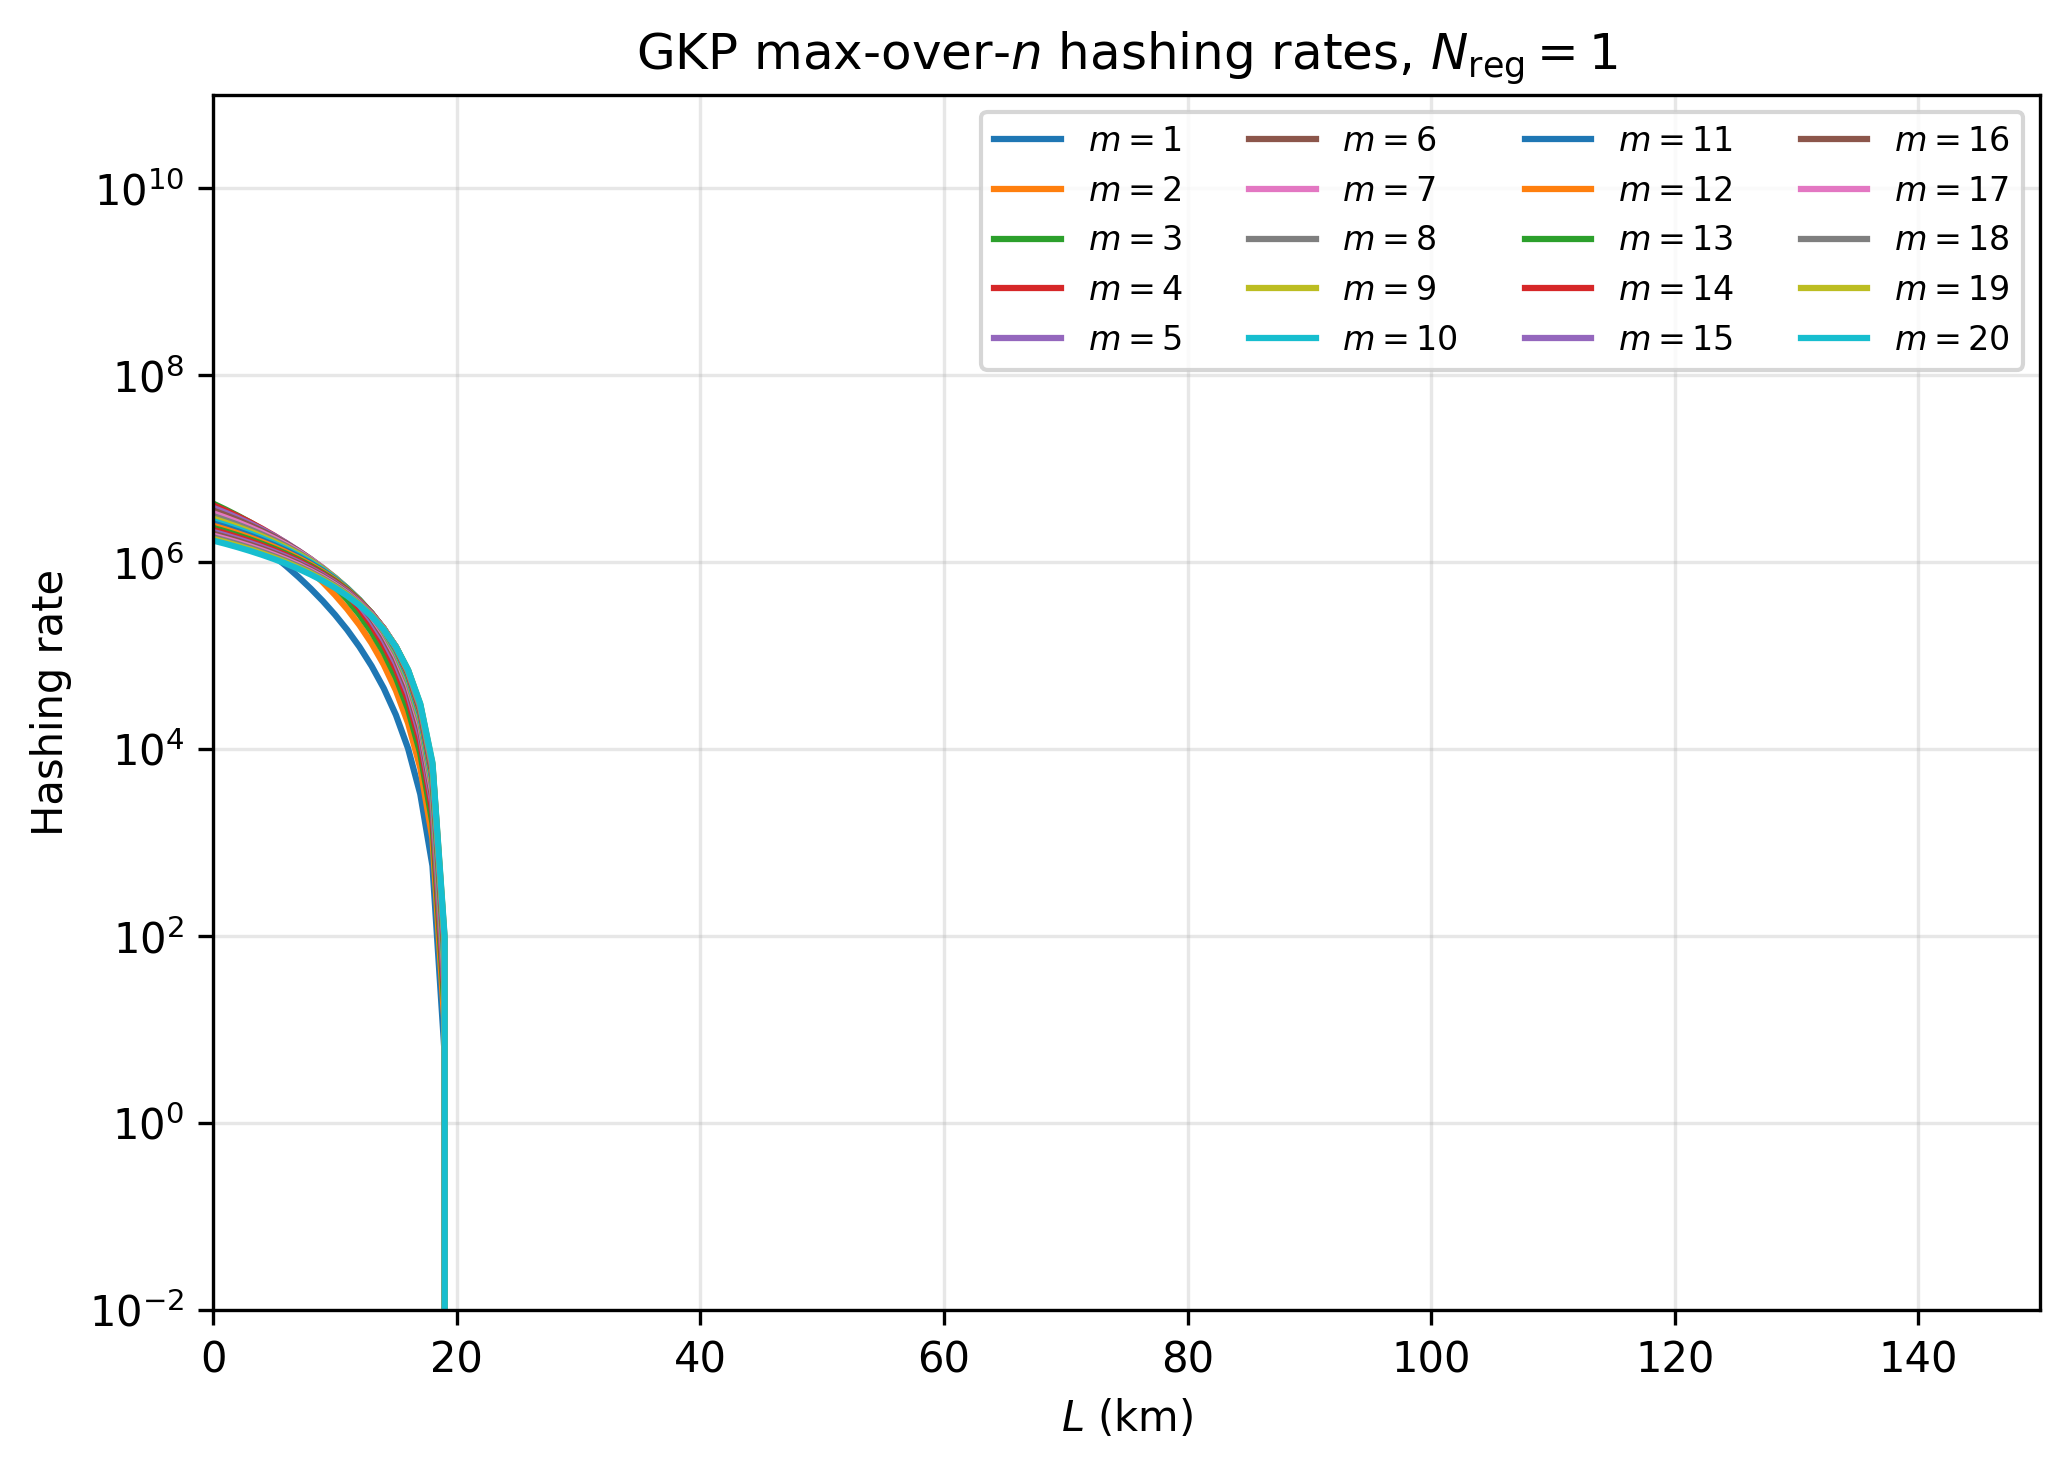


Plotting max-over-n curves for Nreg = 2


/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_9096/2814269702.py:60: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")


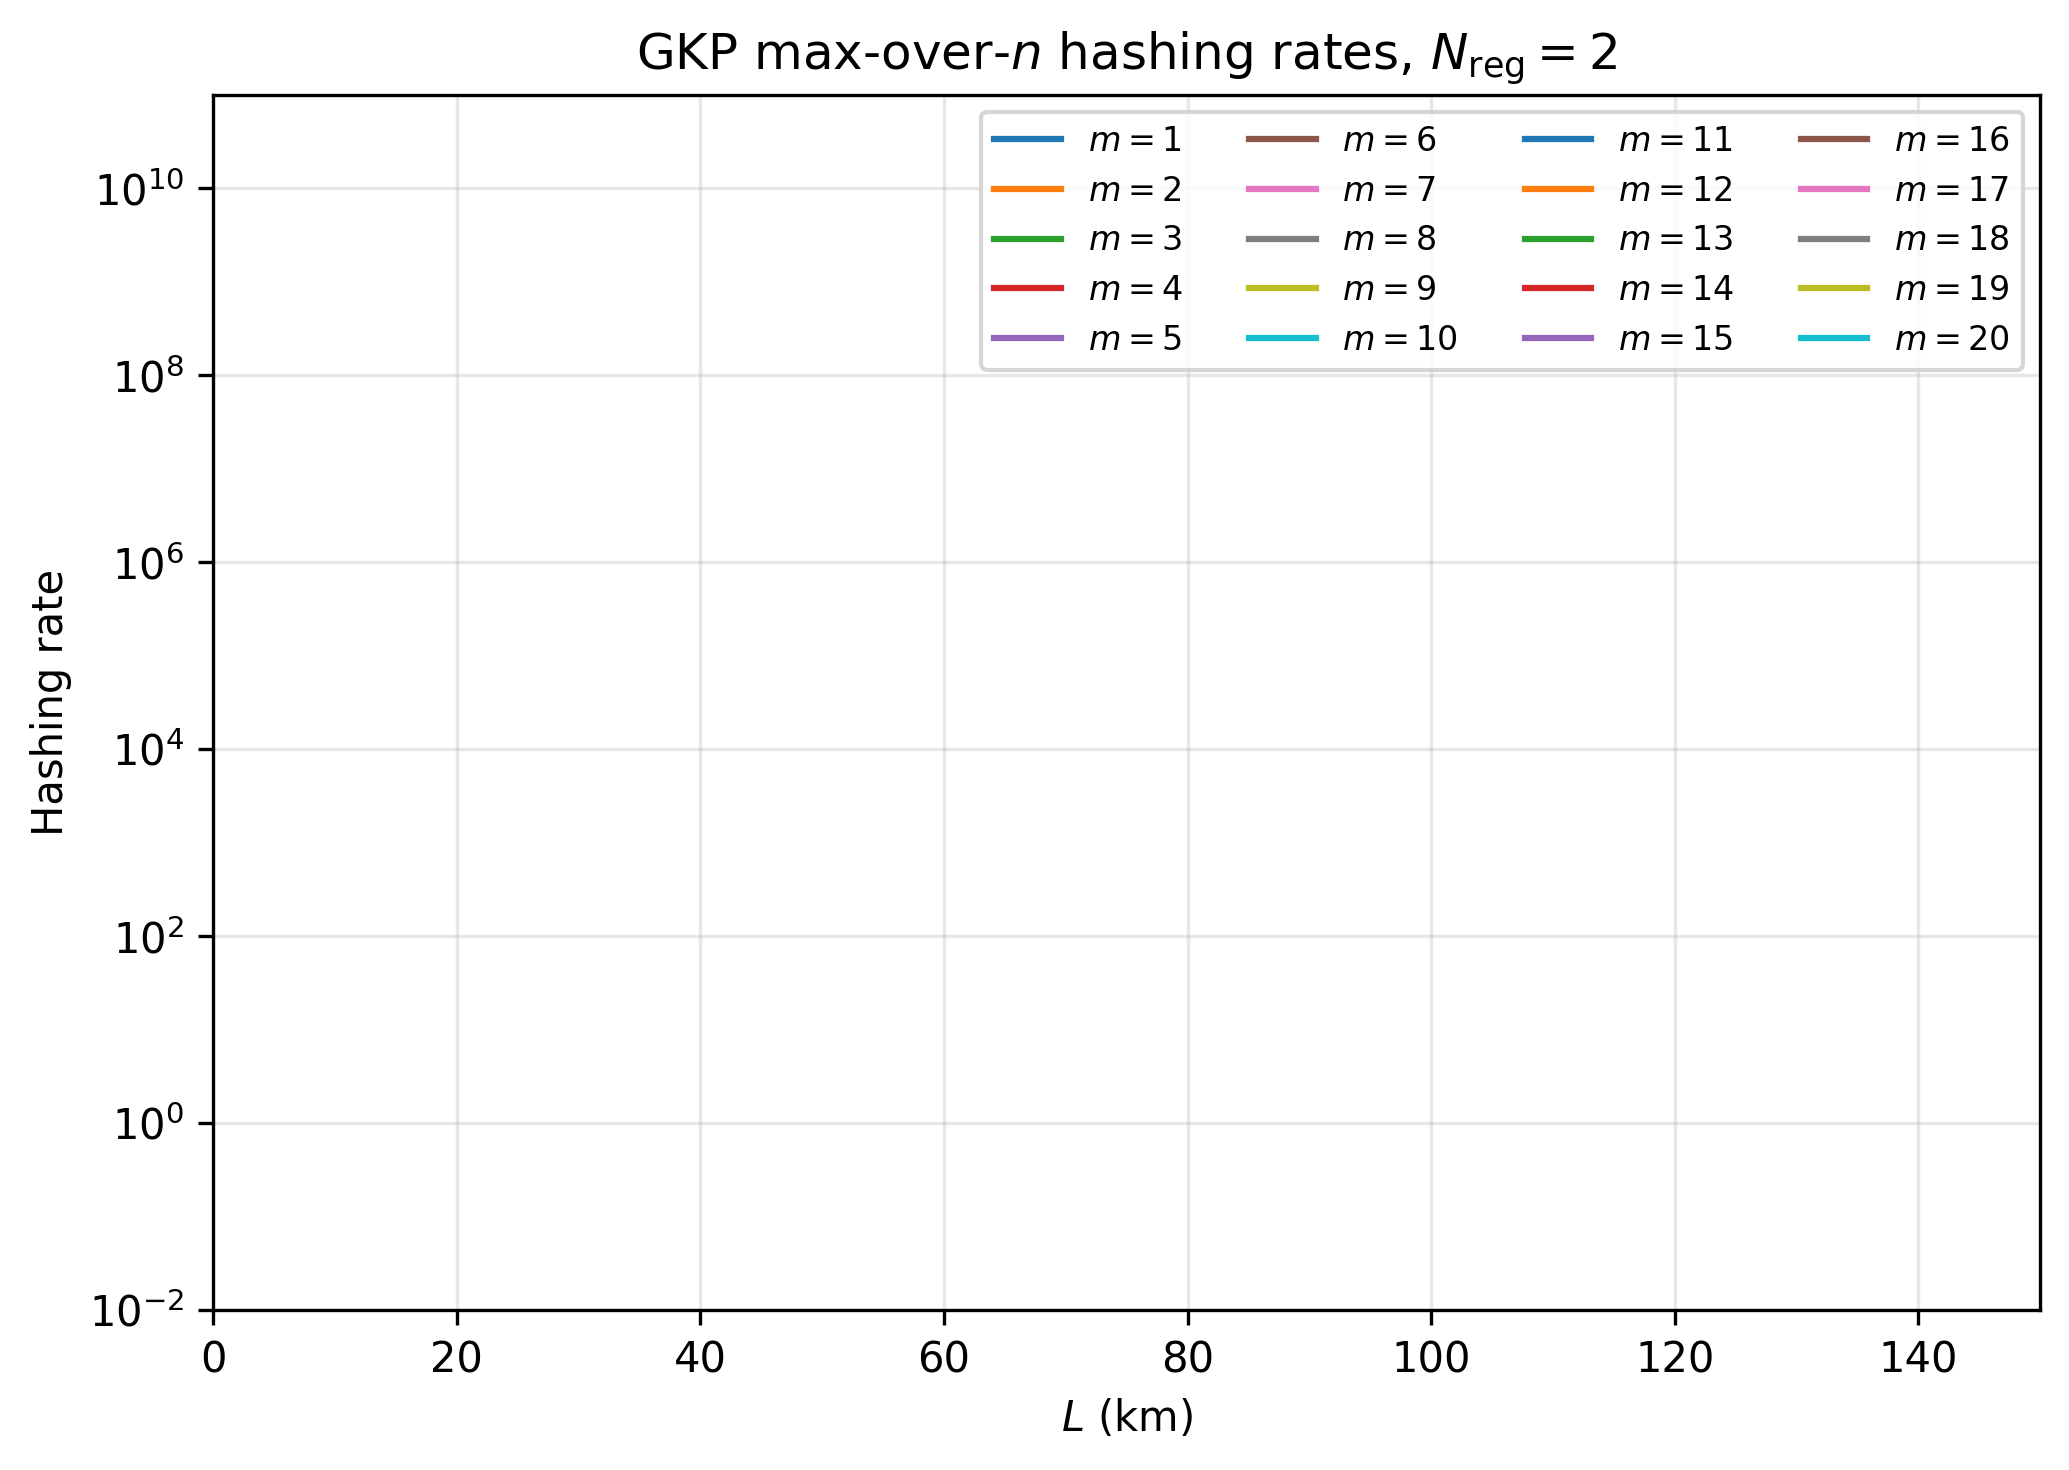


Plotting max-over-n curves for Nreg = 3


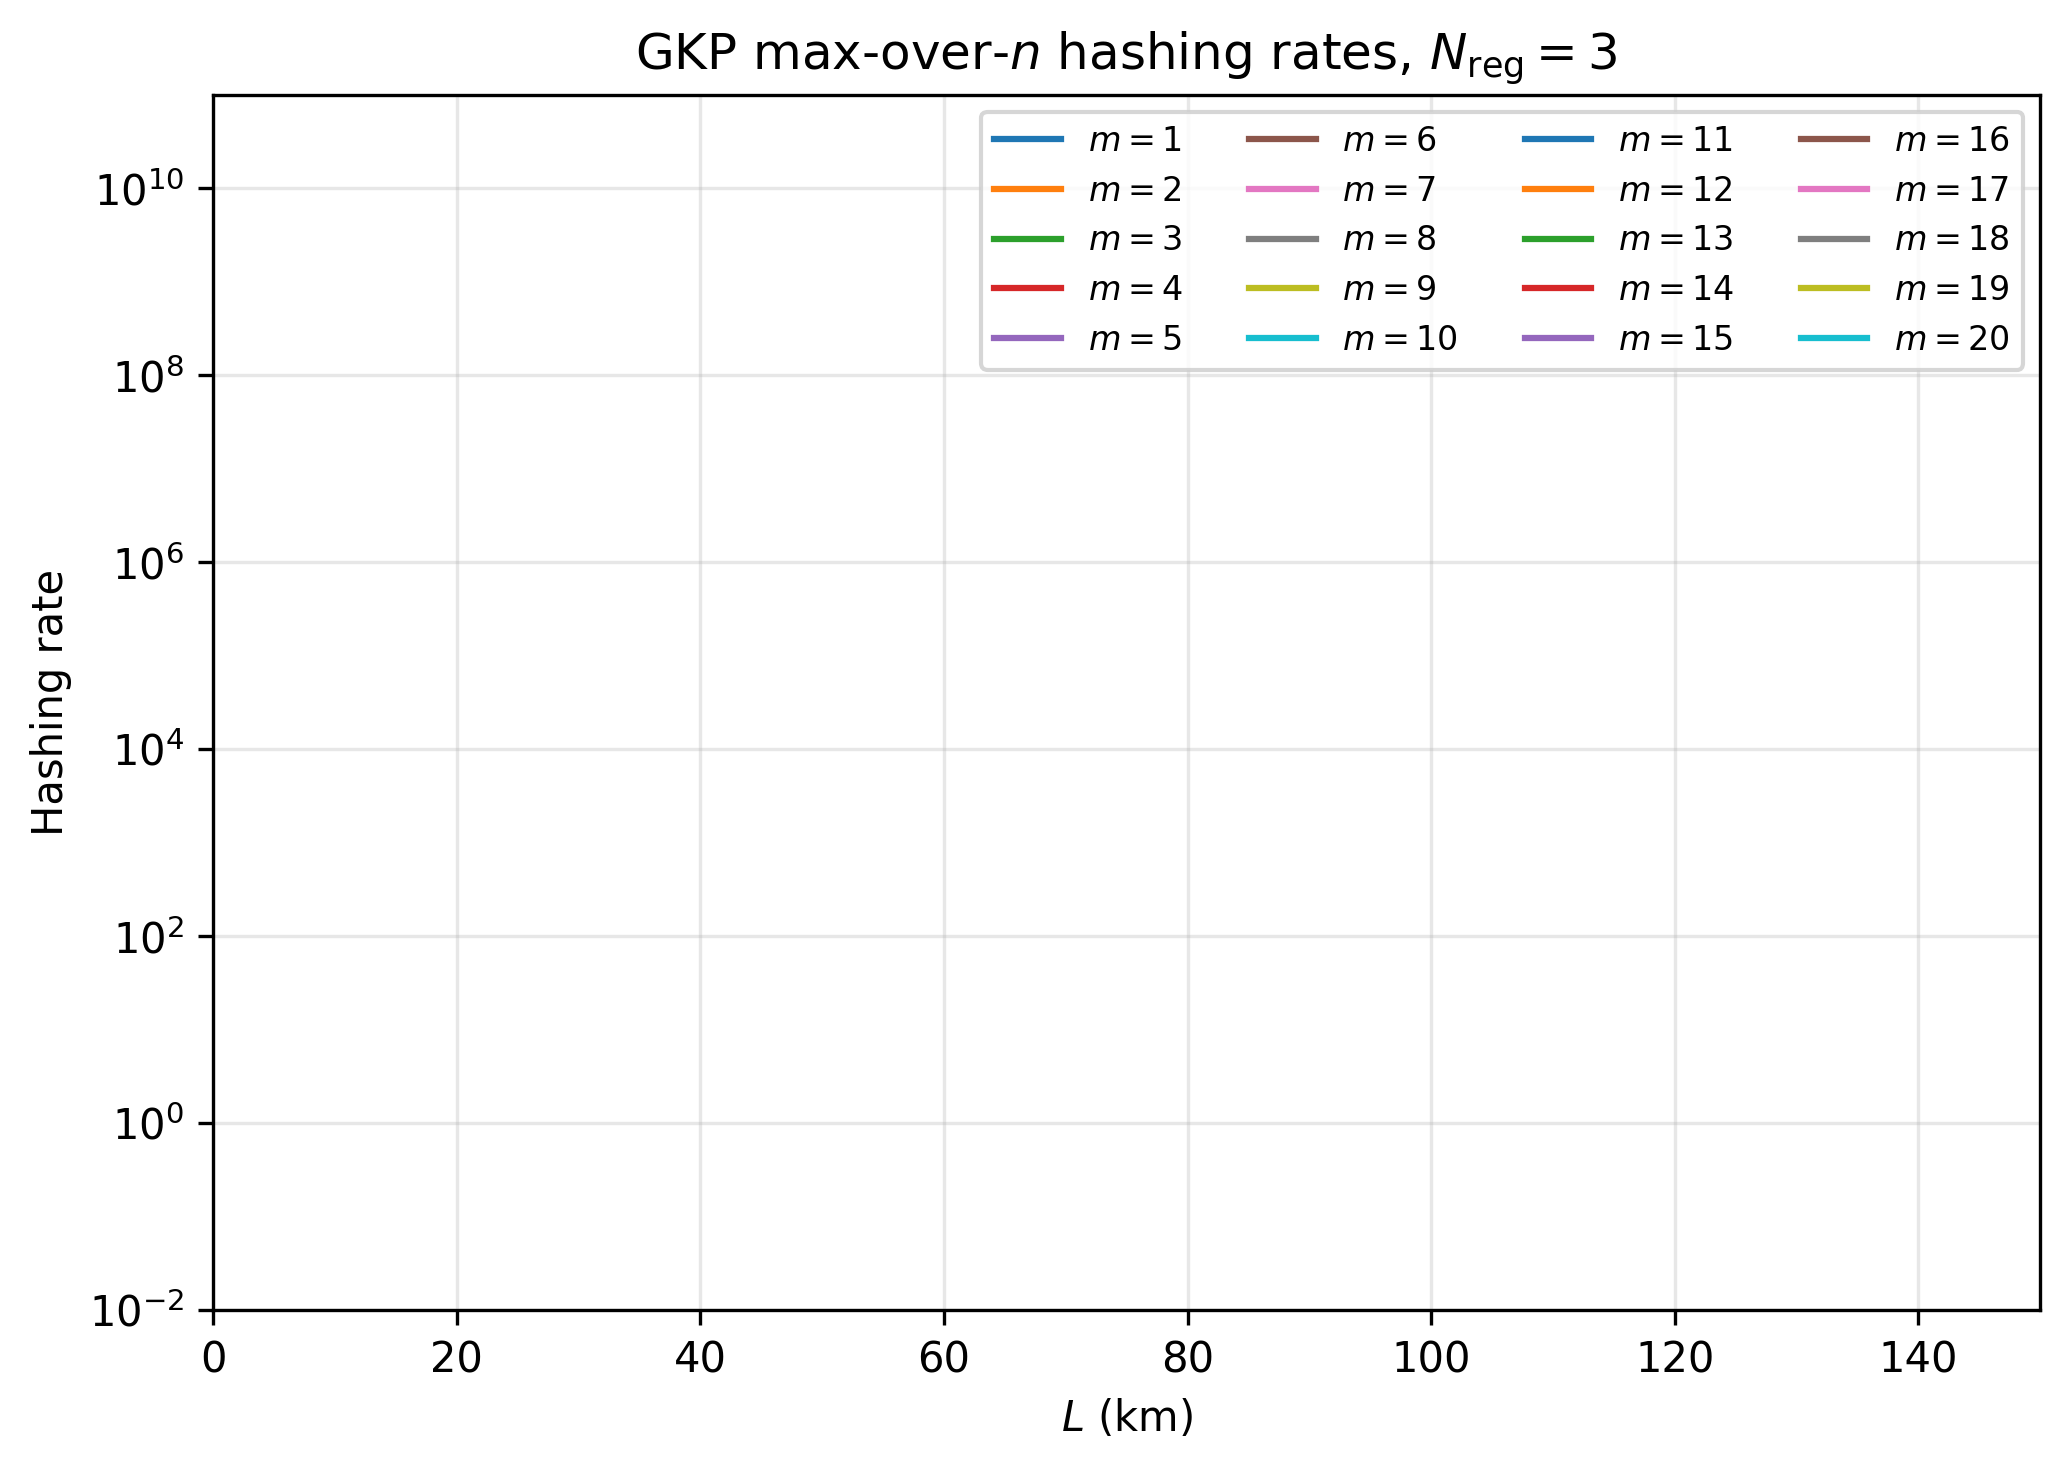


Plotting max-over-n curves for Nreg = 4


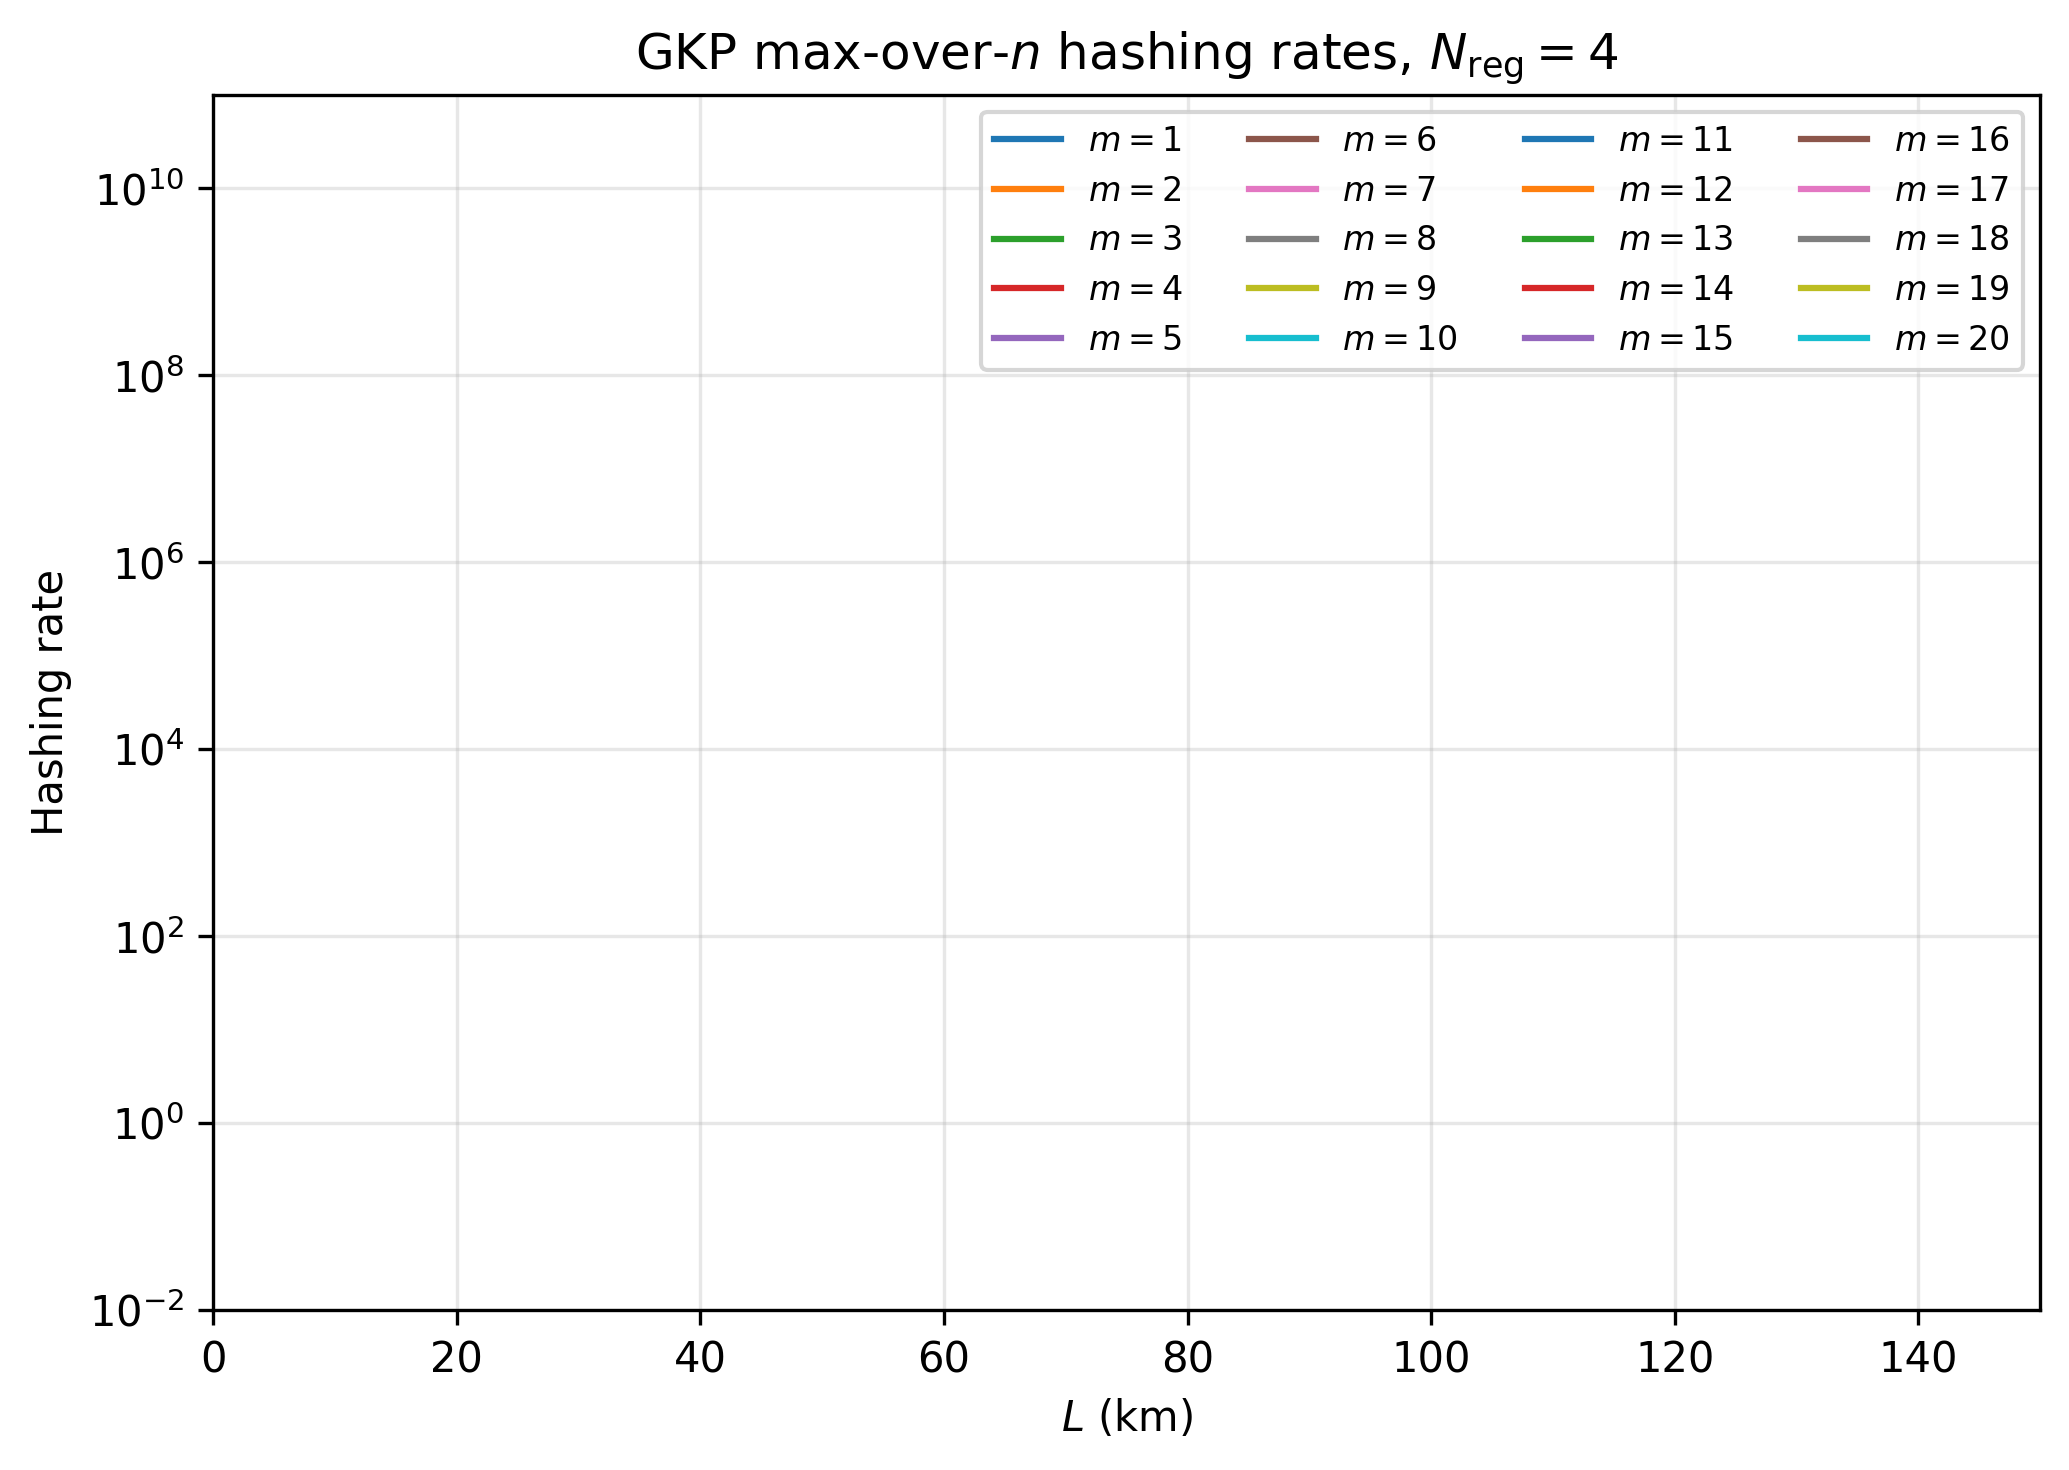


Plotting max-over-n curves for Nreg = 5


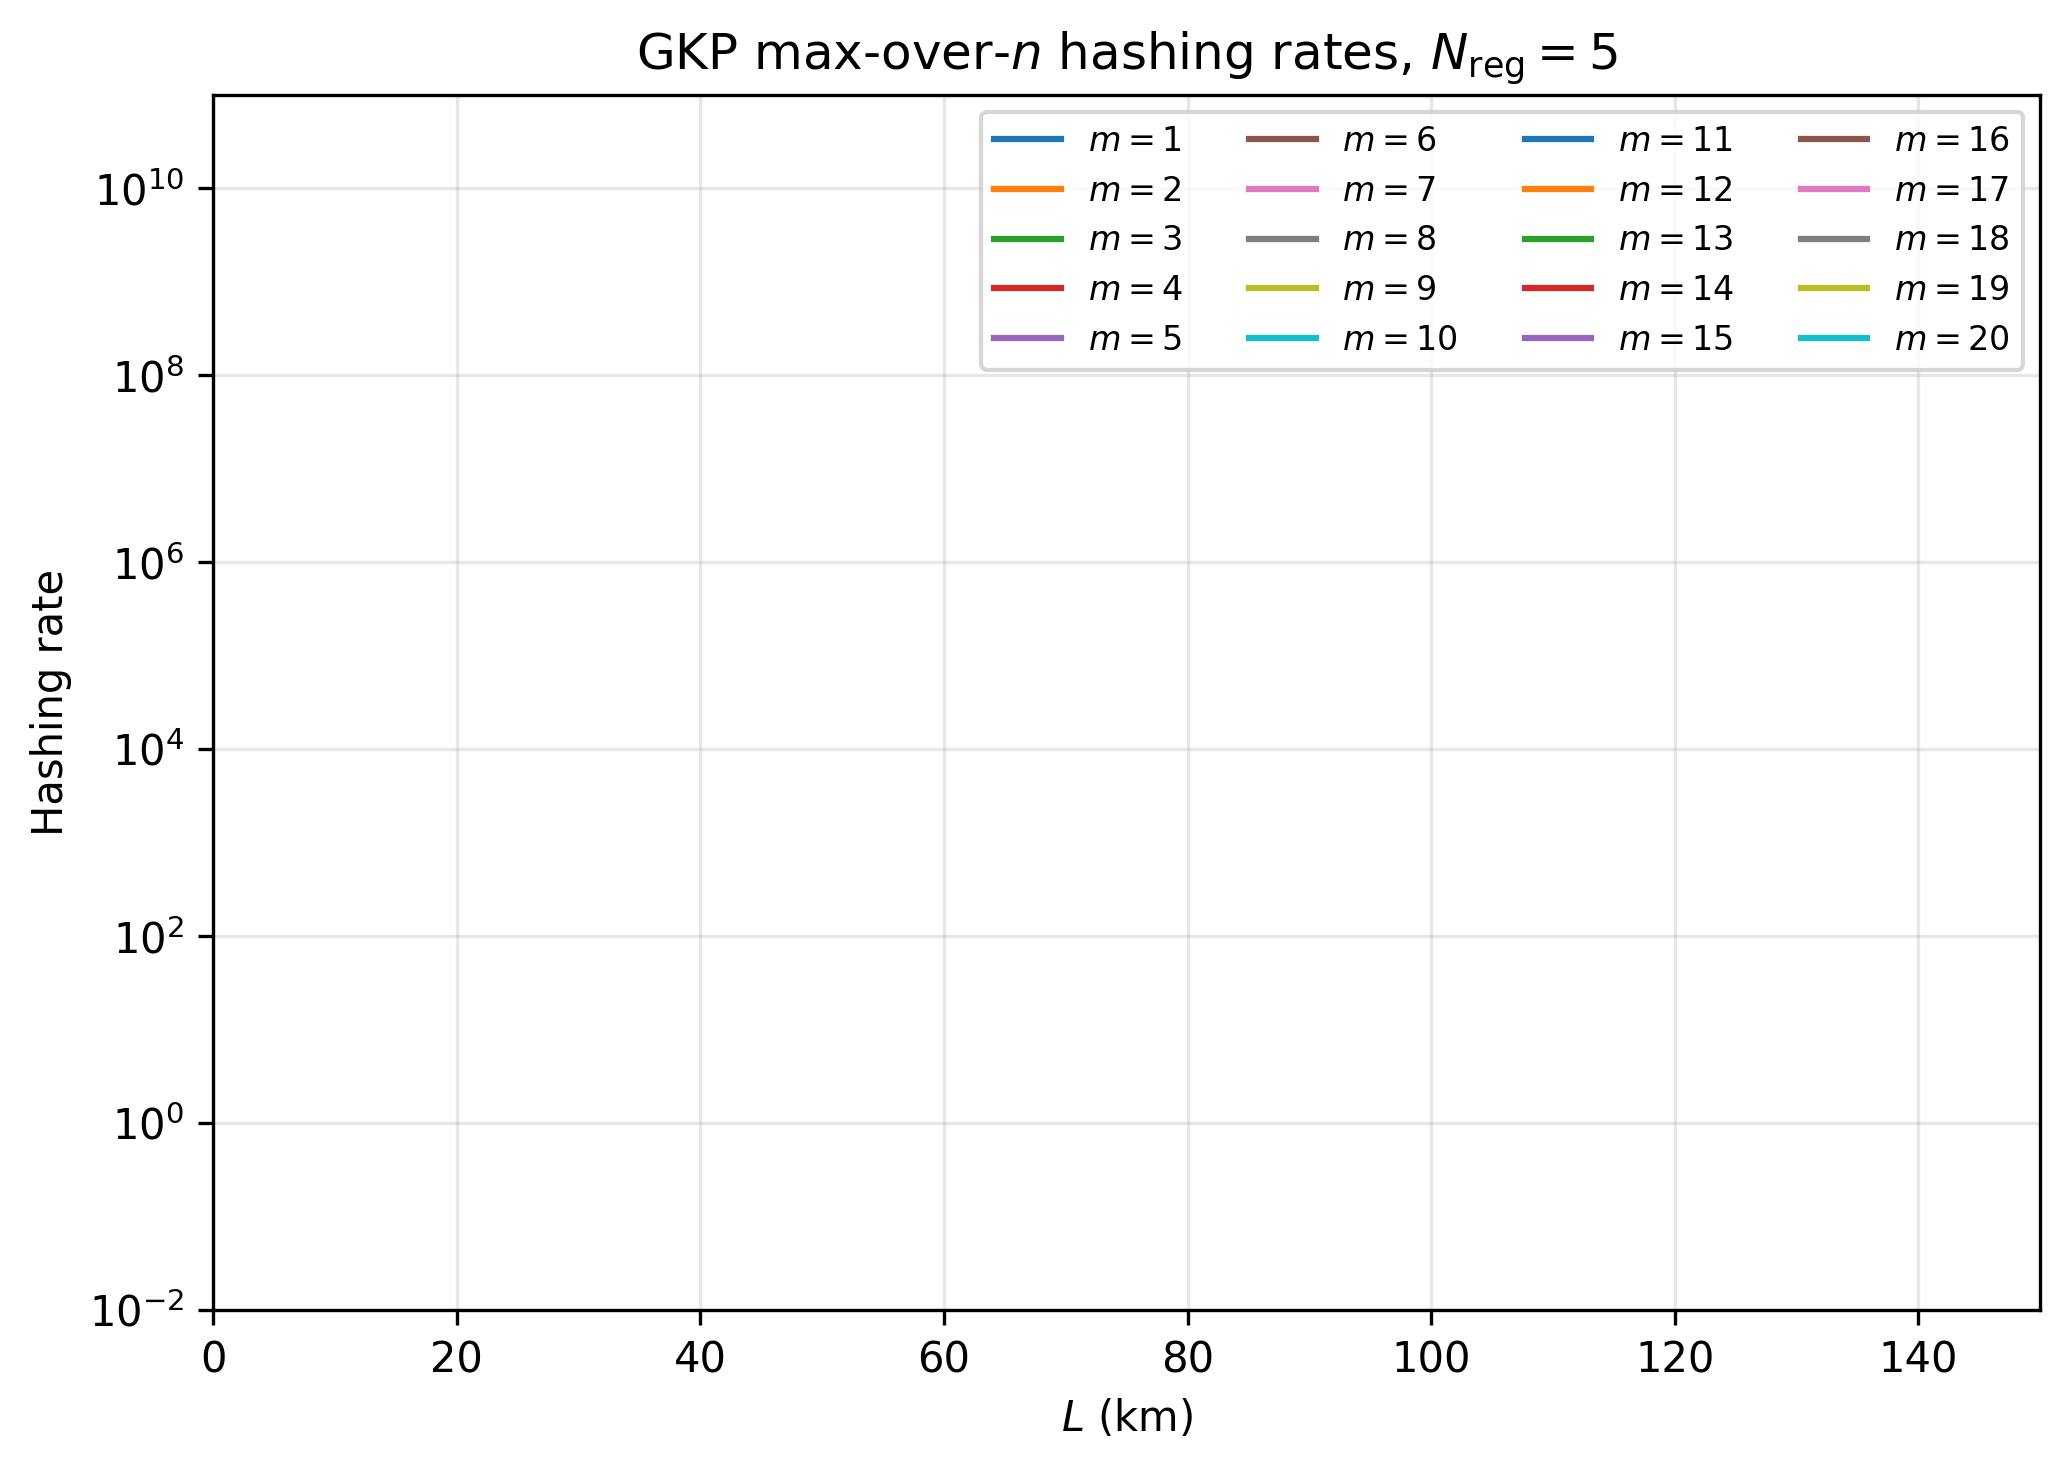


Plotting max-over-n curves for Nreg = 6


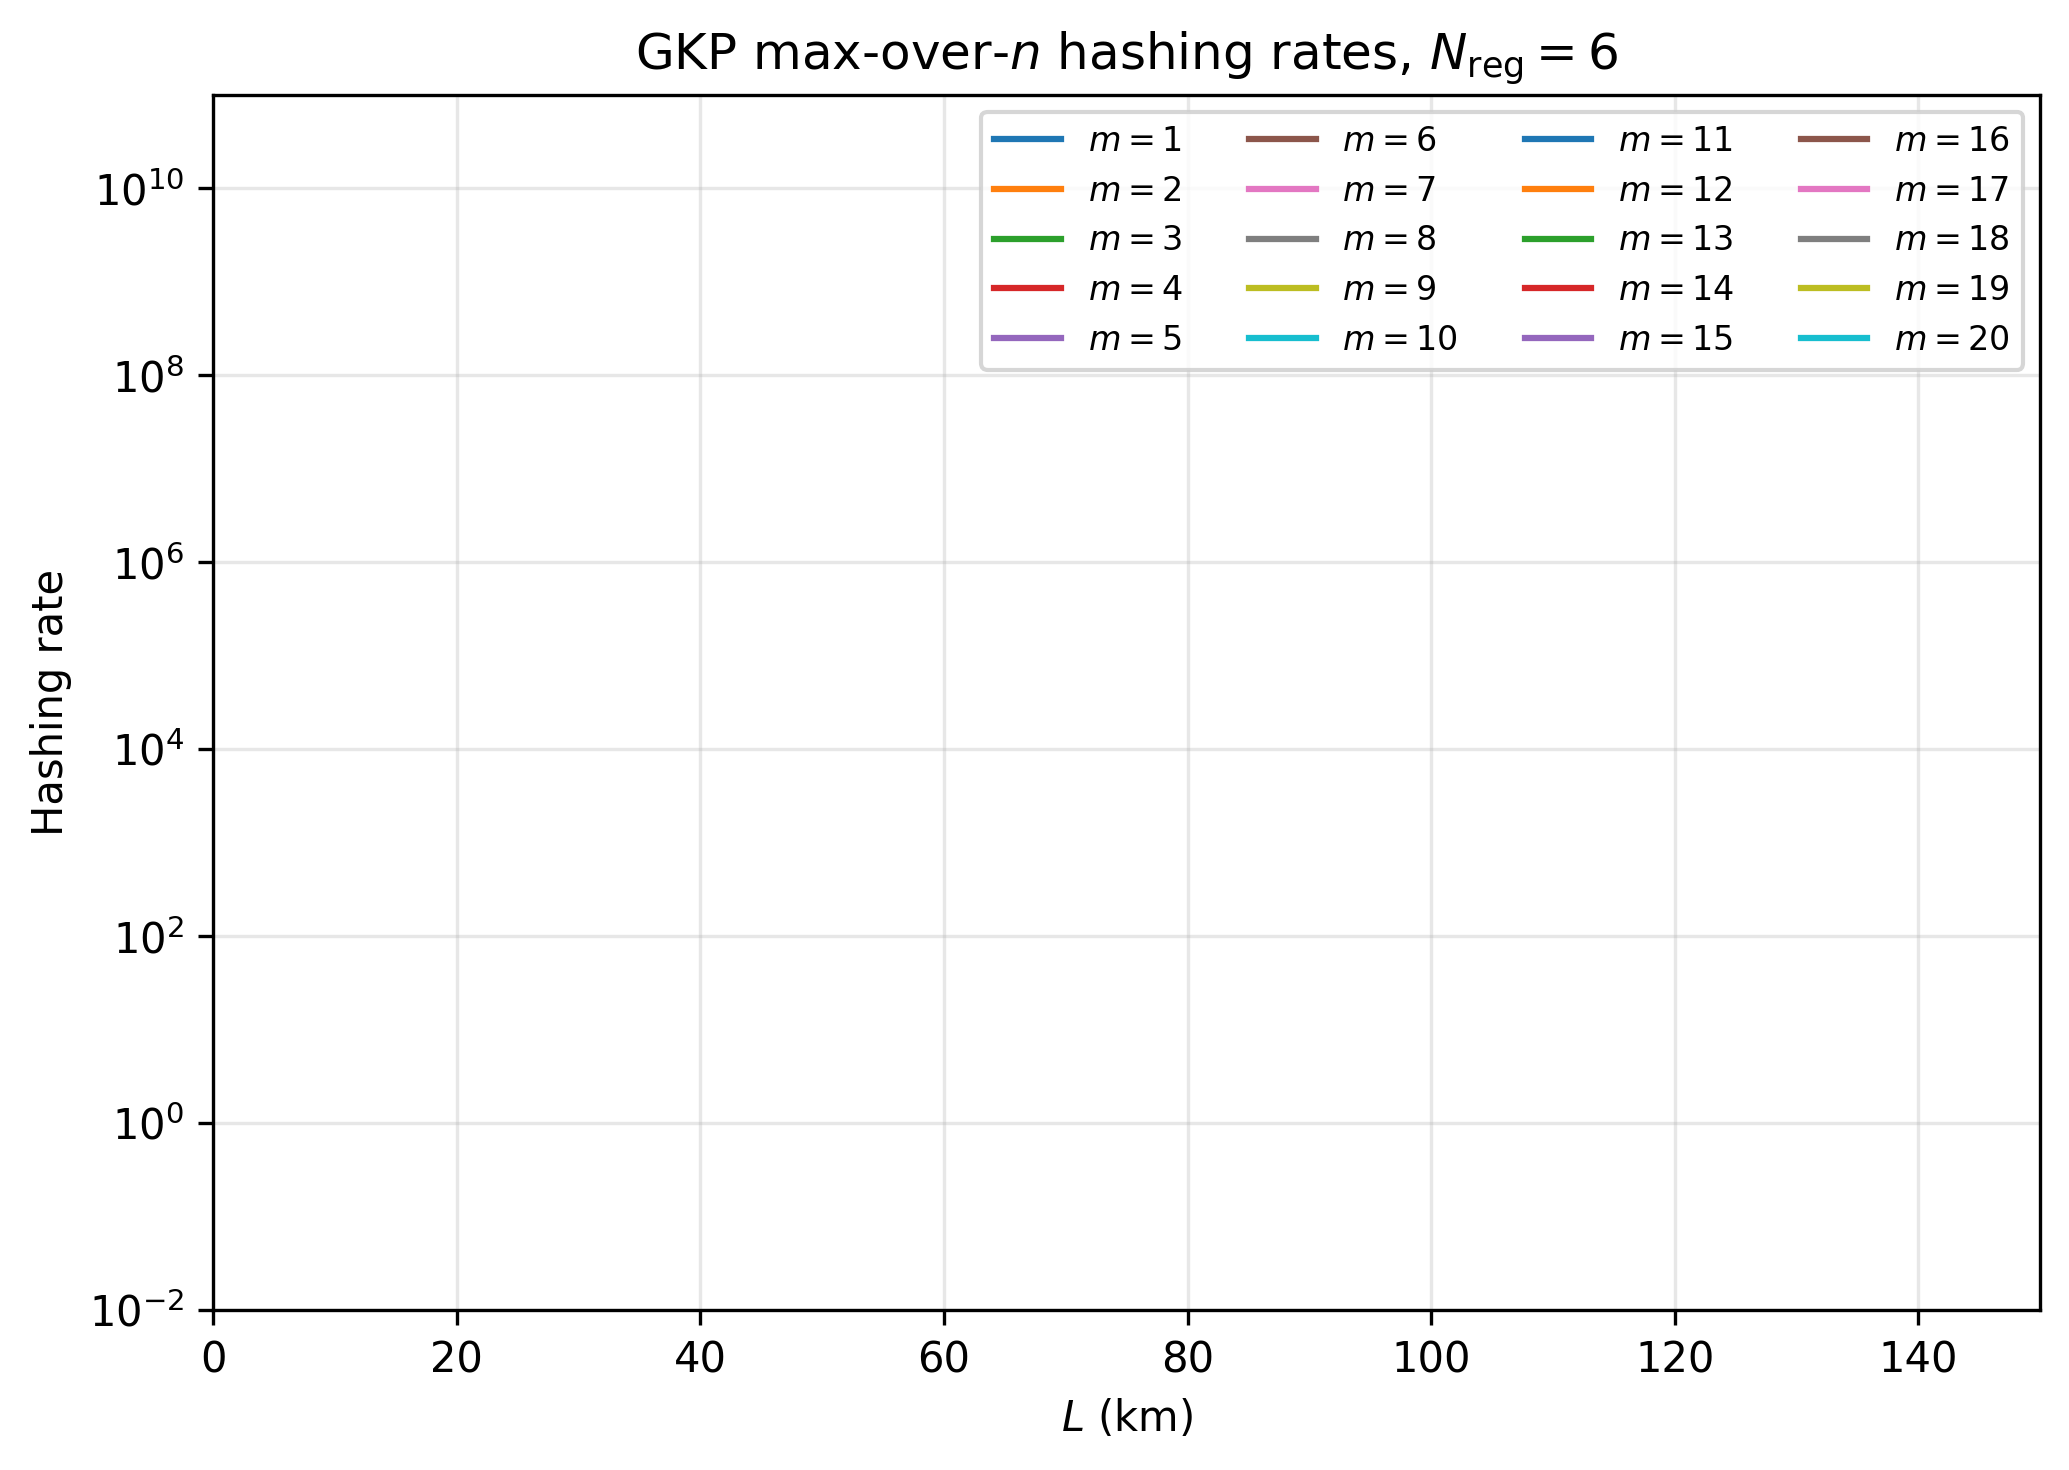


Plotting max-over-n curves for Nreg = 7


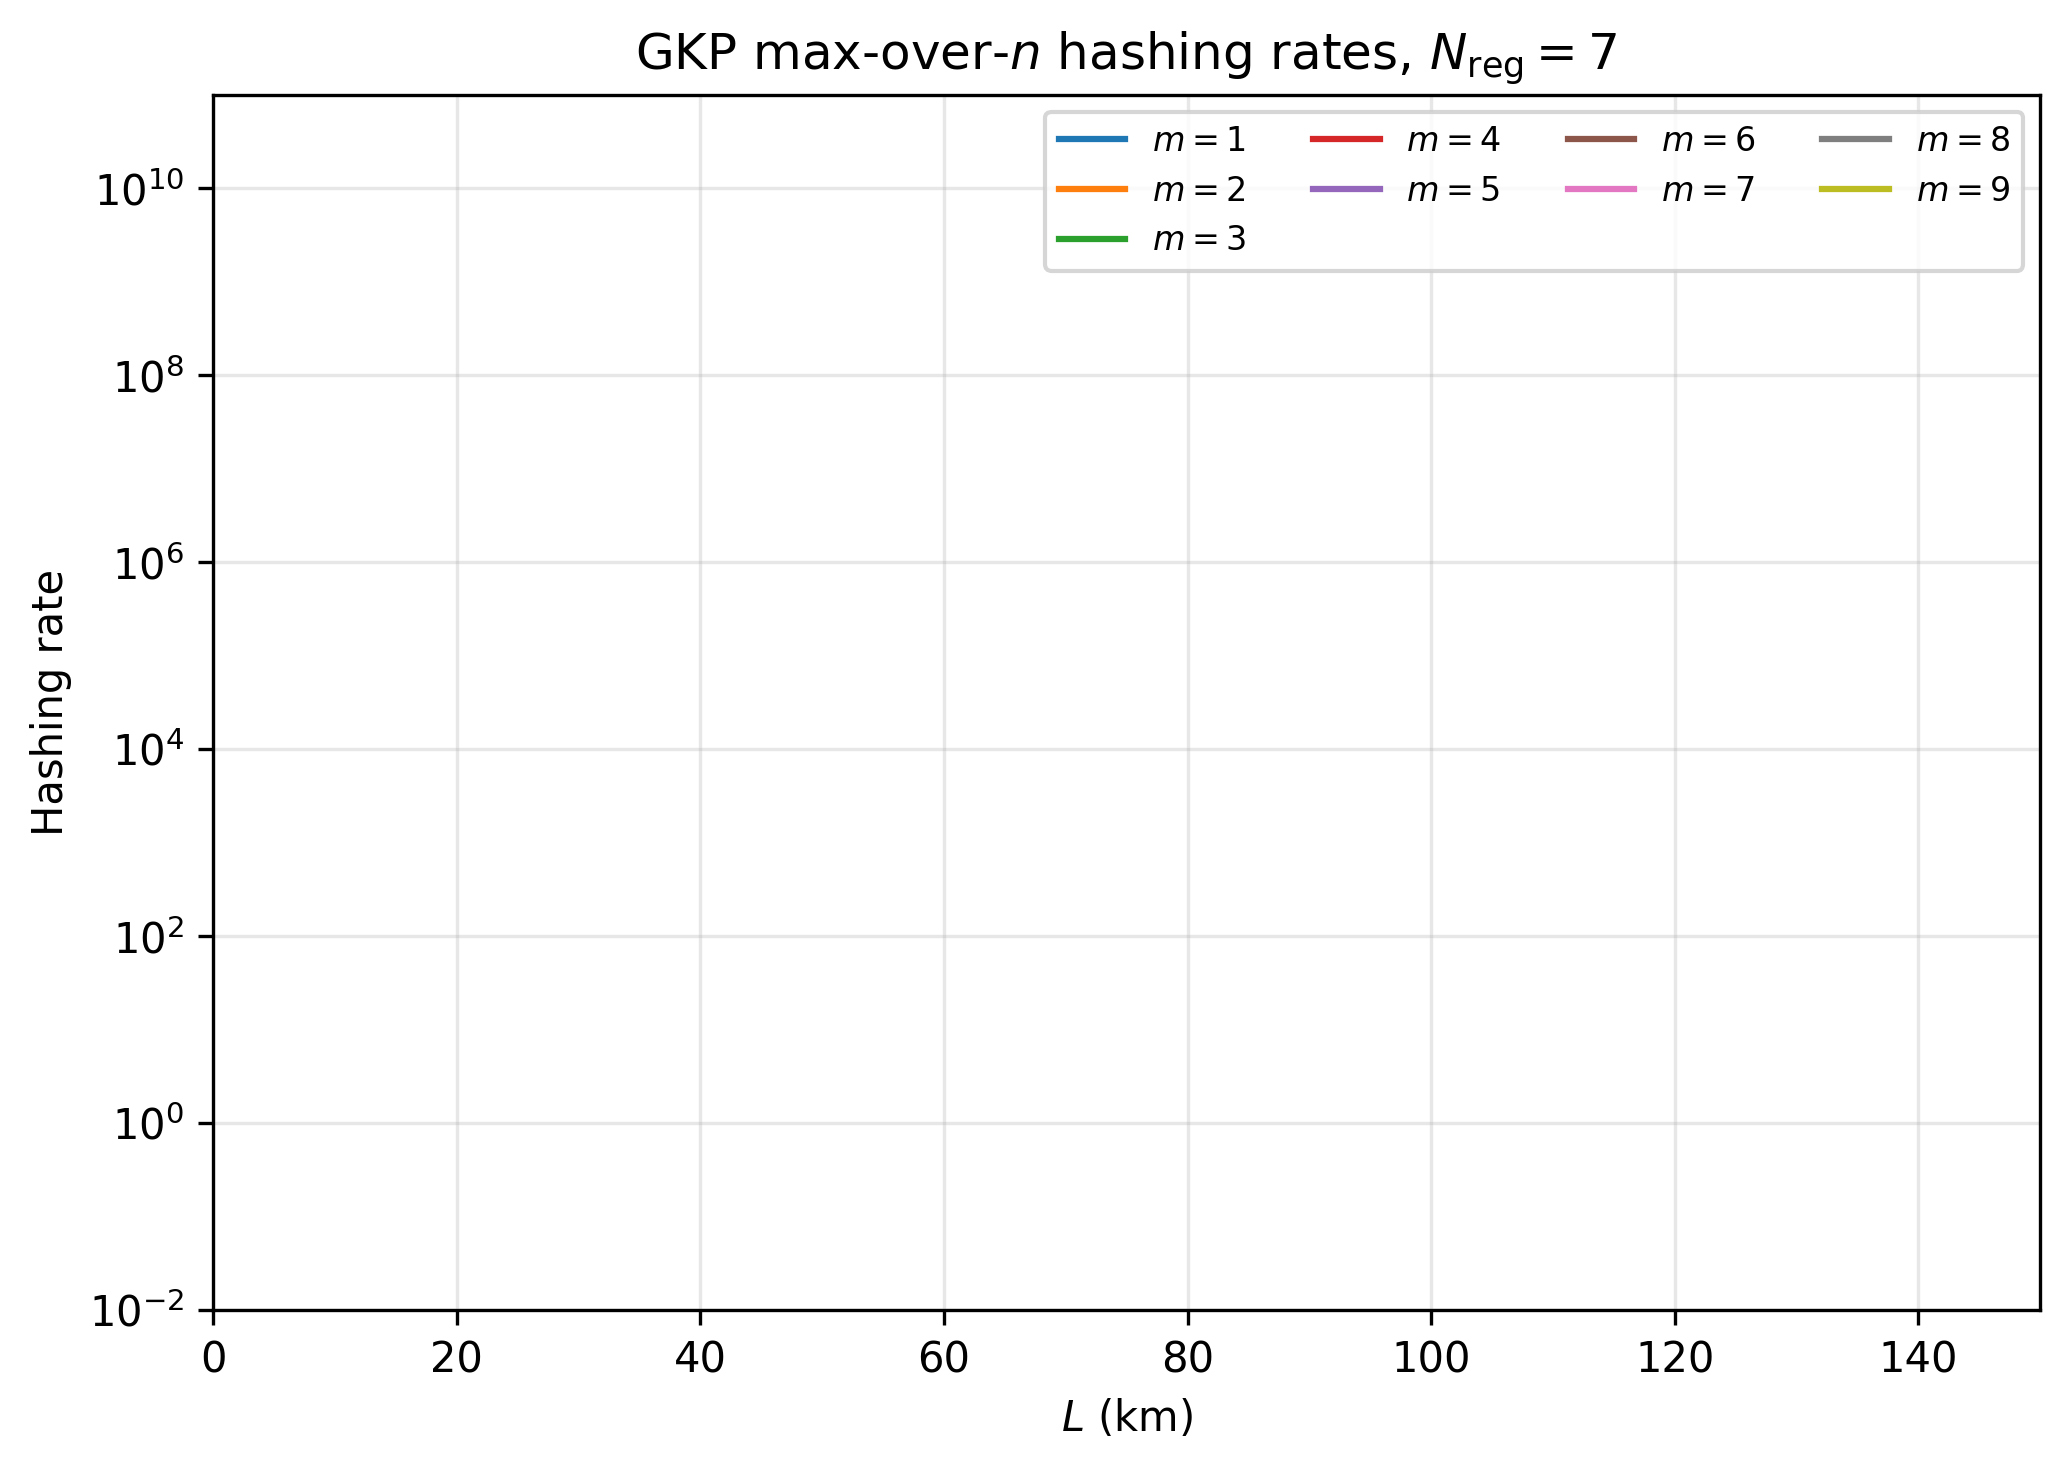


Plotting max-over-n curves for Nreg = 8


KeyError: 8

In [16]:
# ============================================================
# Plot max-over-n hashing-rate curves for all m
# for each fixed Nreg
# ============================================================

for Nreg in Nreg_values:

    print(f"\nPlotting max-over-n curves for Nreg = {Nreg}")

    available_m = sorted(all_results[Nreg].keys())

    fig, ax = plt.subplots(
        figsize=(7, 5),
        dpi=300
    )

    for m in available_m:

        out = all_results[Nreg][m]

        # --------------------------------------------
        # Collect the fixed-n curves
        # --------------------------------------------

        fixed_n_curves = []

        for n in n_vals:
            curve = np.asarray(
                out["fixed_n_data"][n]["rate"],
                dtype=float
            )
            fixed_n_curves.append(curve)

        # --------------------------------------------
        # Maximum over n for this fixed m
        # --------------------------------------------

        fixed_n_curves = np.vstack(fixed_n_curves)

        max_over_n = np.max(
            fixed_n_curves,
            axis=0
        )

        # --------------------------------------------
        # Plot this m curve
        # --------------------------------------------

        ax.plot(
            out["Ls"],
            max_over_n,
            linewidth=1.5,
            label=f"$m={m}$"
        )

    # --------------------------------------------
    # Formatting
    # --------------------------------------------

    ax.set_yscale("log")

    ax.set_xlabel("$L$ (km)")
    ax.set_ylabel("Hashing rate")
    ax.set_title(
        f"GKP max-over-$n$ hashing rates, $N_{{\\rm reg}}={Nreg}$"
    )

    ax.set_xlim(0, 150)
    ax.set_ylim(1e-2, 1e11)

    ax.grid(
        True,
        which="both",
        alpha=0.3
    )

    ax.legend(
        fontsize=8,
        ncol=4
    )

    plt.tight_layout()

    fig_path = os.path.join(
        output_dir,
        f"gkp_max_over_n_all_m_Nreg_{Nreg}.png"
    )

    plt.savefig(
        fig_path,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

print("\nDone.")

In [18]:
completed_results = {
    Nreg: all_results[Nreg]
    for Nreg in sorted(all_results.keys())
}

for Nreg in sorted(completed_results.keys()):
    print(
        Nreg,
        sorted(completed_results[Nreg].keys())
    )

1 [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
2 [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
3 [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
4 [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np